# Quantum-Classical Hybrid Credit Card Fraud Detection
## A Comprehensive Benchmark for Publication

**Dataset:** Credit Card Fraud (284,807 transactions, 31 features V1-V28 + Time + Amount, binary target: Class)  
**Models:** LR · SVM · RF · MLP · VQC · QCNN · QKernel-SVM · QAOA-VQC · HybridNet · QuantumBoost · QResNet  
**Experiments:** Main Benchmark · Noise Analysis · Input Size · PCA Variants · Ablation · Extended Ablation · IBM Hardware  
**Output:** CSVs + 17 high-quality publication figures  


## 0) Installation

In [1]:
# Run once if needed
# !pip install qiskit qiskit-aer qiskit-machine-learning qiskit-algorithms qiskit-ibm-runtime
# !pip install scikit-learn scipy matplotlib seaborn imbalanced-learn xgboost


## 1) Imports & Global Config

In [2]:
import time, warnings, itertools, os, json, copy
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

from typing import Dict, Any, List, Tuple, Optional
from dataclasses import dataclass, field
from collections import Counter

# ── Sklearn ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              confusion_matrix, roc_curve, precision_recall_curve,
                              classification_report, average_precision_score)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import ttest_rel, wilcoxon, friedmanchisquare

# ── Imbalanced-learn ──────────────────────────────────────
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.combine import SMOTETomek
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False
    print("[WARN] imbalanced-learn not found – using fallback resampling")

# ── Qiskit ────────────────────────────────────────────────
try:
    from qiskit import QuantumCircuit, transpile
    from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes, PauliFeatureMap
    from qiskit.primitives import Sampler as LocalSampler
    from qiskit.quantum_info import SparsePauliOp
    from qiskit_aer import Aer, AerSimulator
    from qiskit_aer.noise import (NoiseModel, depolarizing_error,
                                   amplitude_damping_error, pauli_error)
    from qiskit_machine_learning.algorithms import VQC
    from qiskit_machine_learning.kernels import FidelityQuantumKernel
    try:
        from qiskit_algorithms.optimizers import COBYLA, SPSA, L_BFGS_B
    except ImportError:
        from qiskit.algorithms.optimizers import COBYLA, SPSA, L_BFGS_B
    HAS_QISKIT = True
    print(f"[OK] Qiskit available")
except ImportError:
    HAS_QISKIT = False
    print("[INFO] Qiskit not found – numpy quantum simulator will be used")

GLOBAL_SEED   = 42
# ── Update this path to where your creditcard.csv lives ──
DATASET_PATH  = 'datasets/creditcard.csv'
OUT_DIR       = 'outputs/fraud/'
RES_DIR       = 'results/fraud/'
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

def set_seed(seed=GLOBAL_SEED):
    np.random.seed(seed)

set_seed()
print("Imports done. Output dirs created.")
print(f"Output : {OUT_DIR}")
print(f"Results: {RES_DIR}")


[OK] Qiskit available
Imports done. Output dirs created.
Output : outputs/fraud/
Results: results/fraud/


## 2) Data Loading & EDA

In [3]:
# ── Load dataset ─────────────────────────────────────────
df_raw = pd.read_csv(DATASET_PATH)
TARGET_COL  = 'Class'
FEATURE_COLS = [c for c in df_raw.columns if c != TARGET_COL]

X_df = df_raw[FEATURE_COLS].copy()
y_s  = df_raw[TARGET_COL].copy()

print("Shape:", X_df.shape)
print(f"\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS[:8]} ... {FEATURE_COLS[-3:]}")
print("\nClass distribution:")
vc = y_s.value_counts().rename({0: 'Legitimate', 1: 'Fraud'})
print(vc)
print(f"\nClass imbalance ratio: {vc.max()/vc.min():.0f}:1  (extremely imbalanced!)")
print("\nMissing values:", X_df.isnull().sum().sum())
print("\nFeature statistics (Amount, Time):")
print(df_raw[['Time','Amount']].describe().round(2))


Shape: (284807, 30)

Features (30): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7'] ... ['V27', 'V28', 'Amount']

Class distribution:
Class
Legitimate    284315
Fraud            492
Name: count, dtype: int64

Class imbalance ratio: 578:1  (extremely imbalanced!)

Missing values: 0

Feature statistics (Amount, Time):
            Time     Amount
count  284807.00  284807.00
mean    94813.86      88.35
std     47488.15     250.12
min         0.00       0.00
25%     54201.50       5.60
50%     84692.00      22.00
75%    139320.50      77.16
max    172792.00   25691.16


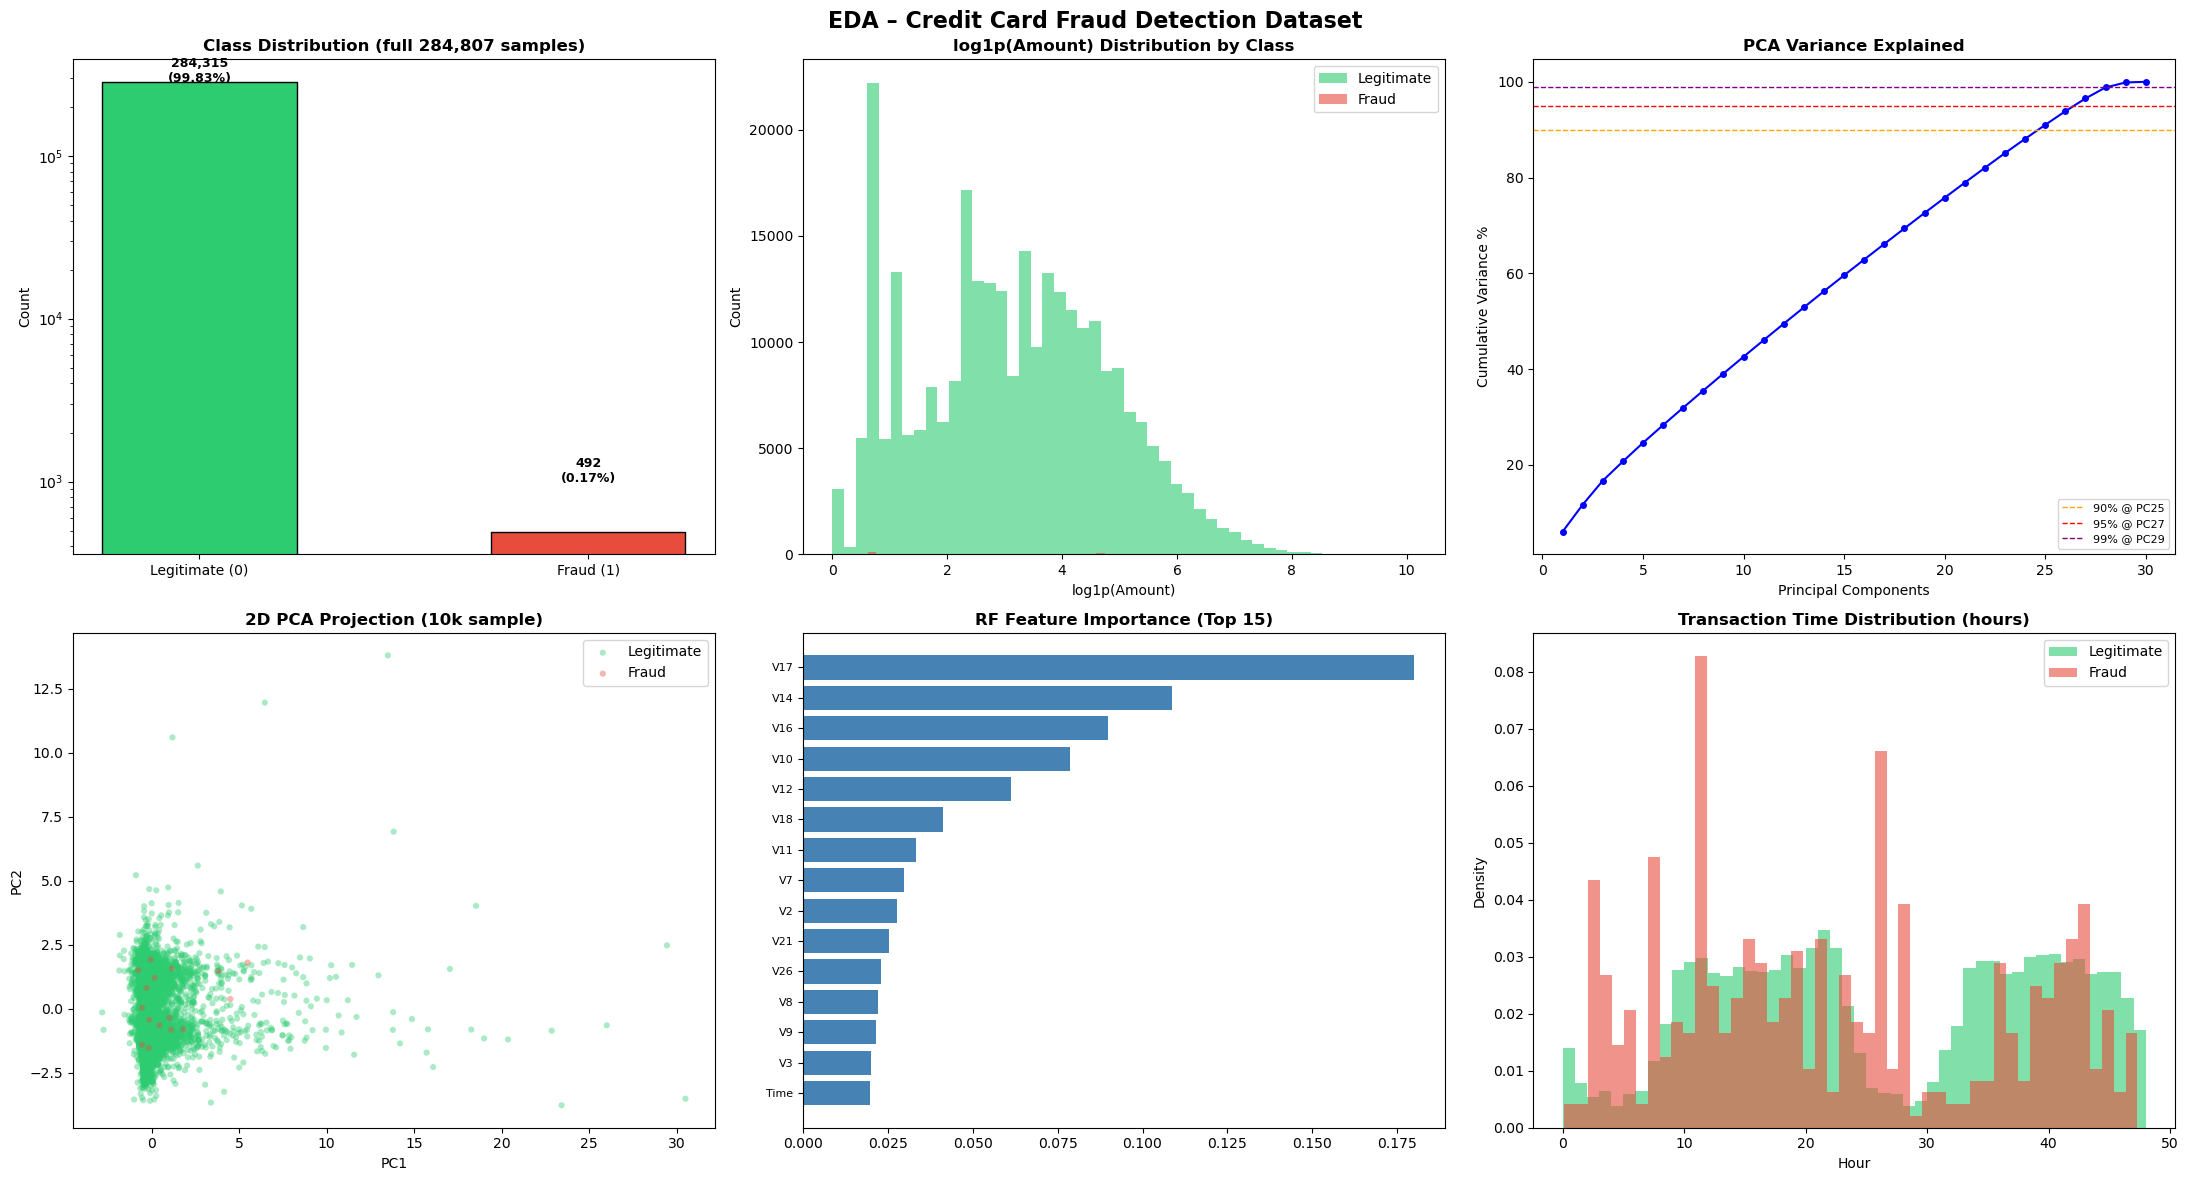

EDA overview saved.


In [4]:
# ── EDA Overview Plots ───────────────────────────────────
# NOTE: For large dataset we sample 10k for EDA speed
N_EDA = min(10000, len(df_raw))
df_eda = df_raw.sample(N_EDA, random_state=GLOBAL_SEED).reset_index(drop=True)
X_eda  = df_eda[FEATURE_COLS].values
y_eda  = df_eda[TARGET_COL].values

scaler_eda = StandardScaler()
Xs_eda = scaler_eda.fit_transform(X_eda)

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('EDA – Credit Card Fraud Detection Dataset', fontsize=16, fontweight='bold')

# 1) Class distribution (full dataset)
cnts = y_s.value_counts().rename({0: 'Legitimate', 1: 'Fraud'})
bars = axes[0,0].bar(cnts.index, cnts.values, color=['#2ecc71','#e74c3c'], edgecolor='k', width=0.5)
for bar, v in zip(bars, cnts.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+500, f'{v:,}\n({v/len(y_s)*100:.2f}%)',
                   ha='center', fontweight='bold', fontsize=9)
axes[0,0].set_title('Class Distribution (full 284,807 samples)', fontweight='bold')
axes[0,0].set_ylabel('Count')
axes[0,0].set_yscale('log')
axes[0,0].set_xticks([0,1])
axes[0,0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])

# 2) Amount distribution by class
for lbl, col, name in zip([0,1], ['#2ecc71','#e74c3c'], ['Legitimate','Fraud']):
    vals = df_raw[df_raw[TARGET_COL]==lbl]['Amount']
    axes[0,1].hist(np.log1p(vals), bins=50, alpha=0.6, color=col, label=name, edgecolor='none')
axes[0,1].set_title('log1p(Amount) Distribution by Class', fontweight='bold')
axes[0,1].set_xlabel('log1p(Amount)'); axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# 3) PCA variance explained (on EDA sample)
pca_full = PCA(random_state=GLOBAL_SEED).fit(Xs_eda)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[0,2].plot(range(1, len(cumvar)+1), cumvar*100, 'b-o', ms=4)
for thresh, col in [(0.90,'orange'), (0.95,'red'), (0.99,'purple')]:
    n = np.searchsorted(cumvar, thresh) + 1
    axes[0,2].axhline(thresh*100, color=col, ls='--', lw=1, label=f'{thresh*100:.0f}% @ PC{n}')
axes[0,2].set_xlabel('Principal Components'); axes[0,2].set_ylabel('Cumulative Variance %')
axes[0,2].set_title('PCA Variance Explained', fontweight='bold')
axes[0,2].legend(fontsize=8)

# 4) 2D PCA scatter (EDA sample)
pca2 = PCA(2, random_state=GLOBAL_SEED).fit_transform(Xs_eda)
for lbl, col, name in zip([0,1], ['#2ecc71','#e74c3c'], ['Legitimate','Fraud']):
    m = y_eda == lbl
    axes[1,0].scatter(pca2[m,0], pca2[m,1], c=col, label=name, alpha=0.4, s=20, edgecolors='none')
axes[1,0].set_title('2D PCA Projection (10k sample)', fontweight='bold')
axes[1,0].legend(); axes[1,0].set_xlabel('PC1'); axes[1,0].set_ylabel('PC2')

# 5) RF Feature importance (top 15)
rf_eda = RandomForestClassifier(100, random_state=GLOBAL_SEED, n_jobs=-1).fit(Xs_eda, y_eda)
imp = rf_eda.feature_importances_
idx = np.argsort(imp)[::-1][:15]
axes[1,1].barh(range(15), imp[idx][::-1], color='steelblue')
axes[1,1].set_yticks(range(15))
axes[1,1].set_yticklabels([FEATURE_COLS[i] for i in idx[::-1]], fontsize=8)
axes[1,1].set_title('RF Feature Importance (Top 15)', fontweight='bold')

# 6) Time distribution by class
for lbl, col, name in zip([0,1], ['#2ecc71','#e74c3c'], ['Legitimate','Fraud']):
    vals = df_raw[df_raw[TARGET_COL]==lbl]['Time'] / 3600
    axes[1,2].hist(vals, bins=48, alpha=0.6, color=col, label=name, edgecolor='none', density=True)
axes[1,2].set_title('Transaction Time Distribution (hours)', fontweight='bold')
axes[1,2].set_xlabel('Hour'); axes[1,2].set_ylabel('Density')
axes[1,2].legend()

plt.tight_layout()
plt.savefig(RES_DIR + 'eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("EDA overview saved.")


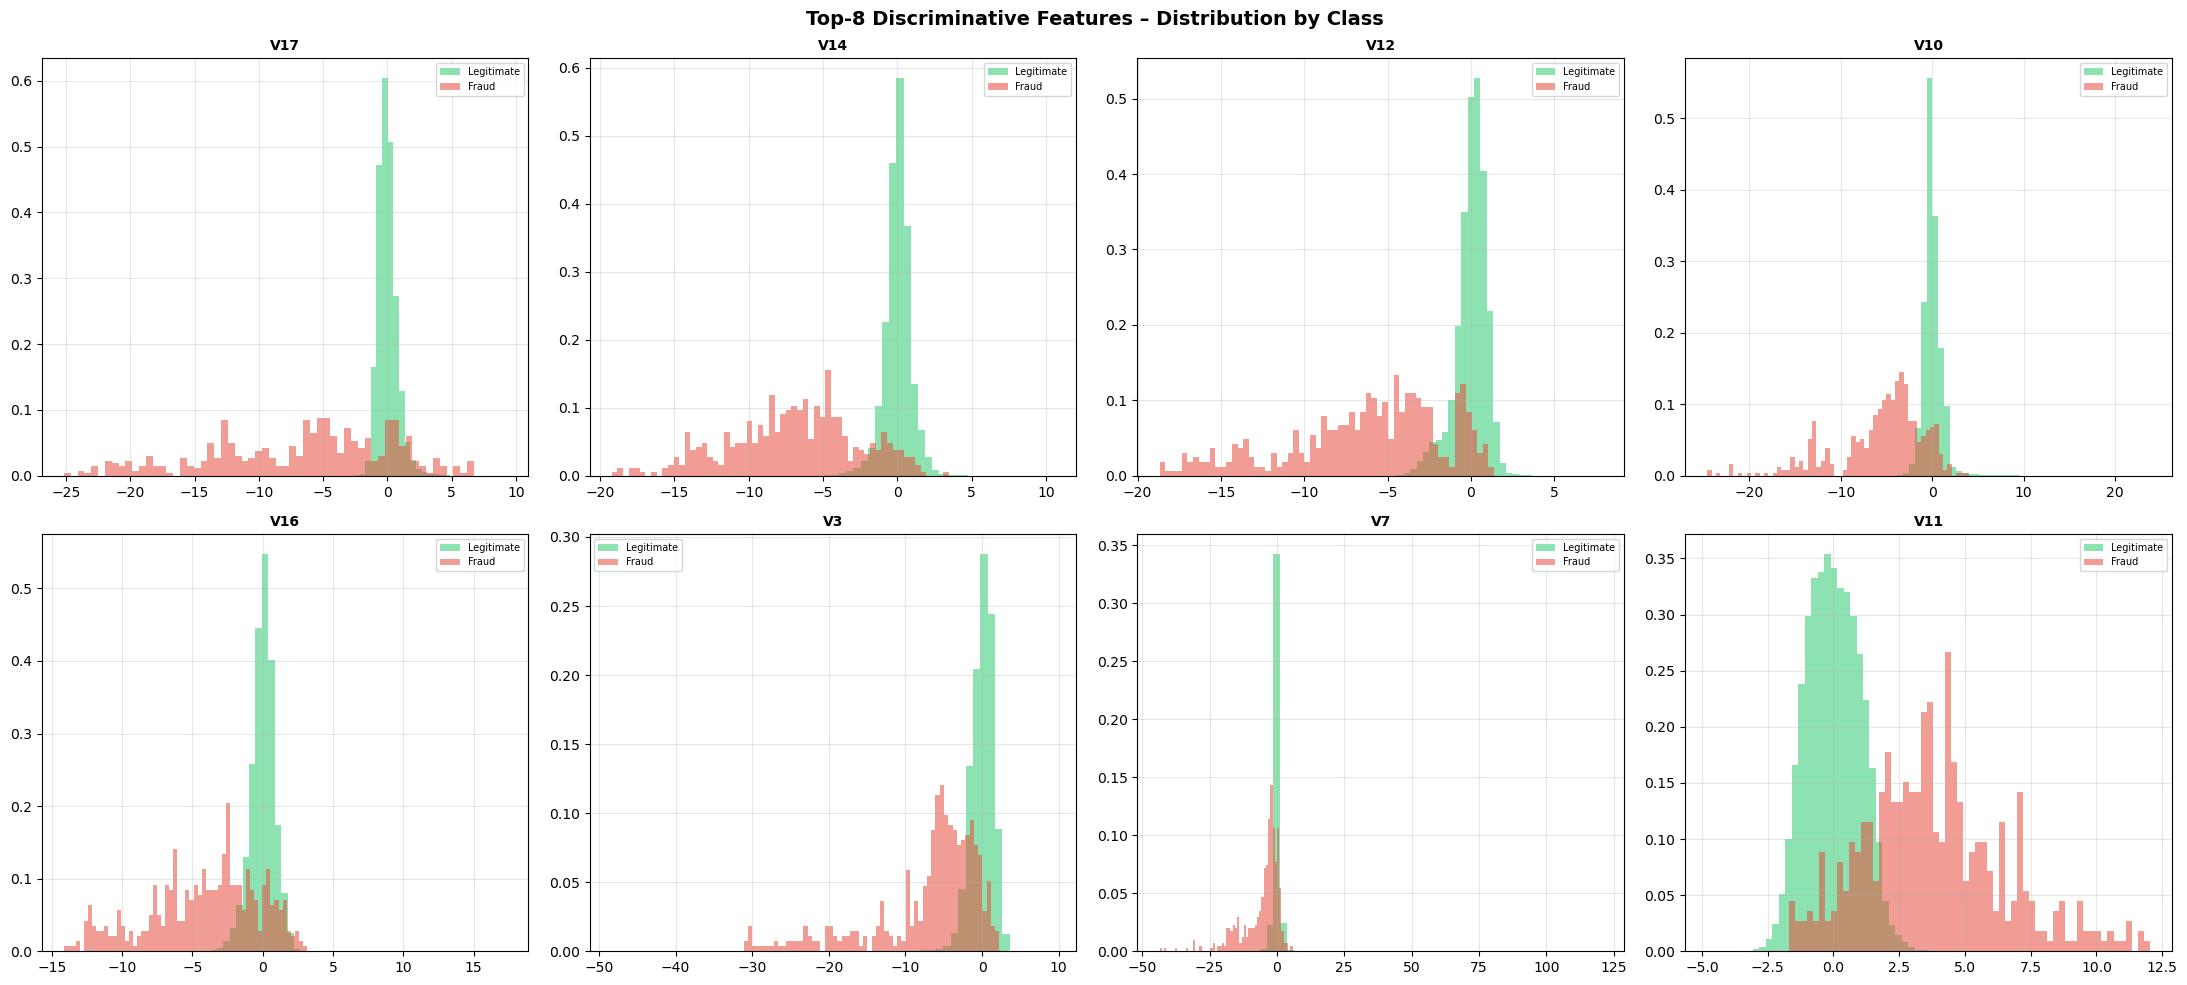


Top-10 V-features by ANOVA F-score (most discriminative):
feature      f_score
    V17 33979.168593
    V14 28695.547788
    V12 20749.822361
    V10 14057.979985
    V16 11443.349428
     V3 11014.508305
     V7 10349.605408
    V11  6999.355047
     V4  5163.832114
    V18  3584.380605


In [5]:
# ── Additional EDA: V-feature distributions by class ──────
# Show top-8 most discriminative V features
scaler_eda2 = StandardScaler()
Xs_full_eda = scaler_eda2.fit_transform(X_df.values)
f_scores_all, _ = f_classif(Xs_full_eda, y_s.values)
top8_idx = np.argsort(f_scores_all)[::-1][:8]
top8_feats = [FEATURE_COLS[i] for i in top8_idx]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Top-8 Discriminative Features – Distribution by Class', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(top8_feats):
    ax = axes[i]
    for lbl, col, name in zip([0,1], ['#2ecc71','#e74c3c'], ['Legitimate','Fraud']):
        vals = df_raw[df_raw[TARGET_COL]==lbl][feat]
        ax.hist(vals, bins=60, alpha=0.55, color=col, label=name, edgecolor='none', density=True)
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR + 'feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

# Correlation of V features with Class
print("\nTop-10 V-features by ANOVA F-score (most discriminative):")
fscore_df = pd.DataFrame({'feature': FEATURE_COLS, 'f_score': f_scores_all})
print(fscore_df.sort_values('f_score', ascending=False).head(10).to_string(index=False))


## 3) Adaptive Feature Selection

In [6]:
def select_relevant_features(X: pd.DataFrame, y: pd.Series,
                              threshold_cumvar: float = 0.95,
                              min_features: int = 4) -> Tuple[List[str], np.ndarray]:
    """
    Multi-method feature selection:
    1. ANOVA filter: keep features with F-score above median
    2. RF importance filter: keep features with importance > mean
    3. Mutual information filter: keep features above median
    4. Union of 2+ method agreement
    Returns: (selected_feature_names, feature_indices)
    """
    # Use a stratified sample for speed (dataset is large)
    rng = np.random.default_rng(GLOBAL_SEED)
    idx0 = np.where(y.values==0)[0]
    idx1 = np.where(y.values==1)[0]
    n_sample = min(5000, len(idx0))
    samp = np.concatenate([
        rng.choice(idx0, n_sample, replace=False),
        idx1  # all fraud samples
    ])
    X_s = X.iloc[samp]; y_s_ = y.iloc[samp]

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_s)

    f_scores, _ = f_classif(Xs, y_s_)
    anova_mask = f_scores >= np.median(f_scores)

    rf = RandomForestClassifier(200, random_state=GLOBAL_SEED, n_jobs=-1).fit(Xs, y_s_)
    rf_mask = rf.feature_importances_ >= rf.feature_importances_.mean()

    mi_scores = mutual_info_classif(Xs, y_s_, random_state=GLOBAL_SEED)
    mi_mask = mi_scores >= np.median(mi_scores)

    vote = anova_mask.astype(int) + rf_mask.astype(int) + mi_mask.astype(int)
    selected_mask = vote >= 2

    if selected_mask.sum() < min_features:
        top_idx = np.argsort(f_scores)[::-1][:min_features]
        selected_mask = np.zeros(len(f_scores), dtype=bool)
        selected_mask[top_idx] = True

    selected_names = X.columns[selected_mask].tolist()
    selected_idx   = np.where(selected_mask)[0]

    pca_check = PCA(random_state=GLOBAL_SEED).fit(Xs[:, selected_idx])
    covered = np.sum(pca_check.explained_variance_ratio_)

    print(f"Feature selection: {selected_mask.sum()}/{len(f_scores)} features selected")
    print(f"  Variance covered by selected features: {covered:.3f}")
    print(f"  Selected: {selected_names}")
    return selected_names, selected_idx


relevant_features, relevant_idx = select_relevant_features(X_df, y_s)
X_relevant = X_df[relevant_features].values
print(f"\nUsing {len(relevant_features)} relevant features for quantum models")
print(f"Full feature set ({len(FEATURE_COLS)}) used for classical models")


Feature selection: 13/30 features selected
  Variance covered by selected features: 1.000
  Selected: ['V2', 'V3', 'V4', 'V6', 'V7', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18']

Using 13 relevant features for quantum models
Full feature set (30) used for classical models


## 4) Preprocessing & Resampling Utilities

In [7]:
def apply_resampling(X, y, strategy='smote', seed=GLOBAL_SEED):
    """SMOTE / SMOTETomek / fallback minority oversampling."""
    if strategy == 'none':
        return X, y
    if HAS_IMBLEARN:
        sampler = SMOTE(random_state=seed) if strategy=='smote' else SMOTETomek(random_state=seed)
        return sampler.fit_resample(X, y)
    # Fallback minority oversampling
    rng = np.random.default_rng(seed)
    minority = np.where(y==1)[0]
    majority = np.where(y==0)[0]
    dup = rng.choice(minority, size=len(majority)-len(minority), replace=True)
    Xr = np.vstack([X, X[dup]])
    yr = np.concatenate([y, y[dup]])
    perm = rng.permutation(len(yr))
    return Xr[perm], yr[perm]


def preprocess_dataset(X, y, n_features, seed=GLOBAL_SEED, test_size=0.2,
                        resample='smote', use_pca=True, subsample_train=8000):
    """
    Subsample majority class for speed → Split → resample → scale → optional PCA.
    Returns: Xtr, Xte, ytr, yte
    Note: subsample_train limits training set for quantum model feasibility.
    """
    # Stratified subsample for training speed (fraud dataset is huge)
    rng = np.random.default_rng(seed)
    idx0 = np.where(y==0)[0]
    idx1 = np.where(y==1)[0]
    n0 = min(subsample_train, len(idx0))
    samp = np.concatenate([rng.choice(idx0, n0, replace=False), idx1])
    Xs_ = X[samp]; ys_ = y[samp]

    Xtr, Xte, ytr, yte = train_test_split(Xs_, ys_, test_size=test_size,
                                            stratify=ys_, random_state=seed)
    if resample != 'none':
        Xtr, ytr = apply_resampling(Xtr, ytr, strategy=resample, seed=seed)

    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)

    if use_pca and n_features < Xtr.shape[1]:
        pca = PCA(n_components=n_features, random_state=seed)
        Xtr = pca.fit_transform(Xtr)
        Xte = pca.transform(Xte)

    return Xtr, Xte, ytr, yte


print("Preprocessing functions ready.")
print(f"  Dataset has {len(y_s):,} samples | Fraud: {(y_s==1).sum()} | Legit: {(y_s==0).sum()}")


Preprocessing functions ready.
  Dataset has 284,807 samples | Fraud: 492 | Legit: 284315


## 5) Quantum Feature Encoders & NumPy Quantum Simulators

In [8]:
class ZZFeatureEncoder:
    """ZZFeatureMap-style encoding: rotations + pairwise ZZ interactions."""
    def __init__(self, n_qubits):
        self.n_qubits = n_qubits

    def encode(self, x):
        x = x[:self.n_qubits]
        feats = list(x)
        for i in range(self.n_qubits - 1):
            feats.append((np.pi - x[i]) * (np.pi - x[i+1]))
        return np.array(feats)

    def encode_batch(self, X):
        return np.array([self.encode(xi) for xi in X])

    @property
    def dim(self):
        return self.n_qubits + (self.n_qubits - 1)


class PauliEncoder:
    """Pauli-style: includes cross terms up to 3-body."""
    def __init__(self, n_qubits):
        self.n_qubits = n_qubits

    def encode(self, x):
        x = x[:self.n_qubits]
        feats = list(x)
        for i in range(self.n_qubits-1):
            feats.append(x[i]*x[i+1])
        for i in range(self.n_qubits-2):
            feats.append(x[i]*x[i+1]*x[i+2])
        return np.array(feats)

    def encode_batch(self, X):
        return np.array([self.encode(xi) for xi in X])

    @property
    def dim(self):
        return self.n_qubits + (self.n_qubits-1) + max(0, self.n_qubits-2)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


class NumpyVQC(BaseEstimator, ClassifierMixin):
    """Variational Quantum Classifier (numpy simulation)."""
    def __init__(self, n_qubits=4, reps=2, shots=512, seed=GLOBAL_SEED,
                 maxiter=100, encoder='zz'):
        self.n_qubits=n_qubits; self.reps=reps; self.shots=shots
        self.seed=seed; self.maxiter=maxiter; self.encoder=encoder

    def _get_encoder(self):
        return ZZFeatureEncoder(self.n_qubits) if self.encoder=='zz' else PauliEncoder(self.n_qubits)

    def _shot_noise(self, p):
        return np.clip(p + np.random.randn(*p.shape)/np.sqrt(self.shots), 0, 1)

    def _loss(self, params, Xe, y):
        p = self._shot_noise(sigmoid(Xe @ params[:-1] + params[-1]))
        p = np.clip(p, 1e-7, 1-1e-7)
        return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

    def fit(self, X, y):
        set_seed(self.seed)
        enc = self._get_encoder()
        Xe = enc.encode_batch(X)
        d = enc.dim
        params = np.random.normal(0, 0.3, d+1)
        self.loss_curve_ = []
        lr = 0.15
        for it in range(self.maxiter):
            self.loss_curve_.append(self._loss(params, Xe, y))
            grad = np.zeros_like(params)
            for i in range(len(params)):
                p_p = params.copy(); p_p[i] += np.pi/2
                p_m = params.copy(); p_m[i] -= np.pi/2
                grad[i] = (self._loss(p_p,Xe,y) - self._loss(p_m,Xe,y)) / 2
            params -= lr * grad
            lr *= 0.997
        self.params_ = params; self.enc_ = enc; self.classes_ = np.array([0,1])
        return self

    def predict_proba(self, X):
        Xe = self.enc_.encode_batch(X)
        p = sigmoid(Xe @ self.params_[:-1] + self.params_[-1])
        return np.column_stack([1-p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:,1] >= 0.5).astype(int)


class NumpyQCNN(NumpyVQC):
    """QCNN: conv+pool layers on top of ZZ encoding."""
    def __init__(self, **kw): super().__init__(**kw)

    def _conv_pool(self, Xe):
        conv = np.array([Xe[:,i]*Xe[:,i+1] for i in range(Xe.shape[1]-1)]).T
        if conv.shape[1] < 2:
            return np.hstack([Xe, conv])
        pool = np.array([conv[:,2*i:2*i+2].mean(1) for i in range(conv.shape[1]//2)]).T
        return np.hstack([Xe, conv, pool])

    def fit(self, X, y):
        set_seed(self.seed)
        enc = self._get_encoder()
        Xe_raw = enc.encode_batch(X)
        Xe = self._conv_pool(Xe_raw)
        d = Xe.shape[1]
        params = np.random.normal(0, 0.3, d+1)
        self.loss_curve_ = []; lr = 0.15
        for it in range(self.maxiter):
            p = self._shot_noise(sigmoid(Xe @ params[:-1] + params[-1]))
            p = np.clip(p, 1e-7, 1-1e-7)
            loss = -np.mean(y*np.log(p) + (1-y)*np.log(1-p))
            self.loss_curve_.append(loss)
            grad = np.zeros_like(params); eps = 1e-4
            for i in range(len(params)):
                pp = params.copy(); pp[i]+=eps
                pm = params.copy(); pm[i]-=eps
                def _l(pr): return -np.mean(y*np.log(np.clip(sigmoid(Xe@pr[:-1]+pr[-1]),1e-7,1-1e-7))
                                             + (1-y)*np.log(np.clip(1-sigmoid(Xe@pr[:-1]+pr[-1]),1e-7,1-1e-7)))
                grad[i] = (_l(pp)-_l(pm))/(2*eps)
            params -= lr*grad; lr*=0.997
        self.params_=params; self.enc_=enc; self.classes_=np.array([0,1])
        return self

    def predict_proba(self, X):
        Xe_raw = self.enc_.encode_batch(X)
        Xe = self._conv_pool(Xe_raw)
        p = sigmoid(Xe @ self.params_[:-1] + self.params_[-1])
        return np.column_stack([1-p, p])


class NumpyQAOA(NumpyVQC):
    """QAOA-inspired: alternating cost/mixer layers."""
    def _encode_qaoa(self, Xe):
        cost = np.tanh(Xe)
        mixer = np.roll(cost, 1, axis=1) * cost
        return np.hstack([cost, mixer])

    def fit(self, X, y):
        set_seed(self.seed)
        enc = self._get_encoder()
        Xe = self._encode_qaoa(enc.encode_batch(X))
        d = Xe.shape[1]
        params = np.random.normal(0, 0.3, d+1)
        self.loss_curve_ = []; lr = 0.12
        for it in range(self.maxiter):
            p = self._shot_noise(sigmoid(Xe @ params[:-1] + params[-1]))
            p = np.clip(p, 1e-7, 1-1e-7)
            self.loss_curve_.append(-np.mean(y*np.log(p)+(1-y)*np.log(1-p)))
            grad = np.zeros_like(params)
            for i in range(len(params)):
                pp=params.copy(); pp[i]+=np.pi/2
                pm=params.copy(); pm[i]-=np.pi/2
                def f(p_): return -np.mean(y*np.log(np.clip(self._shot_noise(
                    sigmoid(Xe@p_[:-1]+p_[-1])),1e-7,1-1e-7))
                    +(1-y)*np.log(np.clip(1-self._shot_noise(
                    sigmoid(Xe@p_[:-1]+p_[-1])),1e-7,1-1e-7)))
                grad[i] = (f(pp)-f(pm))/2
            params -= lr*grad; lr*=0.997
        self.params_=params; self.enc_=enc; self.classes_=np.array([0,1])
        return self

    def predict_proba(self, X):
        Xe = self._encode_qaoa(self.enc_.encode_batch(X))
        p = sigmoid(Xe @ self.params_[:-1] + self.params_[-1])
        return np.column_stack([1-p, p])


class NumpyQKernelSVM(BaseEstimator, ClassifierMixin):
    """Quantum Kernel SVM: fidelity kernel via inner-product of encoded states."""
    def __init__(self, n_qubits=4, C=1.0, seed=GLOBAL_SEED):
        self.n_qubits=n_qubits; self.C=C; self.seed=seed

    def _kernel(self, X1, X2):
        enc = ZZFeatureEncoder(self.n_qubits)
        Z1 = enc.encode_batch(X1); Z2 = enc.encode_batch(X2)
        n1 = np.linalg.norm(Z1, axis=1, keepdims=True)+1e-10
        n2 = np.linalg.norm(Z2, axis=1, keepdims=True)+1e-10
        return ((Z1/n1) @ (Z2/n2).T)**2

    def fit(self, X, y):
        self.X_train_=X; self.y_train_=y
        K = self._kernel(X, X)
        self.svm_ = SVC(kernel='precomputed', C=self.C, probability=True, random_state=self.seed)
        self.svm_.fit(K, y)
        self.classes_=np.array([0,1]); self.loss_curve_=[]
        return self

    def predict_proba(self, X): return self.svm_.predict_proba(self._kernel(X, self.X_train_))
    def predict(self, X):       return self.svm_.predict(self._kernel(X, self.X_train_))

print("Numpy quantum simulators ready: NumpyVQC, NumpyQCNN, NumpyQAOA, NumpyQKernelSVM")


Numpy quantum simulators ready: NumpyVQC, NumpyQCNN, NumpyQAOA, NumpyQKernelSVM


## 6) Hybrid Models

In [9]:
class HybridNet(BaseEstimator, ClassifierMixin):
    """
    Quantum Feature Extractor + Classical MLP.
    Architecture: Input → ZZFeatureMap (numpy) → Classical MLP(32,16) → Output
    """
    def __init__(self, n_qubits=4, hidden=(32,16), seed=GLOBAL_SEED, maxiter=300):
        self.n_qubits=n_qubits; self.hidden=hidden; self.seed=seed; self.maxiter=maxiter

    def fit(self, X, y):
        enc = ZZFeatureEncoder(self.n_qubits)
        Xe  = enc.encode_batch(X)
        X_aug = np.hstack([X[:,:self.n_qubits], Xe])
        self.enc_ = enc
        self.mlp_ = MLPClassifier(hidden_layer_sizes=self.hidden, max_iter=self.maxiter,
                                   random_state=self.seed, early_stopping=True)
        self.mlp_.fit(X_aug, y)
        self.loss_curve_ = list(self.mlp_.loss_curve_) if hasattr(self.mlp_,'loss_curve_') else []
        self.classes_ = np.array([0,1])
        return self

    def predict_proba(self, X):
        Xe    = self.enc_.encode_batch(X)
        X_aug = np.hstack([X[:,:self.n_qubits], Xe])
        return self.mlp_.predict_proba(X_aug)

    def predict(self, X): return (self.predict_proba(X)[:,1] >= 0.5).astype(int)


class QuantumBoost(BaseEstimator, ClassifierMixin):
    """
    Quantum Residual Features + Gradient Boosting Classifier.
    Architecture: Input → [ZZ features || Pauli features || raw] → GradientBoostingClassifier
    """
    def __init__(self, n_qubits=4, n_estimators=100, seed=GLOBAL_SEED):
        self.n_qubits=n_qubits; self.n_estimators=n_estimators; self.seed=seed

    def _quantum_features(self, X):
        zz  = ZZFeatureEncoder(self.n_qubits).encode_batch(X)
        pau = PauliEncoder(self.n_qubits).encode_batch(X)
        raw = X[:, :self.n_qubits]
        residual = zz[:, :self.n_qubits] - raw
        return np.hstack([raw, zz, pau, residual])

    def fit(self, X, y):
        Xq = self._quantum_features(X)
        self.gbm_ = GradientBoostingClassifier(n_estimators=self.n_estimators, random_state=self.seed)
        self.gbm_.fit(Xq, y)
        self.loss_curve_ = list(self.gbm_.train_score_)
        self.classes_ = np.array([0,1])
        return self

    def predict_proba(self, X): return self.gbm_.predict_proba(self._quantum_features(X))
    def predict(self, X):       return self.gbm_.predict(self._quantum_features(X))


class QResNet(BaseEstimator, ClassifierMixin):
    """
    Quantum ResNet: skip connections between quantum layers.
    Architecture:
        Layer 1: ZZ(x)  + x  (skip) → z1
        Layer 2: ZZ(z1) + z1 (skip) → z2
        Stack [z1, z2, x] → Logistic Regression
    """
    def __init__(self, n_qubits=4, seed=GLOBAL_SEED):
        self.n_qubits=n_qubits; self.seed=seed

    def _residual_forward(self, X):
        raw = X[:, :self.n_qubits]
        enc = ZZFeatureEncoder(self.n_qubits)
        z1_q = enc.encode_batch(raw)
        z1   = np.hstack([z1_q, raw])
        z1_norm = StandardScaler().fit_transform(z1[:, :self.n_qubits])
        z2_q = enc.encode_batch(z1_norm)
        z2   = np.hstack([z2_q, z1[:, :self.n_qubits]])
        return np.hstack([raw, z1, z2])

    def fit(self, X, y):
        Xr = self._residual_forward(X)
        self.lr_ = LogisticRegression(max_iter=2000, C=0.5, random_state=self.seed)
        self.lr_.fit(Xr, y)
        self.loss_curve_ = []; self.classes_ = np.array([0,1])
        return self

    def predict_proba(self, X): return self.lr_.predict_proba(self._residual_forward(X))
    def predict(self, X):       return self.lr_.predict(self._residual_forward(X))


print("Hybrid models ready: HybridNet, QuantumBoost, QResNet")


Hybrid models ready: HybridNet, QuantumBoost, QResNet


## 7) Model Architecture Diagrams

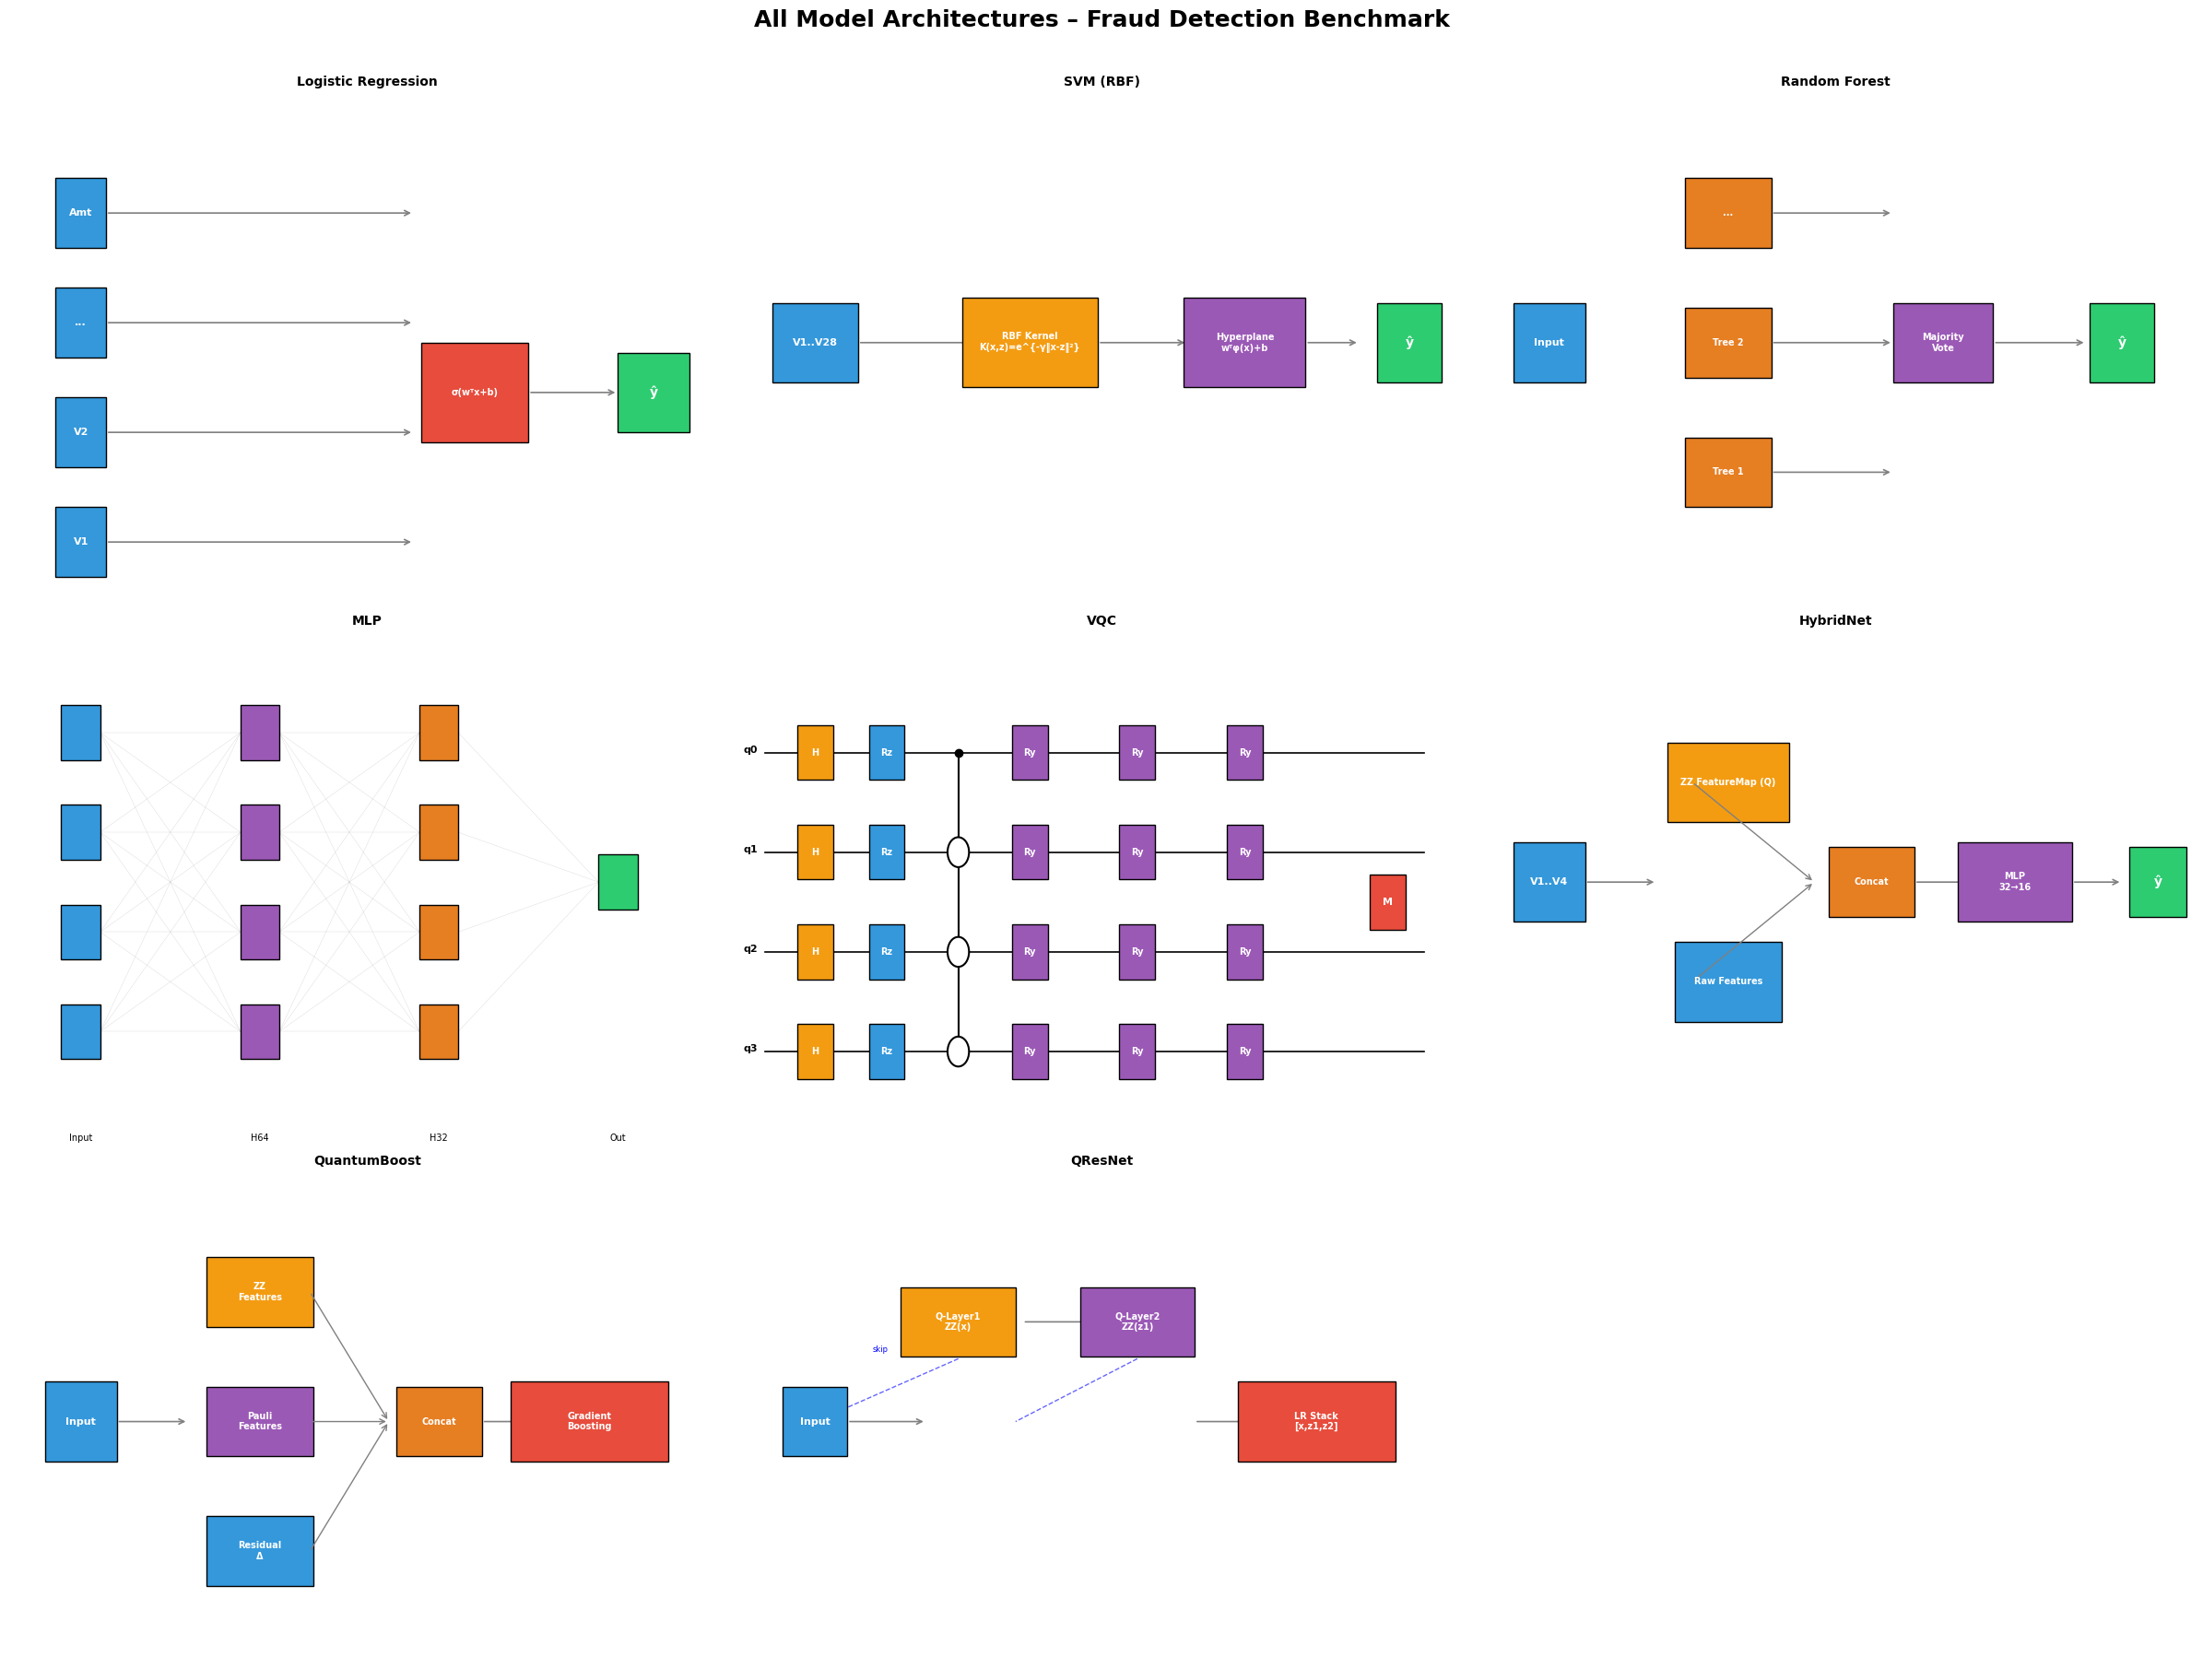

Architecture diagrams saved.


In [10]:
def draw_model_arch(name, ax):
    ax.set_xlim(0, 10); ax.set_ylim(0, 5)
    ax.axis('off')
    ax.set_title(name, fontsize=10, fontweight='bold', pad=6)

    def box(x, y, w, h, col, txt, fs=8):
        w=float(w); h=float(h)
        ax.add_patch(plt.Rectangle((x-w/2, y-h/2), w, h,
                     facecolor=col, edgecolor='k', lw=1, zorder=3))
        ax.text(x, y, txt, ha='center', va='center', fontsize=fs, zorder=4,
                color='white', fontweight='bold')

    def arrow(x1, x2, y):
        ax.annotate('', xy=(x2, y), xytext=(x1, y),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

    if name == 'Logistic Regression':
        for i, t in enumerate(['V1','V2','...','Amt']):
            y_ = 0.5 + i * 1.1
            box(1, y_, 0.7, 0.7, '#3498db', t)
            arrow(1.35, 5.65, y_)
        box(6.5, 2, 1.5, 1.0, '#e74c3c', 'σ(wᵀx+b)', 7)
        arrow(7.25, 8.5, 2); box(9, 2, 1.0, 0.8, '#2ecc71', 'ŷ', 10)
    elif name == 'SVM (RBF)':
        box(1, 2.5, 1.2, 0.8, '#3498db', 'V1..V28', 8); arrow(1.6, 3.4, 2.5)
        box(4, 2.5, 1.9, 0.9, '#f39c12', 'RBF Kernel\nK(x,z)=e^{-γ‖x-z‖²}', 7)
        arrow(4.95, 6.2, 2.5)
        box(7, 2.5, 1.7, 0.9, '#9b59b6', 'Hyperplane\nwᵀφ(x)+b', 7)
        arrow(7.85, 8.6, 2.5); box(9.3, 2.5, 0.9, 0.8, '#2ecc71', 'ŷ', 10)
    elif name == 'Random Forest':
        box(1, 2.5, 1.0, 0.8, '#3498db', 'Input', 8)
        for i, y_ in enumerate([1.2, 2.5, 3.8]):
            box(3.5, y_, 1.2, 0.7, '#e67e22', f'Tree {i+1}' if i<2 else '...', 7)
            arrow(4.1, 5.8, y_)
        box(6.5, 2.5, 1.4, 0.8, '#9b59b6', 'Majority\nVote', 7)
        arrow(7.2, 8.5, 2.5); box(9, 2.5, 0.9, 0.8, '#2ecc71', 'ŷ', 10)
    elif name == 'MLP':
        cols = ['#3498db','#9b59b6','#e67e22','#2ecc71']
        xs = [1, 3.5, 6, 8.5]; ns = [4, 4, 4, 1]
        labels = ['Input','H64','H32','Out']
        prev_ys=None; prev_x=None
        for xi, ni, col, lbl in zip(xs, ns, cols, labels):
            ys = [2.5 - (ni-1)*0.5 + j for j in range(ni)]
            for y_ in ys: box(xi, y_, 0.55, 0.55, col, '', 9)
            ax.text(xi, -0.1, lbl, ha='center', fontsize=7)
            if prev_ys is not None:
                for py in prev_ys:
                    for cy in ys:
                        ax.plot([prev_x+0.27, xi-0.27],[py,cy],'gray',lw=0.3,alpha=0.3,zorder=1)
            prev_ys=ys; prev_x=xi
    elif name == 'VQC':
        for q, y_ in enumerate([3.8, 2.8, 1.8, 0.8]):
            ax.plot([0.3, 9.5],[y_,y_],'k-',lw=1.2)
            ax.text(0.2, y_, f'q{q}', ha='right', fontsize=8, fontweight='bold')
            box(1, y_, 0.5, 0.55, '#f39c12', 'H', 7)
            box(2, y_, 0.5, 0.55, '#3498db', 'Rz', 7)
            for gx in [4, 5.5, 7]: box(gx, y_, 0.5, 0.55, '#9b59b6', 'Ry', 7)
        for q in range(3):
            y1 = 3.8-q; y2 = 2.8-q
            ax.plot([3,3],[y1,y2],'k-',lw=1.5); ax.plot([3],[y1],'ko',ms=6)
            circ=plt.Circle((3,y2),0.15,color='white',ec='k',lw=1.5,zorder=3)
            ax.add_patch(circ)
        box(9, 2.3, 0.5, 0.55, '#e74c3c', 'M', 8)
    elif name == 'HybridNet':
        box(1,2.5,1.0,0.8,'#3498db','V1..V4',8); arrow(1.5,2.5,2.5)
        box(3.5,3.5,1.7,0.8,'#f39c12','ZZ FeatureMap (Q)',7)
        box(3.5,1.5,1.5,0.8,'#3498db','Raw Features',7)
        ax.annotate('',xy=(4.7,2.5),xytext=(3.0,3.5),arrowprops=dict(arrowstyle='->',color='gray'))
        ax.annotate('',xy=(4.7,2.5),xytext=(3.0,1.5),arrowprops=dict(arrowstyle='->',color='gray'))
        box(5.5,2.5,1.2,0.7,'#e67e22','Concat',7); arrow(6.1,7.0,2.5)
        box(7.5,2.5,1.6,0.8,'#9b59b6','MLP\n32→16',7); arrow(8.3,9.0,2.5)
        box(9.5,2.5,0.8,0.7,'#2ecc71','ŷ',10)
    elif name == 'QuantumBoost':
        box(1,2.5,1.0,0.8,'#3498db','Input',8); arrow(1.5,2.5,2.5)
        box(3.5,3.8,1.5,0.7,'#f39c12','ZZ\nFeatures',7)
        box(3.5,2.5,1.5,0.7,'#9b59b6','Pauli\nFeatures',7)
        box(3.5,1.2,1.5,0.7,'#3498db','Residual\nΔ',7)
        for y_ in [3.8,2.5,1.2]:
            ax.annotate('',xy=(5.3,2.5),xytext=(4.2,y_),arrowprops=dict(arrowstyle='->',color='gray'))
        box(6,2.5,1.2,0.7,'#e67e22','Concat',7); arrow(6.6,7.5,2.5)
        box(8.1,2.5,2.2,0.8,'#e74c3c','Gradient\nBoosting',7)
    elif name == 'QResNet':
        box(1,2.5,0.9,0.7,'#3498db','Input',8); arrow(1.45,2.55,2.5)
        box(3,3.5,1.6,0.7,'#f39c12','Q-Layer1\nZZ(x)',7)
        ax.plot([3,1],[3.13,2.5],'b--',lw=1,alpha=0.6)
        ax.text(1.8,3.2,'skip',fontsize=6,color='blue')
        arrow(3.9,5.0,3.5)
        box(5.5,3.5,1.6,0.7,'#9b59b6','Q-Layer2\nZZ(z1)',7)
        ax.plot([5.5,3.8],[3.13,2.5],'b--',lw=1,alpha=0.6)
        arrow(6.3,7.5,2.5)
        box(8,2.5,2.2,0.8,'#e74c3c','LR Stack\n[x,z1,z2]',7)
    else:
        ax.text(5,2.5,name,ha='center',va='center',fontsize=11,fontweight='bold')


model_names = ['Logistic Regression','SVM (RBF)','Random Forest','MLP',
               'VQC','HybridNet','QuantumBoost','QResNet']
fig, axes = plt.subplots(3, 3, figsize=(24, 18))
fig.suptitle('All Model Architectures – Fraud Detection Benchmark', fontsize=18, fontweight='bold', y=1.01)
axes = axes.flatten()
for ax, name in zip(axes, model_names): draw_model_arch(name, ax)
for ax in axes[len(model_names):]: ax.axis('off')
plt.tight_layout()
plt.savefig(RES_DIR + 'all_architectures.png', dpi=120, bbox_inches='tight')
plt.show()
print("Architecture diagrams saved.")


## 8) Noise Configuration

In [11]:
@dataclass
class NoiseConfig:
    name: str
    noise_type: str
    noise_param: float = 0.0

NOISE_CONFIGS = [
    NoiseConfig('Ideal',                    'none',              0.00),
    NoiseConfig('Depolarizing p=0.01',      'depolarizing',      0.01),
    NoiseConfig('Depolarizing p=0.03',      'depolarizing',      0.03),
    NoiseConfig('Depolarizing p=0.05',      'depolarizing',      0.05),
    NoiseConfig('Bitflip p=0.01',           'bitflip',           0.01),
    NoiseConfig('Bitflip p=0.05',           'bitflip',           0.05),
    NoiseConfig('Amplitude Damp p=0.02',    'amplitude_damping', 0.02),
    NoiseConfig('Amplitude Damp p=0.05',    'amplitude_damping', 0.05),
    NoiseConfig('Gaussian σ=0.01',          'gaussian',          0.01),
    NoiseConfig('Gaussian σ=0.05',          'gaussian',          0.05),
]

def inject_noise(X, cfg: NoiseConfig, seed=GLOBAL_SEED):
    rng = np.random.default_rng(seed)
    Xn = X.copy(); p = cfg.noise_param
    if cfg.noise_type == 'none':            return Xn
    elif cfg.noise_type == 'gaussian':      Xn += rng.normal(0, p, Xn.shape)
    elif cfg.noise_type == 'depolarizing':
        mask = rng.random(Xn.shape) < p
        Xn[mask] = rng.normal(0, 1, mask.sum())
    elif cfg.noise_type == 'bitflip':       Xn[rng.random(Xn.shape) < p] *= -1
    elif cfg.noise_type == 'amplitude_damping': Xn[rng.random(Xn.shape) < p] *= (1 - p)
    return Xn

print("Noise models:", [c.name for c in NOISE_CONFIGS])


Noise models: ['Ideal', 'Depolarizing p=0.01', 'Depolarizing p=0.03', 'Depolarizing p=0.05', 'Bitflip p=0.01', 'Bitflip p=0.05', 'Amplitude Damp p=0.02', 'Amplitude Damp p=0.05', 'Gaussian σ=0.01', 'Gaussian σ=0.05']


## 9) Evaluation & Model Registry

In [12]:
def evaluate_model(model, Xtr, ytr, Xte, yte, cv_folds=5):
    """Full evaluation: accuracy, AUC, F1, MCC, sensitivity, specificity,
    train time, CV scores. Also computes Average Precision (fraud-relevant)."""
    t0 = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - t0

    pred = model.predict(Xte)
    acc  = accuracy_score(yte, pred)
    f1   = f1_score(yte, pred, zero_division=0)
    cm   = confusion_matrix(yte, pred)

    tn, fp, fn, tp = cm.ravel() if cm.shape==(2,2) else (0,0,0,0)
    sensitivity = tp / (tp + fn + 1e-10)  # fraud recall
    specificity = tn / (tn + fp + 1e-10)  # legit recall
    precision   = tp / (tp + fp + 1e-10)
    mcc_denom   = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) + 1e-10
    mcc         = (tp*tn - fp*fn) / mcc_denom

    try:
        proba = model.predict_proba(Xte)[:,1]
        auc   = roc_auc_score(yte, proba)
        ap    = average_precision_score(yte, proba)   # key for imbalanced fraud
    except:
        auc = ap = float('nan')

    # 5-fold CV on combined data
    try:
        m2   = copy.deepcopy(model)
        Xall = np.vstack([Xtr, Xte])
        yall = np.concatenate([ytr, yte])
        cv_sc = cross_val_score(m2, Xall, yall,
                                cv=StratifiedKFold(cv_folds, shuffle=True, random_state=GLOBAL_SEED),
                                scoring='roc_auc')  # AUC-ROC CV for fraud
    except:
        cv_sc = np.array([float('nan')]*cv_folds)

    return dict(acc=acc, auc=auc, f1=f1, mcc=mcc, ap=ap,
                sensitivity=sensitivity, specificity=specificity, precision=precision,
                train_time=train_time,
                cv_mean=cv_sc.mean(), cv_std=cv_sc.std(),
                cm=cm, loss_curve=getattr(model,'loss_curve_',[]))


def get_all_models(n_qubits=4, seed=GLOBAL_SEED, maxiter=80):
    """Return dict of all 11 models: classical + quantum + hybrid."""
    return {
        # Classical
        'LR':           LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced', random_state=seed),
        'SVM_RBF':      SVC(C=1.0, gamma='scale', probability=True, class_weight='balanced', random_state=seed),
        'RF':           RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=seed),
        'MLP':          MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300,
                                       early_stopping=True, random_state=seed),
        # Quantum
        'VQC':          NumpyVQC(n_qubits=n_qubits, reps=2, shots=512, seed=seed, maxiter=maxiter),
        'QCNN':         NumpyQCNN(n_qubits=n_qubits, reps=2, shots=512, seed=seed, maxiter=maxiter),
        'QKernel_SVM':  NumpyQKernelSVM(n_qubits=n_qubits, seed=seed),
        'QAOA_VQC':     NumpyQAOA(n_qubits=n_qubits, shots=512, seed=seed, maxiter=maxiter),
        # Hybrid
        'HybridNet':    HybridNet(n_qubits=n_qubits, seed=seed),
        'QuantumBoost': QuantumBoost(n_qubits=n_qubits, seed=seed),
        'QResNet':      QResNet(n_qubits=n_qubits, seed=seed),
    }

print("Evaluation utilities and model registry ready.")


Evaluation utilities and model registry ready.


## 10) Input Size Experiment

In [13]:
def run_input_size_experiment(seeds=range(3), maxiter=60):
    """
    Test all models across:
      - 4 PCA features
      - 6 PCA features
      - N relevant features (adaptively selected)
      - Full features (classical only)
    """
    X_np = X_df.values; y_np = y_s.values

    rel_names, rel_idx = select_relevant_features(X_df, y_s)
    n_rel = len(rel_idx)
    X_rel = X_np[:, rel_idx]
    n_full = X_np.shape[1]

    configs = [
        ('4-PCA',             4,      X_np,  True),
        ('6-PCA',             6,      X_np,  True),
        (f'{n_rel}-Relevant', n_rel,  X_rel, False),
        (f'{n_full}-Full',    n_full, X_np,  False),
    ]

    rows = []
    quantum_models = ['VQC','QCNN','QKernel_SVM','QAOA_VQC','HybridNet','QuantumBoost','QResNet']

    for cfg_name, n_feat, X_use, use_pca in configs:
        print(f"\n── Config: {cfg_name} (n_features={n_feat}) ──")
        for seed in seeds:
            set_seed(seed)
            Xtr, Xte, ytr, yte = preprocess_dataset(
                X_use, y_np, n_features=n_feat, seed=seed, resample='smote', use_pca=use_pca)
            models = get_all_models(n_qubits=min(n_feat, 8), seed=seed, maxiter=maxiter)
            if not use_pca and n_feat > 8:
                models = {k:v for k,v in models.items() if k not in quantum_models}
            for mname, model in models.items():
                try:
                    res = evaluate_model(model, Xtr, ytr, Xte, yte, cv_folds=5)
                    rows.append(dict(config=cfg_name, n_features=n_feat,
                                     model=mname, seed=seed,
                                     **{k:v for k,v in res.items() if k not in ('cm','loss_curve')}))
                    print(f"  {mname:15s} acc={res['acc']:.3f} auc={res['auc']:.3f} f1={res['f1']:.3f}")
                except Exception as e:
                    print(f"  [SKIP] {mname}: {e}")

    return pd.DataFrame(rows)


print("Starting input-size experiment...")
df_input = run_input_size_experiment(seeds=range(3), maxiter=60)
print(f"\nDone. {len(df_input)} result rows.")


Starting input-size experiment...
Feature selection: 13/30 features selected
  Variance covered by selected features: 1.000
  Selected: ['V2', 'V3', 'V4', 'V6', 'V7', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18']

── Config: 4-PCA (n_features=4) ──
  LR              acc=0.978 auc=0.931 f1=0.814
  SVM_RBF         acc=0.982 auc=0.939 f1=0.842
  RF              acc=0.977 auc=0.936 f1=0.810
  MLP             acc=0.979 auc=0.947 f1=0.828
  VQC             acc=0.969 auc=0.911 f1=0.755
  QCNN            acc=0.944 auc=0.572 f1=0.095
  QKernel_SVM     acc=0.980 auc=0.932 f1=0.825
  QAOA_VQC        acc=0.984 auc=0.908 f1=0.849
  HybridNet       acc=0.974 auc=0.943 f1=0.790
  QuantumBoost    acc=0.978 auc=0.943 f1=0.818
  QResNet         acc=0.863 auc=0.913 f1=0.410
  LR              acc=0.974 auc=0.933 f1=0.787
  SVM_RBF         acc=0.978 auc=0.947 f1=0.820
  RF              acc=0.973 auc=0.949 f1=0.787
  MLP             acc=0.977 auc=0.935 f1=0.813
  VQC             acc=0.977 auc=0.928

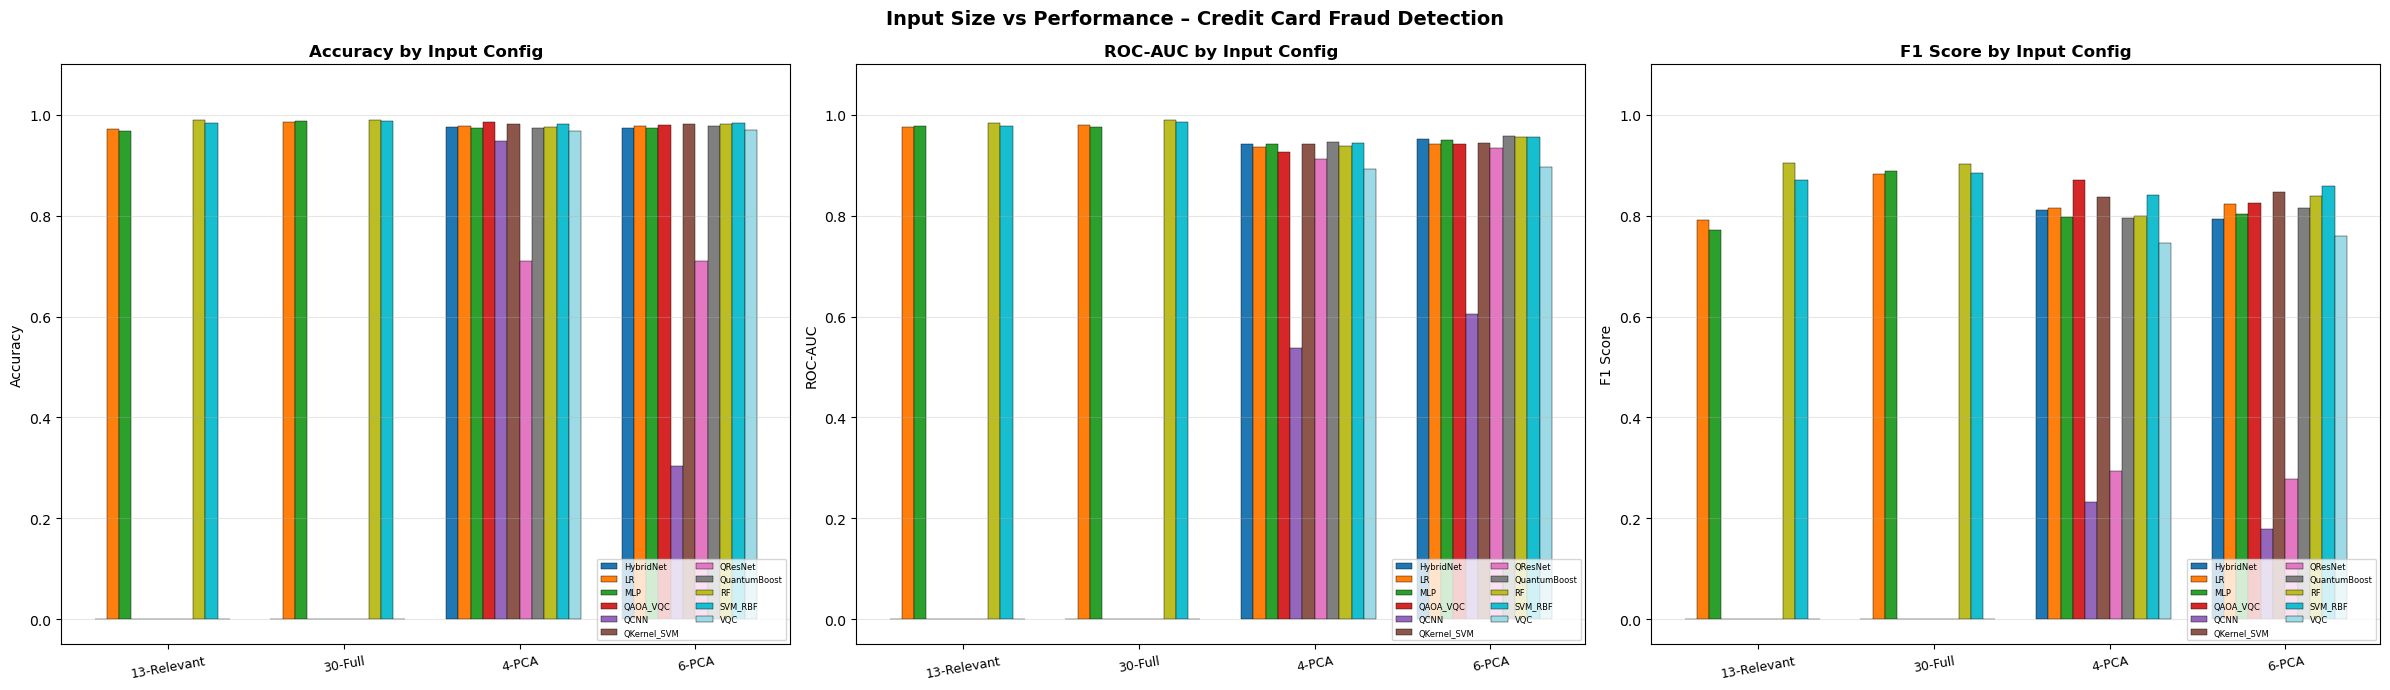

Input size comparison saved.


In [14]:
# ── Input size plots ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Input Size vs Performance – Credit Card Fraud Detection', fontsize=14, fontweight='bold')

for ax, metric, ylabel in zip(axes, ['acc','auc','f1'], ['Accuracy','ROC-AUC','F1 Score']):
    pivot = df_input.groupby(['config','model'])[metric].mean().unstack('model')
    x = np.arange(len(pivot)); w = 0.07
    models = pivot.columns.tolist()
    colors = plt.cm.tab20(np.linspace(0,1,len(models)))
    for i,(m,col) in enumerate(zip(models, colors)):
        if m in pivot.columns:
            ax.bar(x + i*w, pivot[m].fillna(0), w, label=m, color=col, edgecolor='k', lw=0.3)
    ax.set_xticks(x + w*len(models)/2)
    ax.set_xticklabels(pivot.index, fontsize=9, rotation=10)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} by Input Config', fontweight='bold')
    ax.legend(fontsize=6, ncol=2, loc='lower right')
    ax.set_ylim(-0.05, 1.1); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR + 'input_size_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Input size comparison saved.")


## 11) Main Benchmark (All Models × All Noise × 5 Seeds)

In [15]:
def run_main_benchmark(n_qubits=4, seeds=range(5), maxiter=80):
    """
    Full grid:
      - All 11 models
      - All 10 noise configs (quantum only for noise)
      - 5 seeds
      - 5-fold CV (AUC scoring for imbalanced fraud data)
    """
    X_np = X_df.values; y_np = y_s.values
    rows = []
    quantum_names = ['VQC','QCNN','QKernel_SVM','QAOA_VQC','HybridNet','QuantumBoost','QResNet']

    for seed in seeds:
        set_seed(seed)
        # Classical: full features, larger subsample
        Xtr_f, Xte_f, ytr, yte = preprocess_dataset(
            X_np, y_np, n_features=X_np.shape[1], seed=seed, resample='smote',
            use_pca=False, subsample_train=8000)
        # Quantum/hybrid: PCA to n_qubits, smaller subsample
        Xtr_q, Xte_q, _, _ = preprocess_dataset(
            X_np, y_np, n_features=n_qubits, seed=seed, resample='smote',
            use_pca=True, subsample_train=2000)

        models = get_all_models(n_qubits=n_qubits, seed=seed, maxiter=maxiter)

        for mname, model in models.items():
            Xtr = Xtr_q if mname in quantum_names else Xtr_f
            Xte = Xte_q if mname in quantum_names else Xte_f

            # No noise run
            try:
                res = evaluate_model(model, Xtr, ytr, Xte, yte)
                rows.append(dict(model=mname, seed=seed, noise='none', noise_param=0.0,
                                  **{k:v for k,v in res.items() if k not in ('cm','loss_curve')},
                                  loss_curve=res['loss_curve']))
                print(f"  seed={seed} {mname:15s} acc={res['acc']:.3f} auc={res['auc']:.3f} f1={res['f1']:.3f}")
            except Exception as e:
                print(f"[SKIP] {mname} seed={seed}: {e}")

            # Noise runs (quantum + hybrid only)
            if mname in quantum_names:
                for nc in NOISE_CONFIGS[1:]:
                    try:
                        m2    = copy.deepcopy(model)
                        Xtr_n = inject_noise(Xtr, nc, seed=seed)
                        Xte_n = inject_noise(Xte, nc, seed=seed+100)
                        res_n = evaluate_model(m2, Xtr_n, ytr, Xte_n, yte, cv_folds=3)
                        rows.append(dict(model=mname, seed=seed,
                                          noise=nc.noise_type, noise_param=nc.noise_param,
                                          **{k:v for k,v in res_n.items() if k not in ('cm','loss_curve')},
                                          loss_curve=res_n['loss_curve']))
                    except Exception as e:
                        print(f"  [SKIP noise] {mname} {nc.name}: {e}")

        print(f"Seed {seed} done.")

    return pd.DataFrame(rows)


print("Starting main benchmark (this will take a few minutes)...")
df_main = run_main_benchmark(n_qubits=4, seeds=range(5), maxiter=80)
print(f"\nTotal rows: {len(df_main)}")
print("\nNo-noise summary:")
print(df_main[df_main['noise']=='none'].groupby('model')[['acc','auc','f1','mcc','cv_mean']].mean().round(3))


Starting main benchmark (this will take a few minutes)...
  seed=0 LR              acc=0.984 auc=0.985 f1=0.867
  seed=0 SVM_RBF         acc=0.985 auc=0.991 f1=0.866
  seed=0 RF              acc=0.989 auc=0.990 f1=0.902
  seed=0 MLP             acc=0.986 auc=0.974 f1=0.886
[SKIP] VQC seed=0: operands could not be broadcast together with shapes (12798,) (3200,) 
  [SKIP noise] VQC Depolarizing p=0.01: operands could not be broadcast together with shapes (12798,) (3200,) 
  [SKIP noise] VQC Depolarizing p=0.03: operands could not be broadcast together with shapes (12798,) (3200,) 
  [SKIP noise] VQC Depolarizing p=0.05: operands could not be broadcast together with shapes (12798,) (3200,) 
  [SKIP noise] VQC Bitflip p=0.01: operands could not be broadcast together with shapes (12798,) (3200,) 
  [SKIP noise] VQC Bitflip p=0.05: operands could not be broadcast together with shapes (12798,) (3200,) 
  [SKIP noise] VQC Amplitude Damp p=0.02: operands could not be broadcast together with sha

## 12) Comprehensive Visualizations

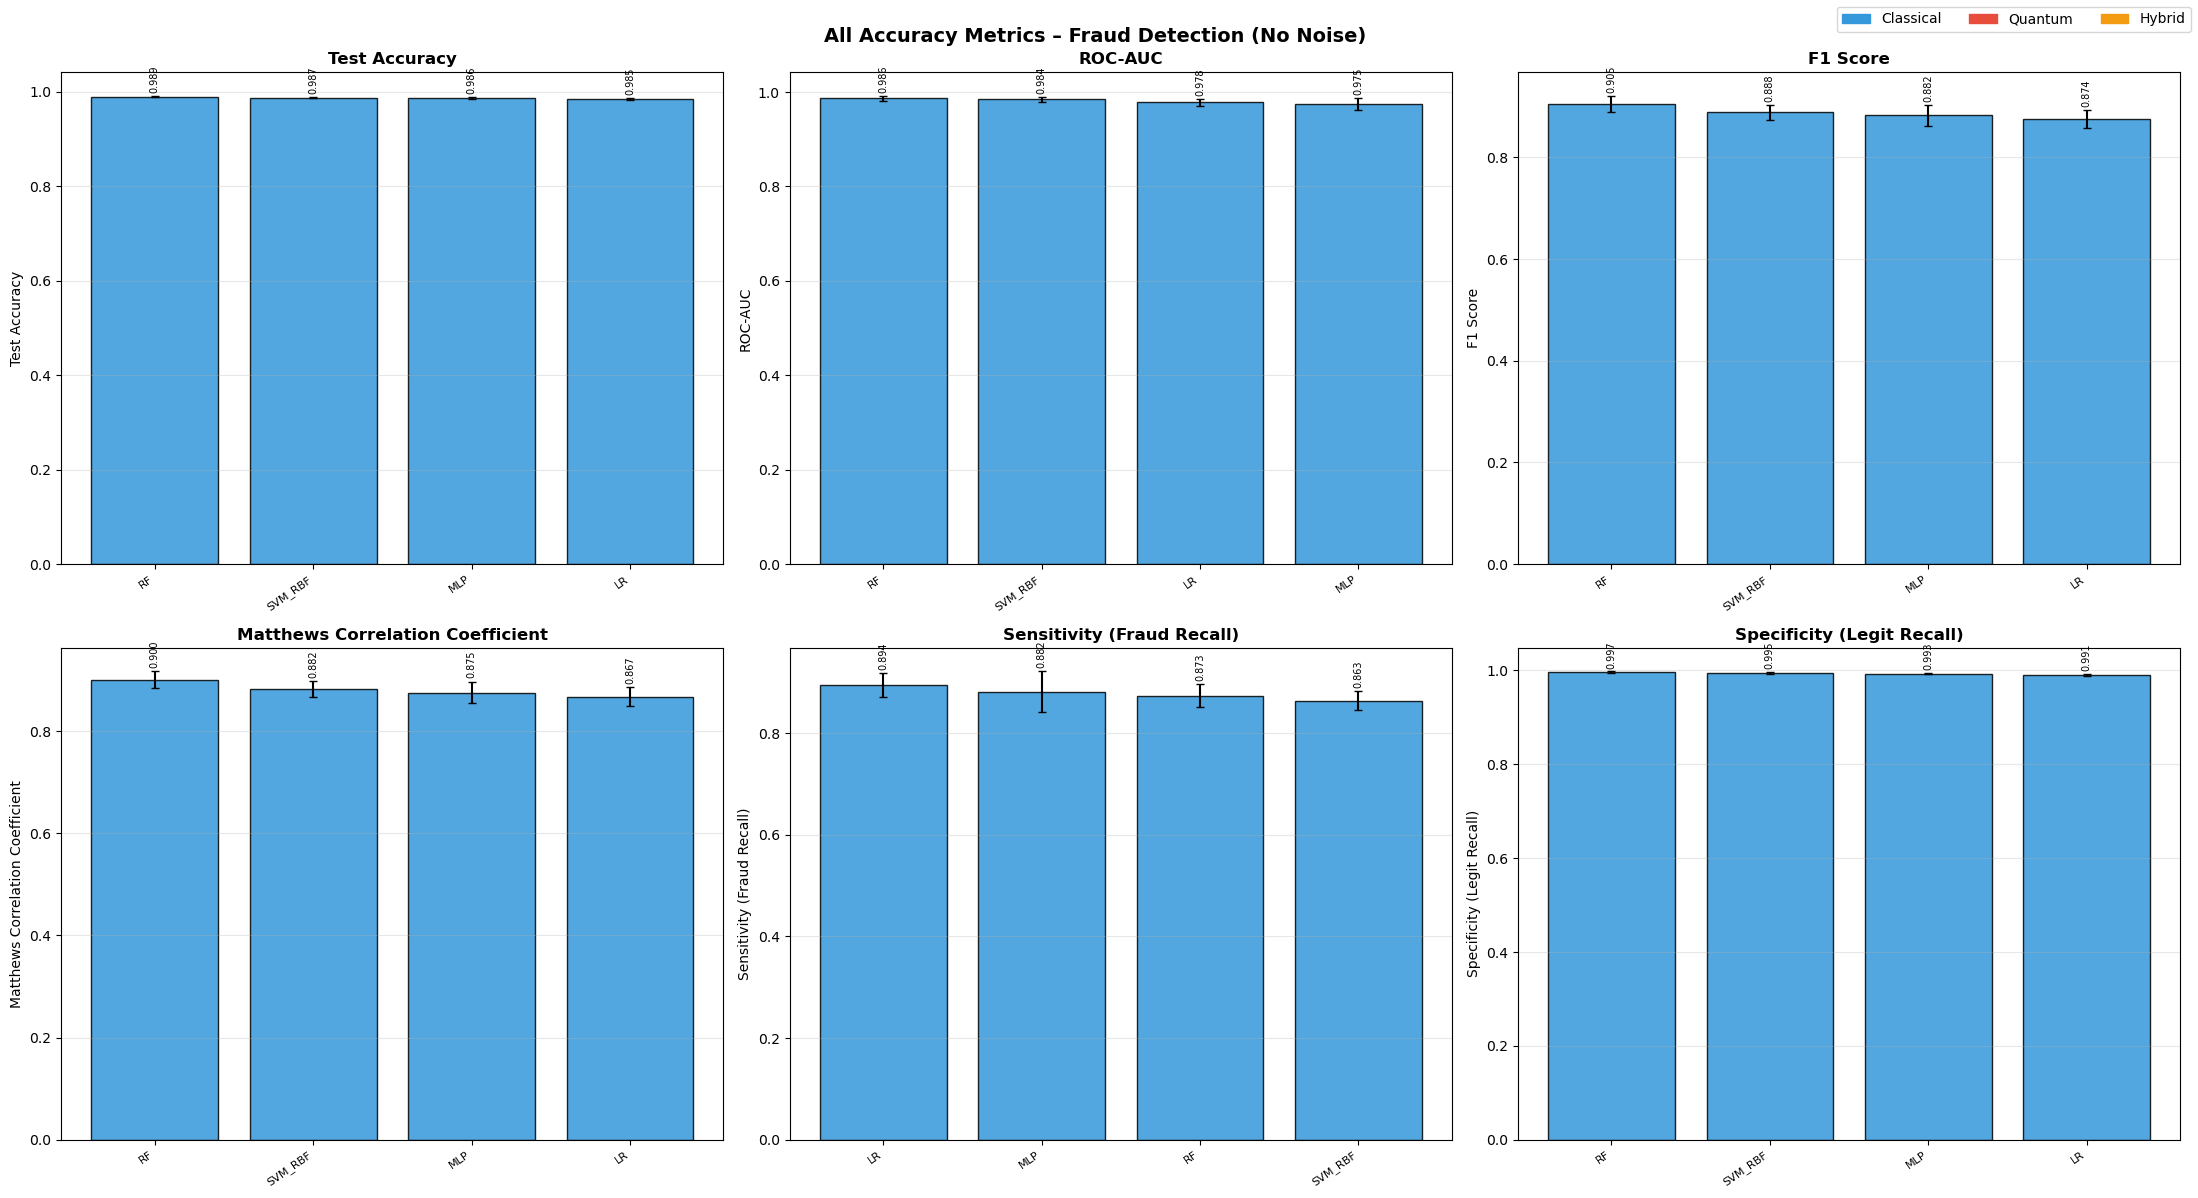

All accuracy metrics plot saved.


In [16]:
df_ideal = df_main[df_main['noise']=='none'].copy()
order = df_ideal.groupby('model')['acc'].mean().sort_values(ascending=False).index

cat_col = {'LR':'#3498db','SVM_RBF':'#3498db','RF':'#3498db','MLP':'#3498db',
           'VQC':'#e74c3c','QCNN':'#e74c3c','QKernel_SVM':'#e74c3c','QAOA_VQC':'#e74c3c',
           'HybridNet':'#f39c12','QuantumBoost':'#f39c12','QResNet':'#f39c12'}

# ── Plot 1: All accuracy metrics overview ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('All Accuracy Metrics – Fraud Detection (No Noise)', fontsize=14, fontweight='bold')
axes = axes.flatten()

metrics_list = [
    ('acc',         'Test Accuracy'),
    ('auc',         'ROC-AUC'),
    ('f1',          'F1 Score'),
    ('mcc',         'Matthews Correlation Coefficient'),
    ('sensitivity', 'Sensitivity (Fraud Recall)'),
    ('specificity', 'Specificity (Legit Recall)'),
]

for ax, (metric, label) in zip(axes, metrics_list):
    ord_m = df_ideal.groupby('model')[metric].mean().sort_values(ascending=False).index
    means = df_ideal.groupby('model')[metric].mean().loc[ord_m]
    stds  = df_ideal.groupby('model')[metric].std().loc[ord_m]
    cols  = [cat_col.get(m, 'gray') for m in ord_m]
    bars  = ax.bar(range(len(ord_m)), means.values, yerr=stds.values,
                   color=cols, edgecolor='k', alpha=0.85, capsize=3)
    ax.set_xticks(range(len(ord_m)))
    ax.set_xticklabels(ord_m, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel(label); ax.set_title(label, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, v, s in zip(bars, means.values, stds.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.01,
                f'{v:.3f}', ha='center', fontsize=7, rotation=90)

legend_h = [mpatches.Patch(color='#3498db', label='Classical'),
            mpatches.Patch(color='#e74c3c', label='Quantum'),
            mpatches.Patch(color='#f39c12', label='Hybrid')]
fig.legend(handles=legend_h, fontsize=10, loc='upper right', ncol=3)
plt.tight_layout()
plt.savefig(RES_DIR + 'all_accuracy_metrics.png', dpi=120, bbox_inches='tight')
plt.show()
print("All accuracy metrics plot saved.")


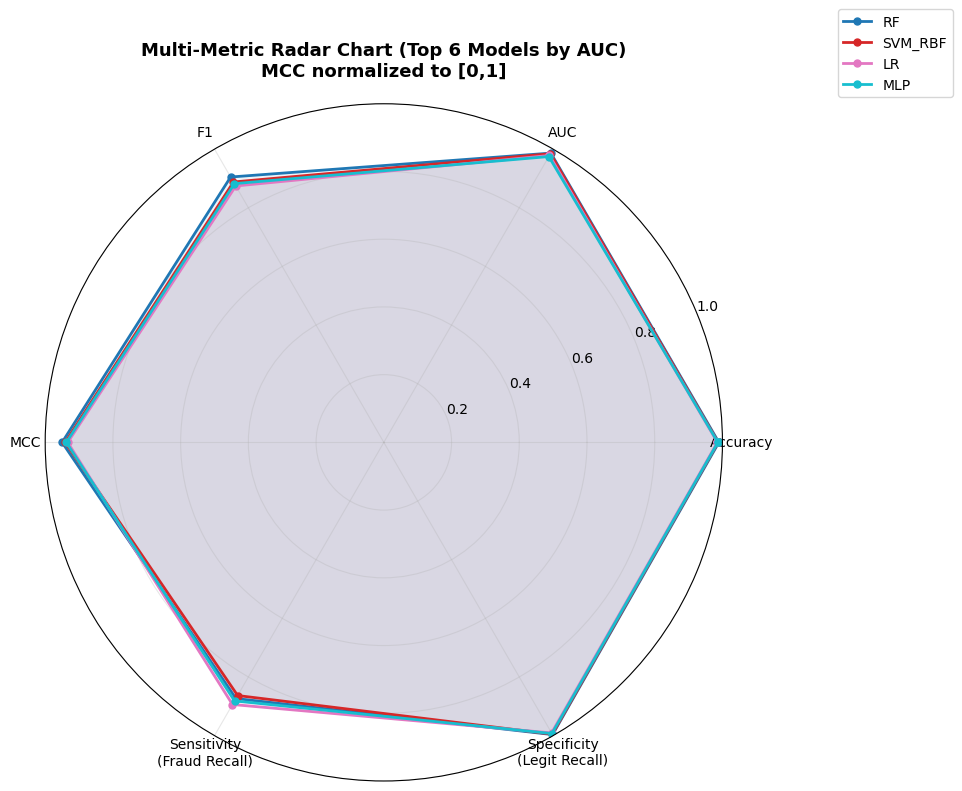

Radar chart saved.


In [17]:
# ── Plot 2: Multi-metric radar chart ─────────────────────
radar_metrics = ['acc', 'auc', 'f1', 'mcc', 'sensitivity', 'specificity']
radar_labels  = ['Accuracy', 'AUC', 'F1', 'MCC', 'Sensitivity\n(Fraud Recall)', 'Specificity\n(Legit Recall)']

df_radar = df_ideal.groupby('model')[radar_metrics].mean()
df_radar['mcc'] = (df_radar['mcc'] + 1) / 2   # normalize MCC to [0,1]

angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

top_models = df_radar['auc'].nlargest(6).index.tolist()   # top by AUC (more meaningful for fraud)
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors_radar = plt.cm.tab10(np.linspace(0, 1, len(top_models)))

for model, col in zip(top_models, colors_radar):
    vals = df_radar.loc[model, radar_metrics].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', color=col, lw=2, label=model, ms=5)
    ax.fill(angles, vals, alpha=0.08, color=col)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Multi-Metric Radar Chart (Top 6 Models by AUC)\nMCC normalized to [0,1]',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RES_DIR + 'radar_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print("Radar chart saved.")


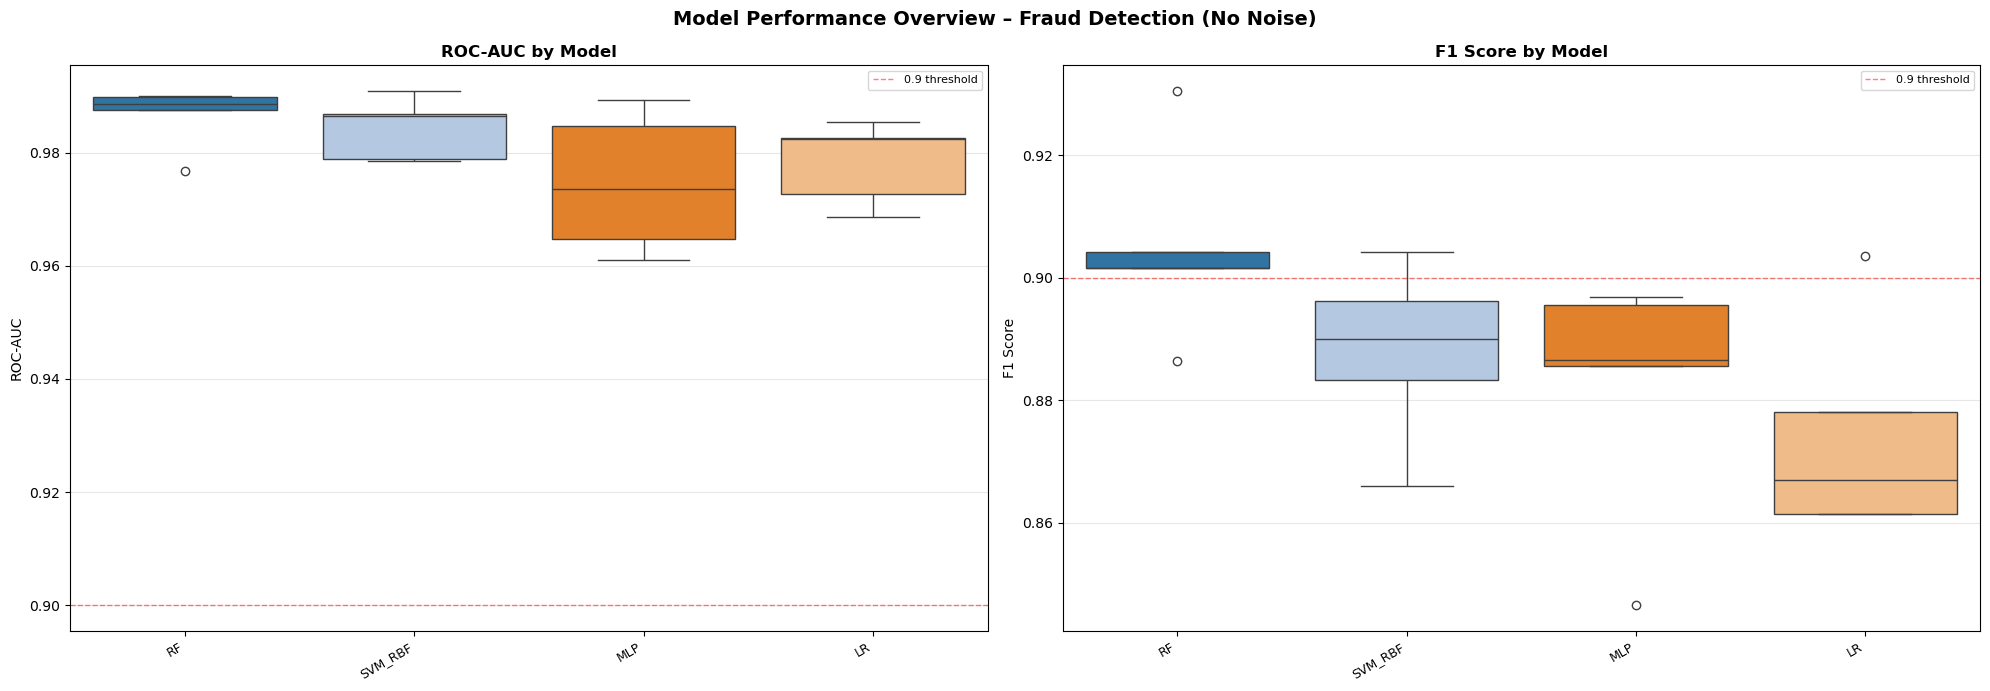

In [18]:
# ── Plot 3: Accuracy & AUC overview boxplot ────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Model Performance Overview – Fraud Detection (No Noise)', fontsize=14, fontweight='bold')

for ax, metric, label in zip(axes, ['auc','f1'], ['ROC-AUC','F1 Score']):
    sns.boxplot(data=df_ideal, x='model', y=metric, order=order, palette='tab20', ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.set_title(f'{label} by Model', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel(label)
    ax.axhline(0.9, color='red', ls='--', lw=1, alpha=0.5, label='0.9 threshold')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR + 'benchmark_overview.png', dpi=120, bbox_inches='tight')
plt.show()


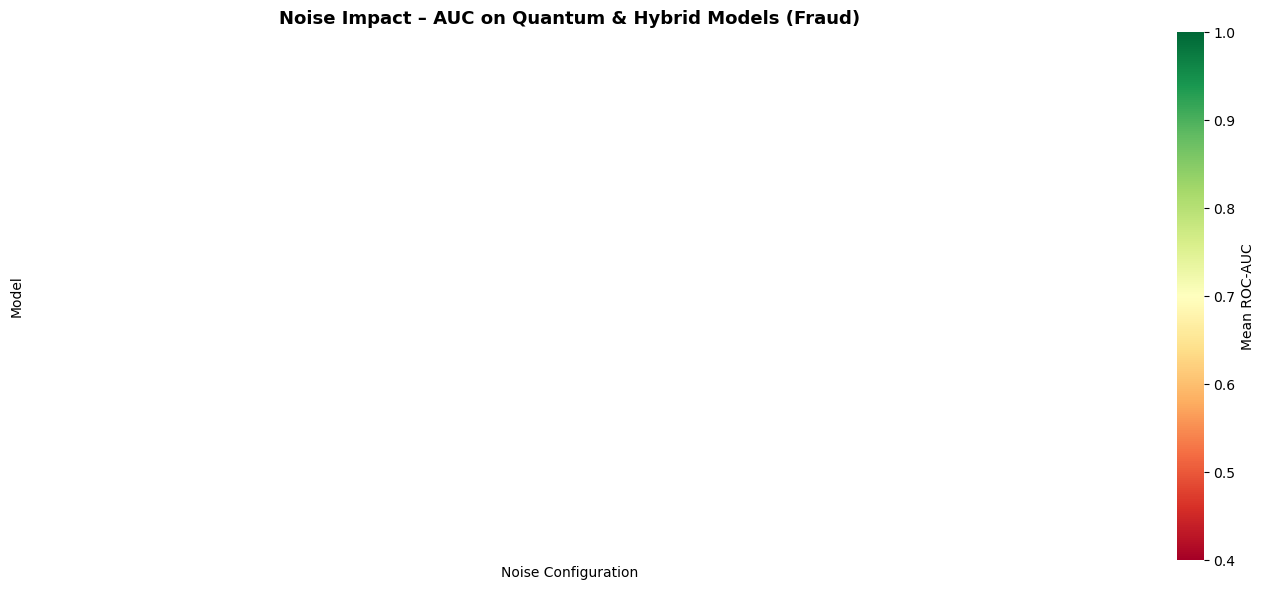

In [19]:
# ── Plot 4: Noise impact heatmap ──────────────────────────
quantum_models = ['VQC','QCNN','QKernel_SVM','QAOA_VQC','HybridNet','QuantumBoost','QResNet']
df_noise = df_main[df_main['model'].isin(quantum_models)].copy()
df_noise['noise_label'] = df_noise.apply(
    lambda r: f"{r['noise']}\np={r['noise_param']:.2f}", axis=1)

pivot_noise = df_noise.pivot_table(index='model', columns='noise_label', values='auc', aggfunc='mean')

fig, ax = plt.subplots(figsize=(max(14, len(pivot_noise.columns)*1.4), 6))
sns.heatmap(pivot_noise, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.4, vmax=1.0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Mean ROC-AUC'})
ax.set_title('Noise Impact – AUC on Quantum & Hybrid Models (Fraud)', fontsize=13, fontweight='bold')
ax.set_xlabel('Noise Configuration'); ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(RES_DIR + 'noise_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


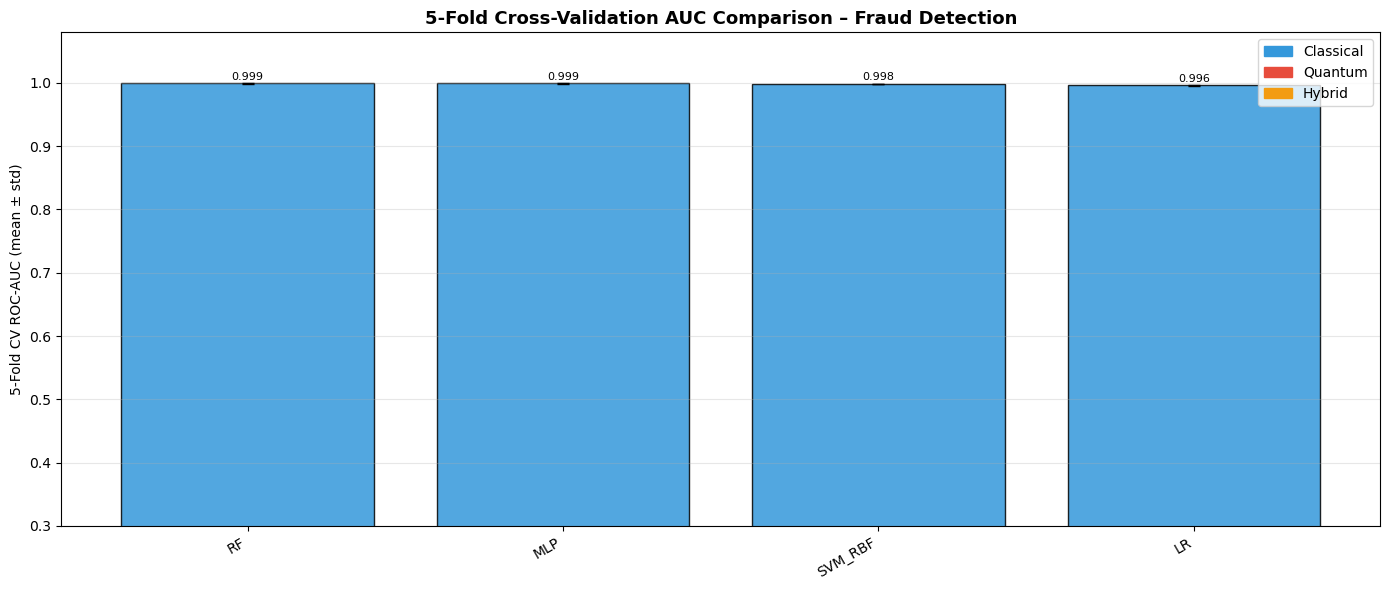

In [20]:
# ── Plot 5: 5-fold CV AUC comparison ──────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
order_cv = df_ideal.groupby('model')['cv_mean'].mean().sort_values(ascending=False).index
means = df_ideal.groupby('model')['cv_mean'].mean().loc[order_cv]
stds  = df_ideal.groupby('model')['cv_std'].mean().loc[order_cv]

colors = []
for m in order_cv:
    if m in ['VQC','QCNN','QKernel_SVM','QAOA_VQC']: colors.append('#e74c3c')
    elif m in ['HybridNet','QuantumBoost','QResNet']:  colors.append('#f39c12')
    else:                                               colors.append('#3498db')

bars = ax.bar(range(len(order_cv)), means, yerr=stds, capsize=4,
              color=colors, edgecolor='k', alpha=0.85, error_kw={'lw':1.5})
ax.set_xticks(range(len(order_cv)))
ax.set_xticklabels(order_cv, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('5-Fold CV ROC-AUC (mean ± std)')
ax.set_title('5-Fold Cross-Validation AUC Comparison – Fraud Detection', fontsize=13, fontweight='bold')
ax.set_ylim(0.3, 1.08); ax.grid(axis='y', alpha=0.3)
legend_patches = [mpatches.Patch(color='#3498db', label='Classical'),
                  mpatches.Patch(color='#e74c3c', label='Quantum'),
                  mpatches.Patch(color='#f39c12', label='Hybrid')]
ax.legend(handles=legend_patches, fontsize=10)
for bar, v, s in zip(bars, means, stds):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.005,
            f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(RES_DIR + 'cv_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


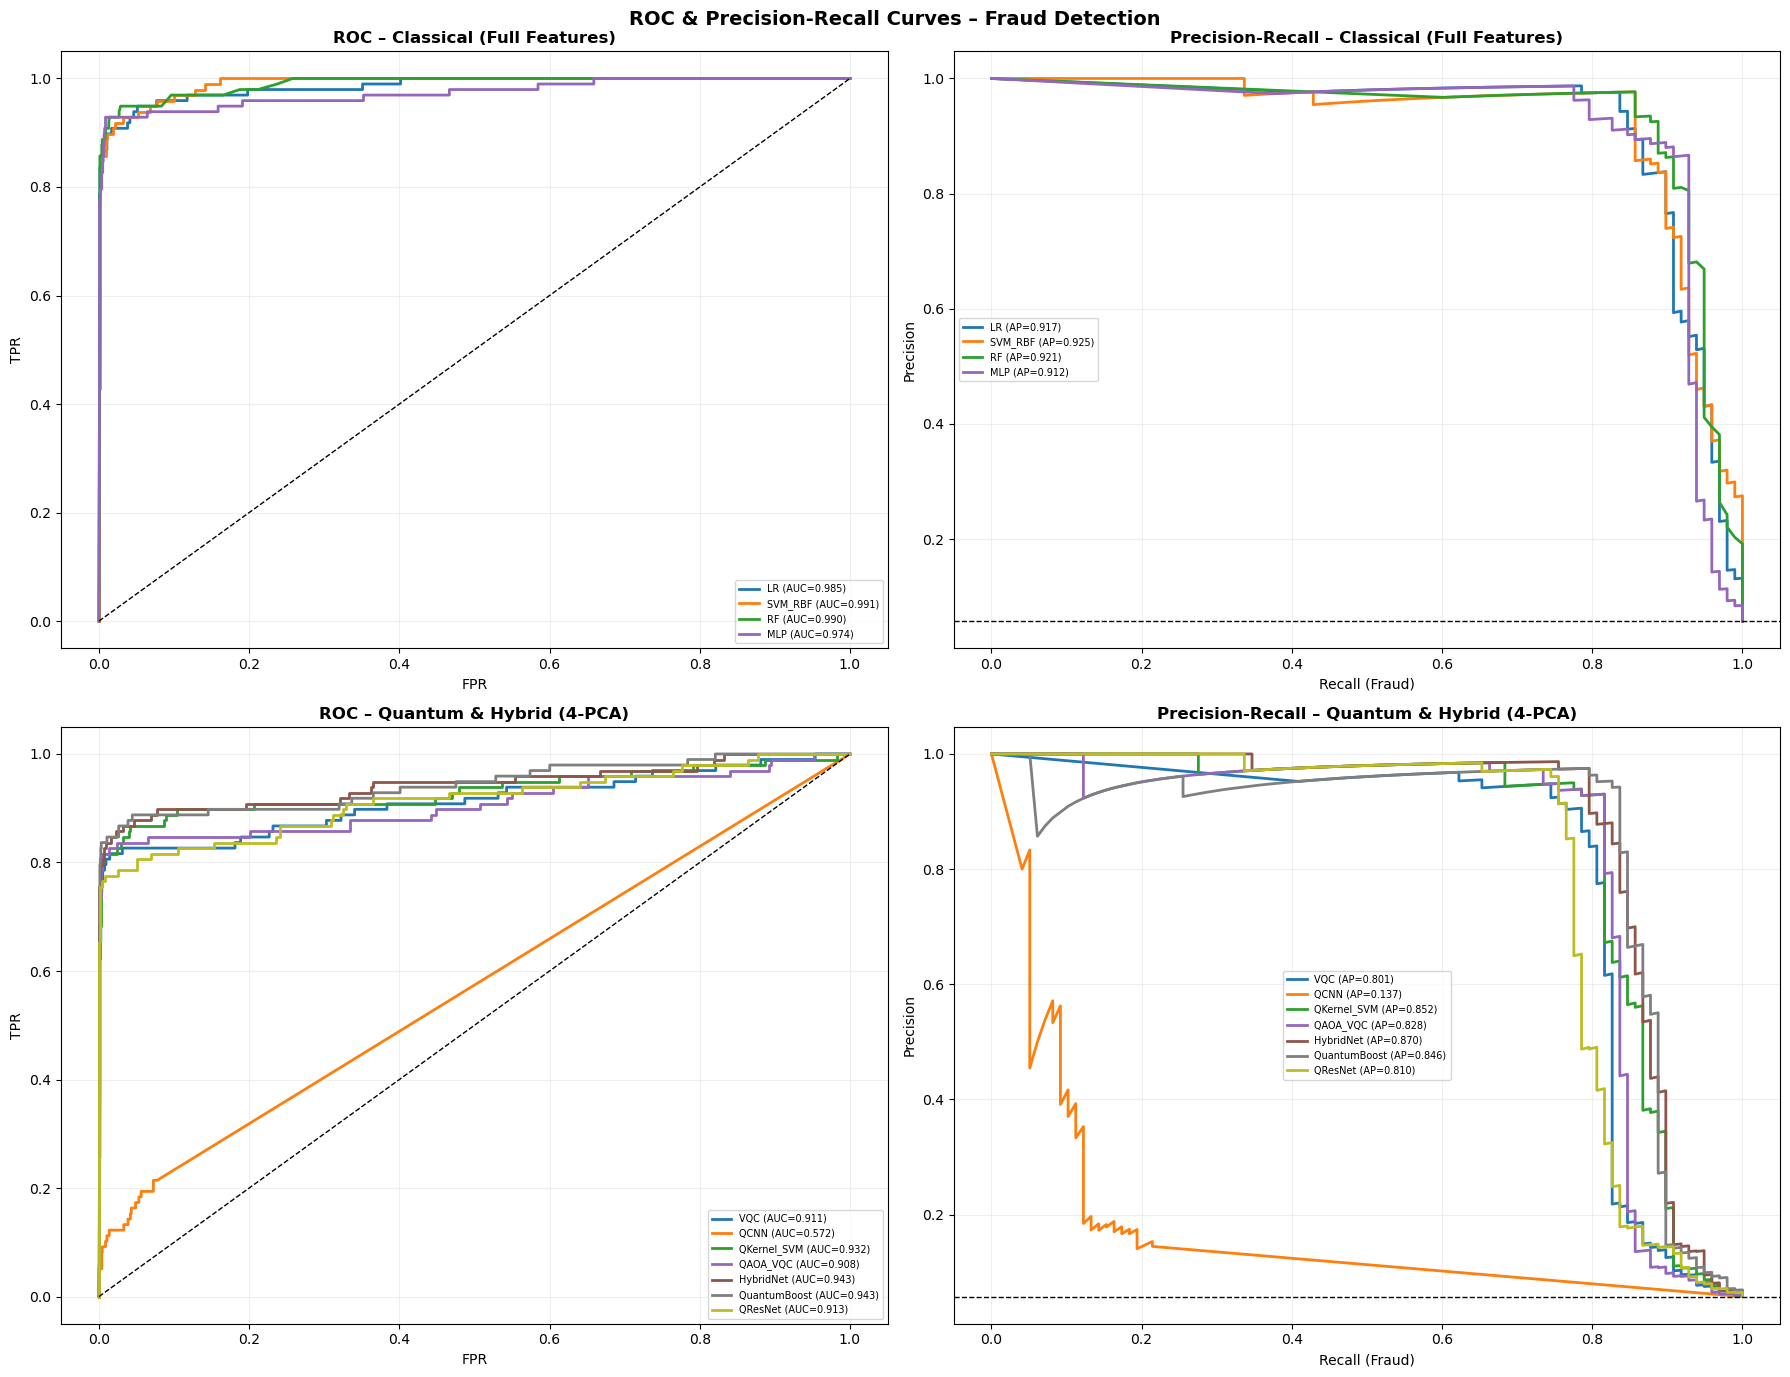

In [21]:
# ── Plot 6: ROC curves + Precision-Recall curves ──────────
X_np = X_df.values; y_np = y_s.values
Xtr_r, Xte_r, ytr_r, yte_r = preprocess_dataset(X_np, y_np, n_features=4, seed=0, use_pca=True)
Xtr_f2, Xte_f2, ytr_f2, yte_f2 = preprocess_dataset(X_np, y_np, n_features=X_np.shape[1], seed=0, use_pca=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('ROC & Precision-Recall Curves – Fraud Detection', fontsize=14, fontweight='bold')

model_sets = [
    ('Classical (Full Features)', ['LR','SVM_RBF','RF','MLP'], Xtr_f2, Xte_f2, ytr_f2, yte_f2),
    ('Quantum & Hybrid (4-PCA)',  ['VQC','QCNN','QKernel_SVM','QAOA_VQC','HybridNet','QuantumBoost','QResNet'],
     Xtr_r, Xte_r, ytr_r, yte_r),
]
colors_roc = plt.cm.tab10(np.linspace(0,1,8))

for row_idx, (title, mnames, Xtr_, Xte_, ytr_, yte_) in enumerate(model_sets):
    ax_roc = axes[row_idx, 0]; ax_pr = axes[row_idx, 1]
    all_m = get_all_models(n_qubits=4, seed=0, maxiter=60)
    for mname, col in zip(mnames, colors_roc):
        if mname not in all_m: continue
        m = copy.deepcopy(all_m[mname])
        try:
            m.fit(Xtr_, ytr_)
            proba = m.predict_proba(Xte_)[:,1]
            fpr, tpr, _  = roc_curve(yte_, proba)
            prec, rec, _ = precision_recall_curve(yte_, proba)
            auc_ = roc_auc_score(yte_, proba)
            ap_  = average_precision_score(yte_, proba)
            ax_roc.plot(fpr, tpr, lw=2, color=col, label=f'{mname} (AUC={auc_:.3f})')
            ax_pr.plot(rec, prec, lw=2, color=col, label=f'{mname} (AP={ap_:.3f})')
        except Exception as e:
            print(f"[ROC skip] {mname}: {e}")
    ax_roc.plot([0,1],[0,1],'k--',lw=1)
    ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
    ax_roc.set_title(f'ROC – {title}', fontweight='bold'); ax_roc.legend(fontsize=7); ax_roc.grid(alpha=0.2)
    ax_pr.set_xlabel('Recall (Fraud)'); ax_pr.set_ylabel('Precision')
    ax_pr.set_title(f'Precision-Recall – {title}', fontweight='bold')
    ax_pr.legend(fontsize=7); ax_pr.grid(alpha=0.2)
    # Baseline
    baseline = (yte_==1).mean()
    ax_pr.axhline(baseline, color='k', ls='--', lw=1, label=f'Baseline ({baseline:.3f})')

plt.tight_layout()
plt.savefig(RES_DIR + 'roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()


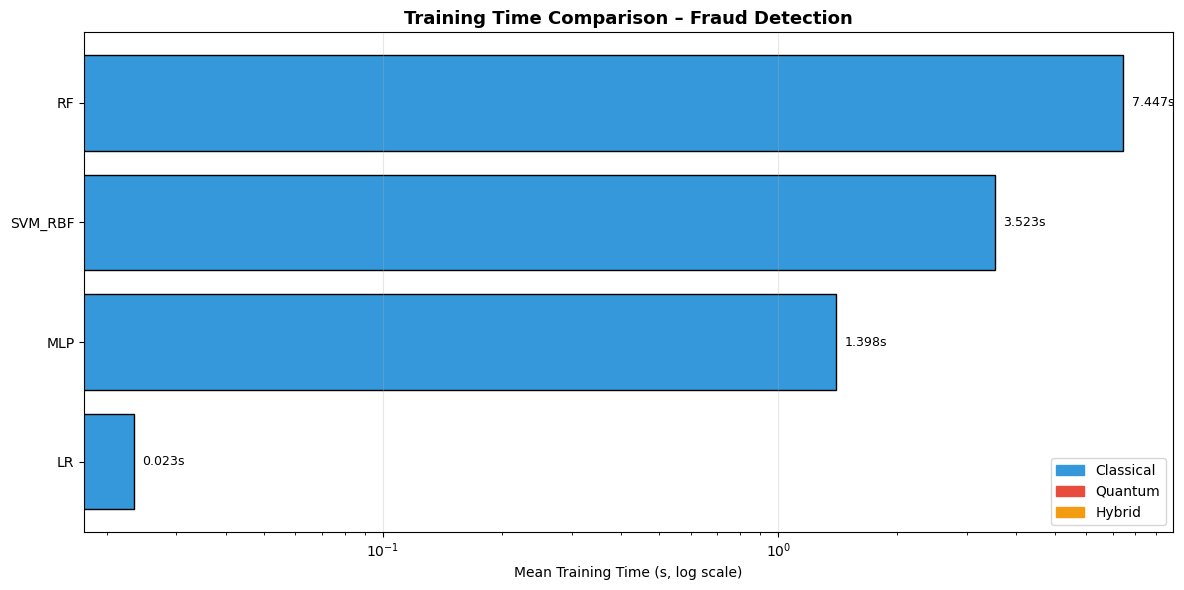

In [22]:
# ── Plot 7: Training time ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
time_order = df_ideal.groupby('model')['train_time'].mean().sort_values()
colors_t = ['#e74c3c' if m in ['VQC','QCNN','QKernel_SVM','QAOA_VQC'] else
            '#f39c12' if m in ['HybridNet','QuantumBoost','QResNet'] else
            '#3498db' for m in time_order.index]
bars = ax.barh(time_order.index, time_order.values, color=colors_t, edgecolor='k')
ax.set_xscale('log')
ax.set_xlabel('Mean Training Time (s, log scale)')
ax.set_title('Training Time Comparison – Fraud Detection', fontsize=13, fontweight='bold')
for bar, val in zip(bars, time_order.values):
    ax.text(val*1.05, bar.get_y()+bar.get_height()/2, f'{val:.3f}s', va='center', fontsize=9)
legend_patches = [mpatches.Patch(color='#3498db', label='Classical'),
                  mpatches.Patch(color='#e74c3c', label='Quantum'),
                  mpatches.Patch(color='#f39c12', label='Hybrid')]
ax.legend(handles=legend_patches); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RES_DIR + 'training_time.png', dpi=120, bbox_inches='tight')
plt.show()


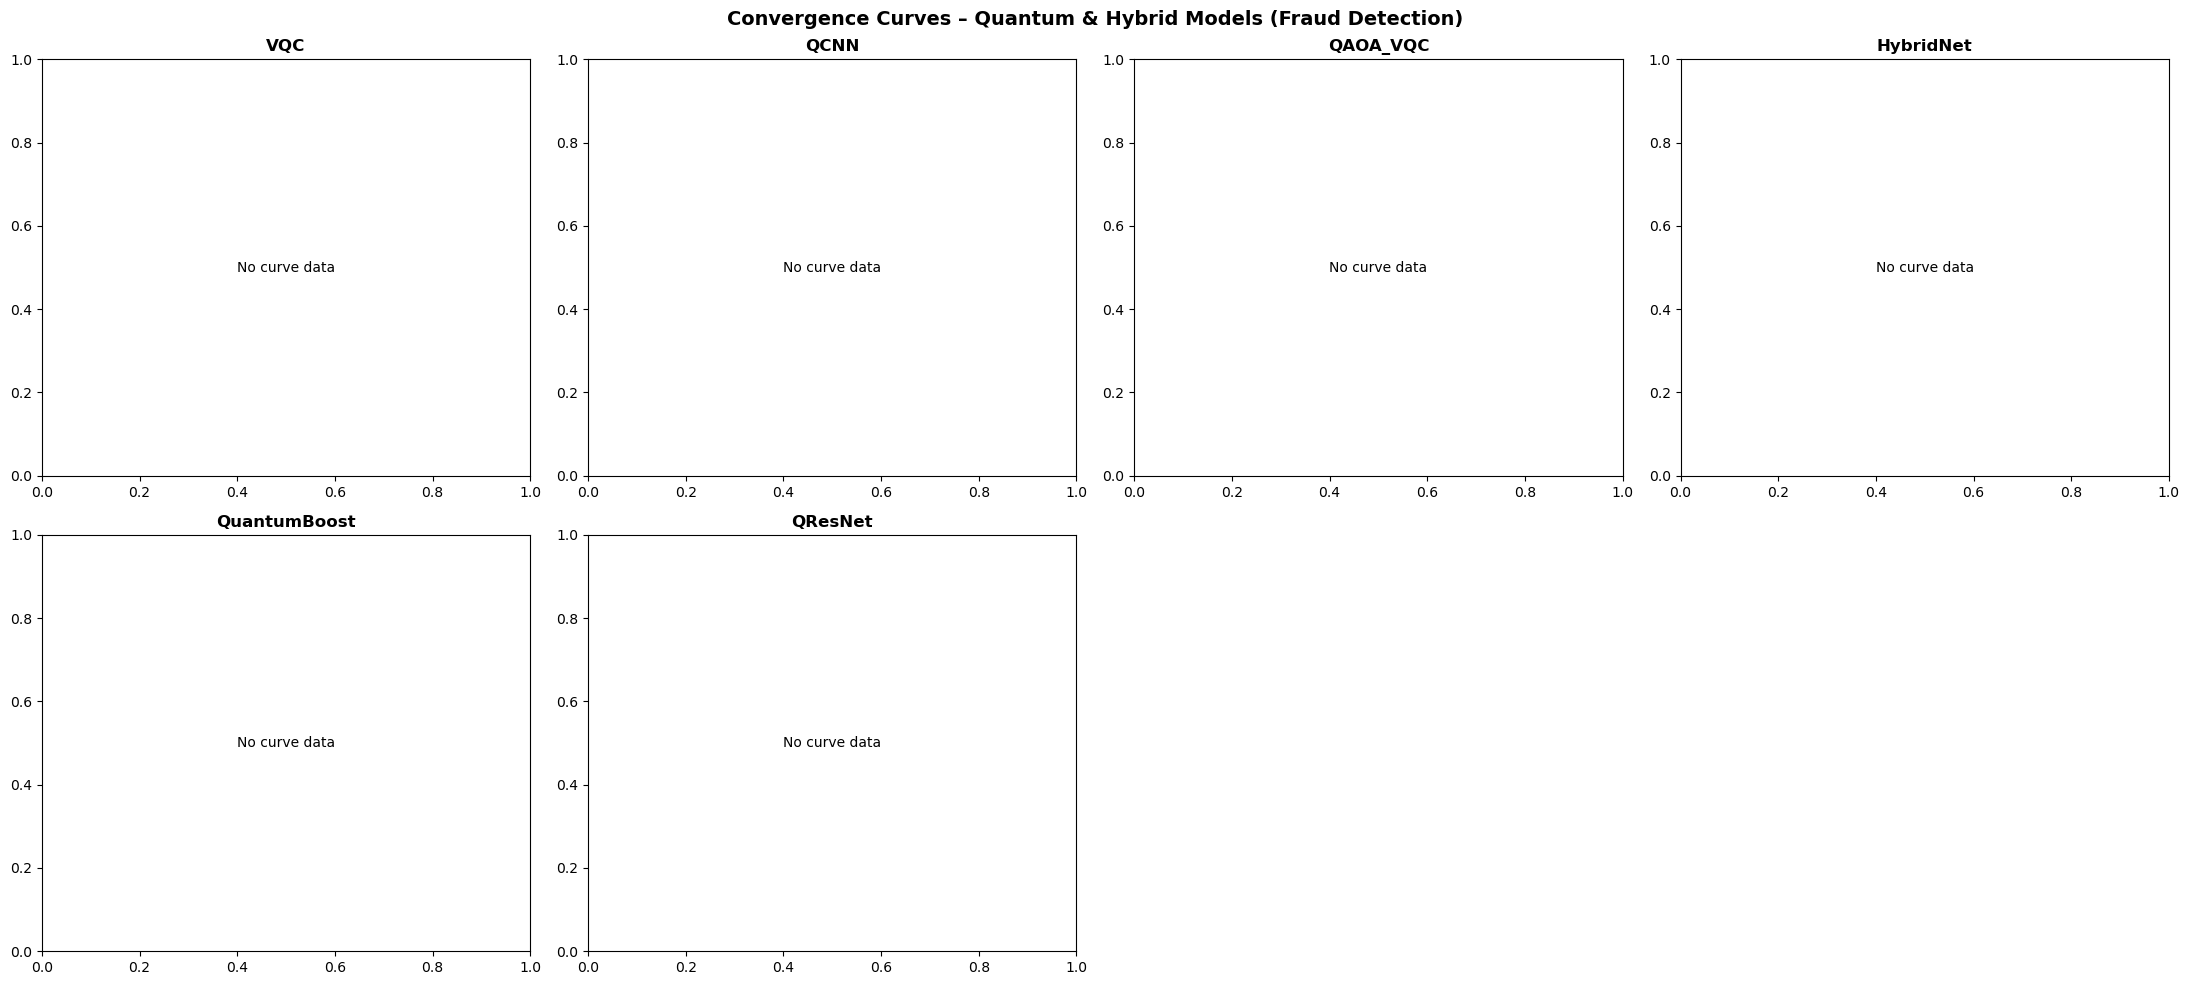

In [23]:
# ── Plot 8: Convergence curves ────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Convergence Curves – Quantum & Hybrid Models (Fraud Detection)', fontsize=14, fontweight='bold')
axes = axes.flatten()
q_hybrid = ['VQC','QCNN','QAOA_VQC','HybridNet','QuantumBoost','QResNet']

for ax, mname in zip(axes, q_hybrid):
    curves = [r['loss_curve'] for _, r in df_main[
        (df_main['model']==mname) & (df_main['noise']=='none')].iterrows()
              if isinstance(r['loss_curve'], list) and len(r['loss_curve'])>0]
    if not curves:
        ax.text(0.5, 0.5, 'No curve data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(mname, fontweight='bold'); continue
    for c in curves: ax.plot(c, alpha=0.3, lw=1, color='steelblue')
    max_len = max(len(c) for c in curves)
    padded = [np.interp(np.linspace(0,1,max_len), np.linspace(0,1,len(c)), c) for c in curves]
    mn = np.mean(padded, 0); sd = np.std(padded, 0)
    ax.plot(mn, 'r-', lw=2.5, label='Mean')
    ax.fill_between(range(max_len), mn-sd, mn+sd, alpha=0.2, color='red')
    ax.set_title(mname, fontweight='bold')
    ax.set_xlabel('Iteration'); ax.set_ylabel('Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

for ax in axes[len(q_hybrid):]: ax.axis('off')
plt.tight_layout()
plt.savefig(RES_DIR + 'convergence_curves.png', dpi=120, bbox_inches='tight')
plt.show()


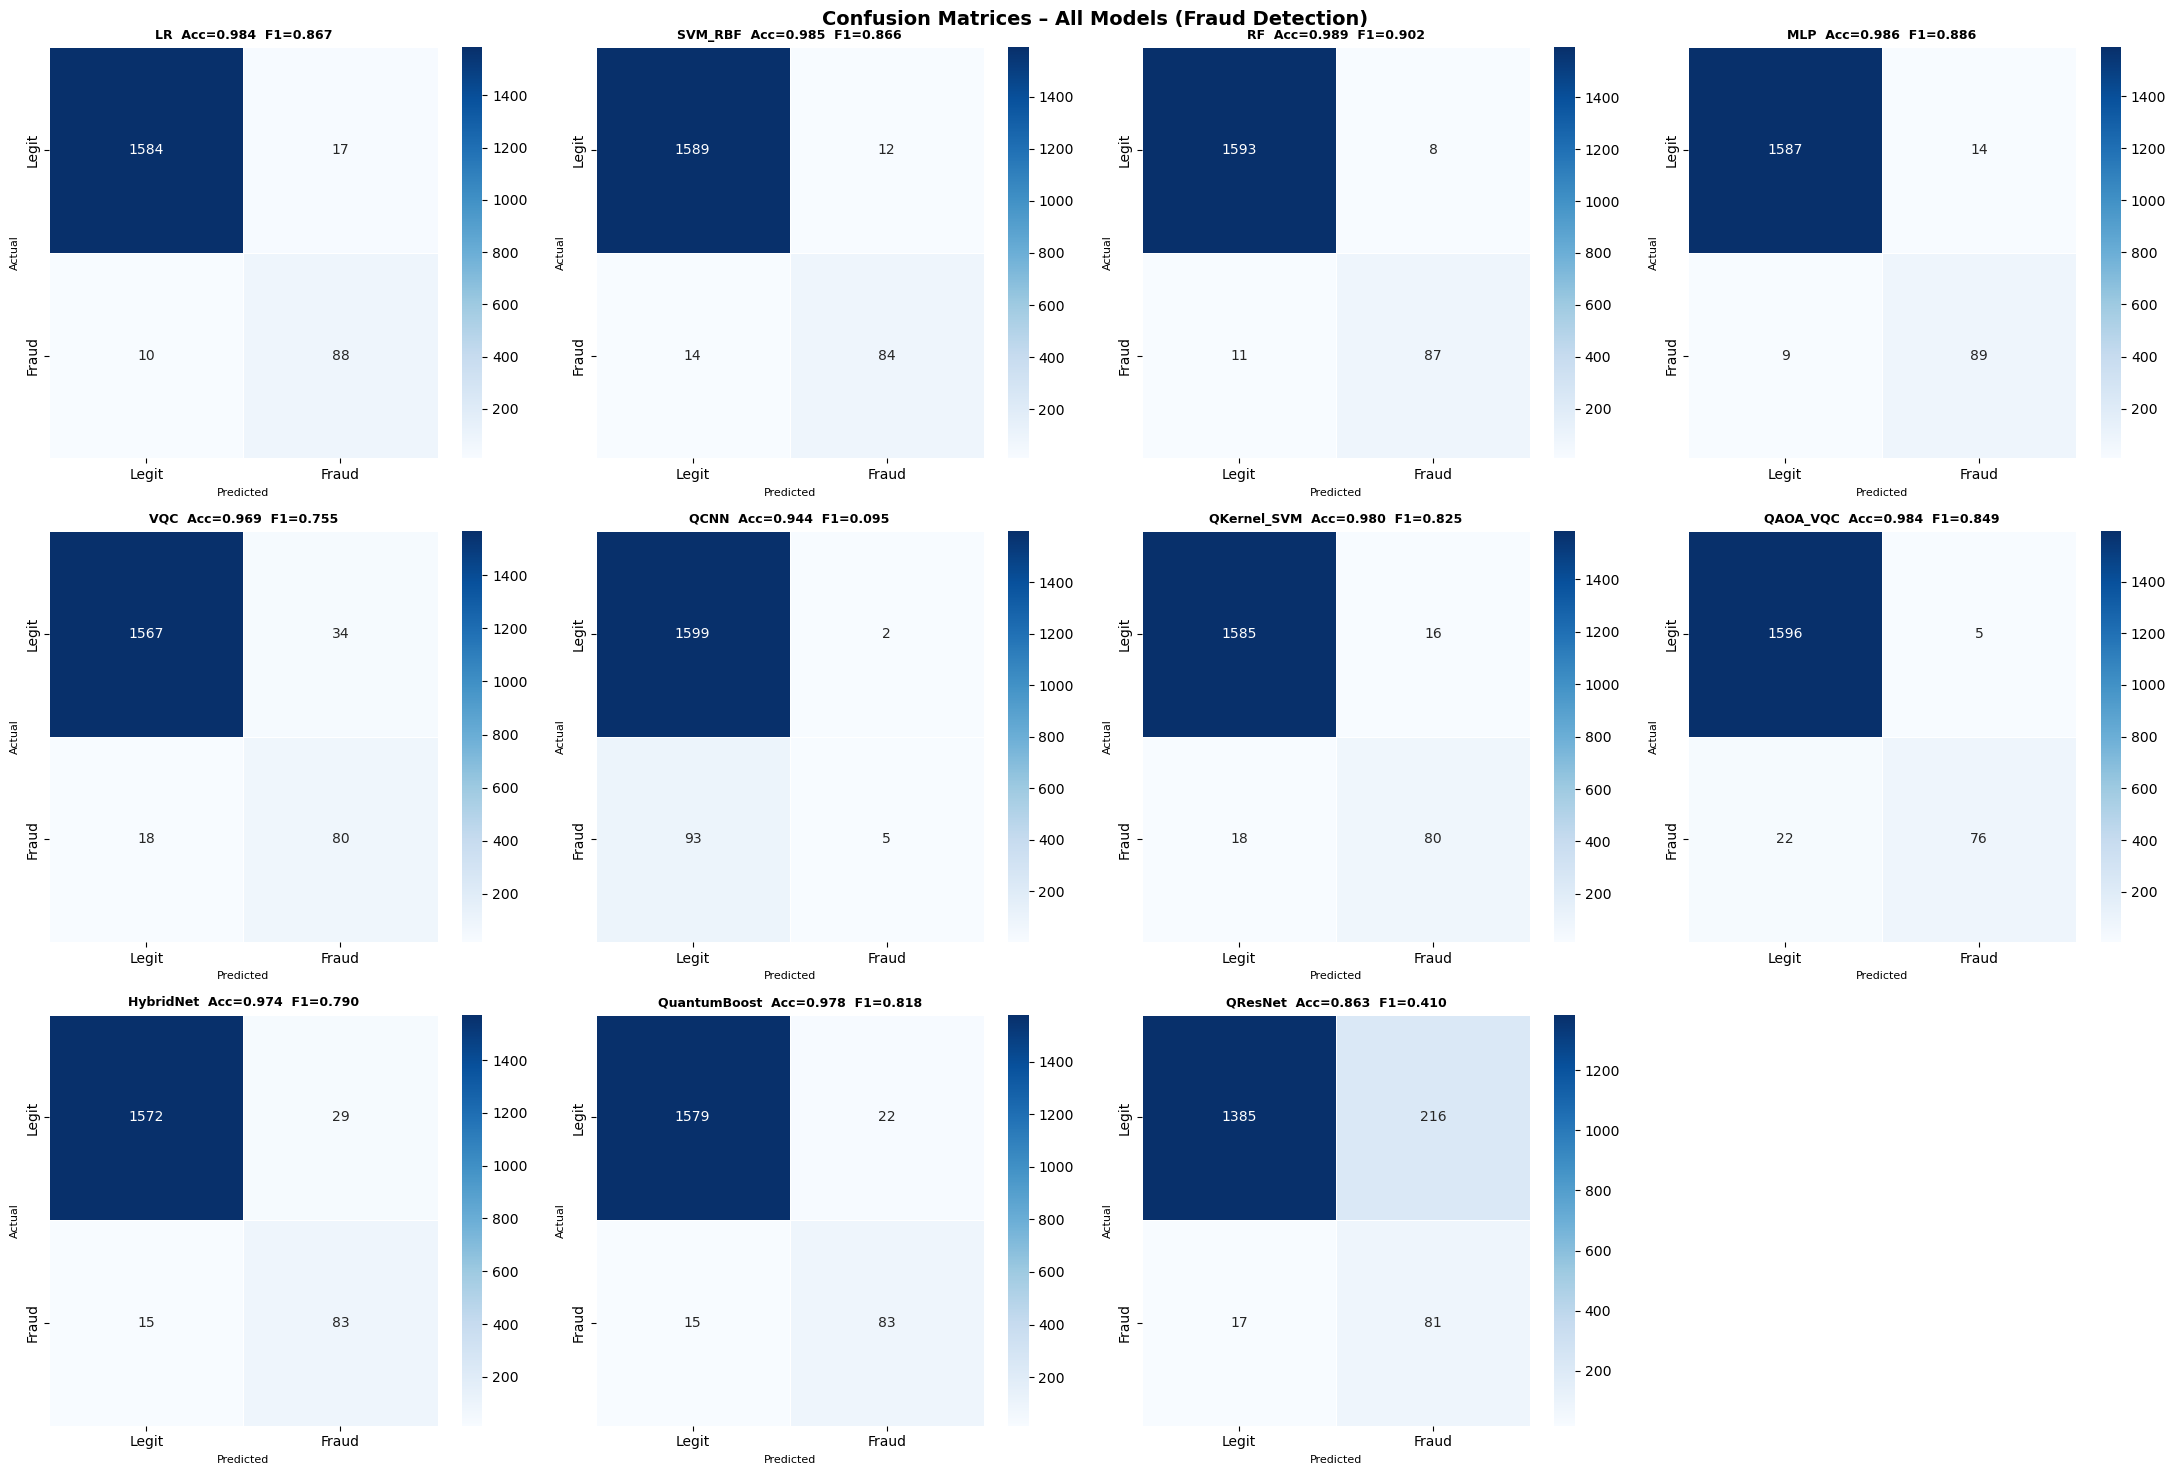

In [24]:
# ── Plot 9: Confusion matrices ────────────────────────────
X_np = X_df.values; y_np = y_s.values
Xtr_r, Xte_r, ytr_r, yte_r = preprocess_dataset(X_np, y_np, n_features=4, seed=0)
Xtr_f2, Xte_f2, ytr_f2, yte_f2 = preprocess_dataset(X_np, y_np, n_features=X_np.shape[1], seed=0, use_pca=False)

all_m    = get_all_models(n_qubits=4, seed=0, maxiter=60)
cl_names = ['LR','SVM_RBF','RF','MLP']
qh_names = ['VQC','QCNN','QKernel_SVM','QAOA_VQC','HybridNet','QuantumBoost','QResNet']

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
fig.suptitle('Confusion Matrices – All Models (Fraud Detection)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, mname in enumerate(cl_names + qh_names):
    ax   = axes[i]
    m    = copy.deepcopy(all_m[mname])
    Xtr_ = Xtr_f2 if mname in cl_names else Xtr_r
    Xte_ = Xte_f2 if mname in cl_names else Xte_r
    ytr_ = ytr_f2 if mname in cl_names else ytr_r
    yte_ = yte_f2 if mname in cl_names else yte_r
    try:
        m.fit(Xtr_, ytr_); pred = m.predict(Xte_)
        cm  = confusion_matrix(yte_, pred)
        acc = accuracy_score(yte_, pred)
        f1  = f1_score(yte_, pred, zero_division=0)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'], linewidths=0.5)
        ax.set_title(f'{mname}  Acc={acc:.3f}  F1={f1:.3f}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Predicted', fontsize=8); ax.set_ylabel('Actual', fontsize=8)
    except Exception as e:
        ax.text(0.5, 0.5, f'{mname}\n{str(e)[:30]}', ha='center', va='center',
                transform=ax.transAxes, fontsize=8)
        ax.axis('off')

for ax in axes[len(cl_names+qh_names):]: ax.axis('off')
plt.tight_layout()
plt.savefig(RES_DIR + 'confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


## 13) Ablation Study

In [25]:
def run_ablation(seeds=range(3)):
    """Ablation: vary qubits, reps, shots for VQC and QCNN."""
    X_np = X_df.values; y_np = y_s.values
    rows = []
    for n_q in [2, 4, 6, 8]:
        for reps in [1, 2, 3]:
            for shots in [64, 256, 1024]:
                for seed in seeds:
                    set_seed(seed)
                    Xtr, Xte, ytr, yte = preprocess_dataset(
                        X_np, y_np, n_features=n_q, seed=seed, use_pca=True, subsample_train=1500)
                    for mname, cls_ in [('VQC', NumpyVQC), ('QCNN', NumpyQCNN)]:
                        try:
                            m   = cls_(n_qubits=n_q, reps=reps, shots=shots, seed=seed, maxiter=60)
                            res = evaluate_model(m, Xtr, ytr, Xte, yte, cv_folds=3)
                            rows.append(dict(model=mname, n_qubits=n_q, reps=reps,
                                             shots=shots, seed=seed,
                                             acc=res['acc'], auc=res['auc'],
                                             f1=res['f1'], mcc=res['mcc']))
                        except: pass
    return pd.DataFrame(rows)


print("Running ablation study...")
df_ablation = run_ablation(seeds=range(3))
print(f"Ablation rows: {len(df_ablation)}")


Running ablation study...
Ablation rows: 216


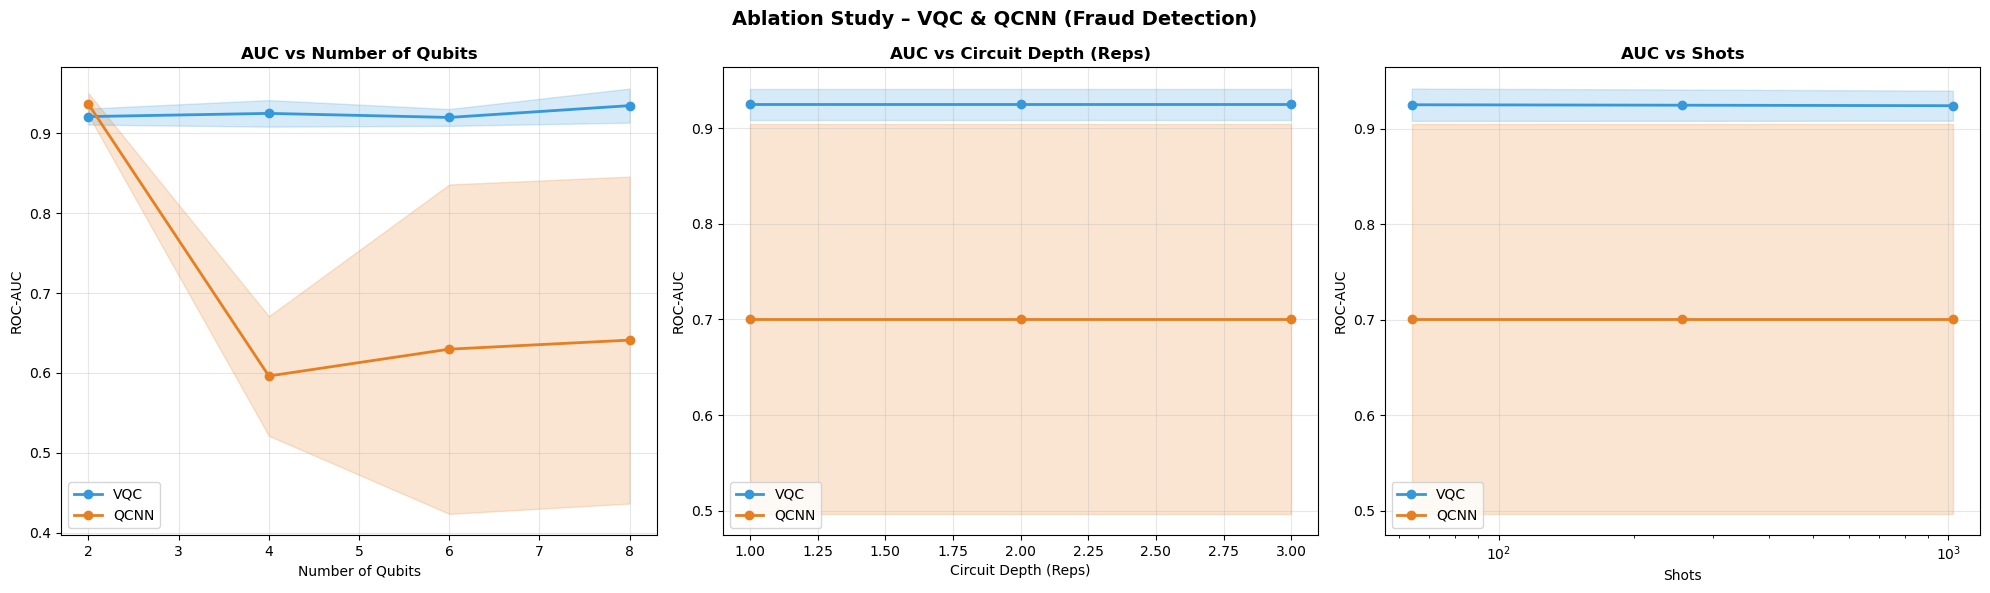

In [26]:
# ── Ablation plots ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Ablation Study – VQC & QCNN (Fraud Detection)', fontsize=14, fontweight='bold')

for ax, var, xlabel in zip(axes,
    ['n_qubits','reps','shots'], ['Number of Qubits','Circuit Depth (Reps)','Shots']):
    for mname, col in [('VQC','#3498db'), ('QCNN','#e67e22')]:
        sub  = df_ablation[df_ablation['model']==mname].groupby(var)['auc']
        mean_ = sub.mean(); std_ = sub.std()
        ax.plot(mean_.index, mean_.values, 'o-', color=col, lw=2, label=mname)
        ax.fill_between(mean_.index, mean_-std_, mean_+std_, alpha=0.2, color=col)
    ax.set_xlabel(xlabel); ax.set_ylabel('ROC-AUC')
    ax.set_title(f'AUC vs {xlabel}', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    if var == 'shots': ax.set_xscale('log')

plt.tight_layout()
plt.savefig(RES_DIR + 'ablation_study.png', dpi=120, bbox_inches='tight')
plt.show()


## 14) Statistical Tests

In [27]:
def run_statistical_tests(df: pd.DataFrame):
    df_no_noise = df[df['noise']=='none'].copy()
    models      = df_no_noise['model'].unique()

    cl_models = ['LR','SVM_RBF','RF','MLP']
    best_cl   = df_no_noise[df_no_noise['model'].isin(cl_models)].groupby('model')['cv_mean'].mean().idxmax()
    cl_accs   = df_no_noise[df_no_noise['model']==best_cl].groupby('seed')['cv_mean'].mean().values

    print(f"Reference classical: {best_cl} (mean CV-AUC={cl_accs.mean():.4f})")
    print("="*80)
    print(f"{'Model':18s} {'Mean':>8} {'Std':>7} {'t-stat':>8} {'p(t)':>8} "
          f"{'W-stat':>8} {'p(W)':>8} {'Cohen d':>8} {'Sig':>5}")
    print("-"*80)

    rows = []
    for mname in models:
        if mname == best_cl: continue
        m_accs = df_no_noise[df_no_noise['model']==mname].groupby('seed')['cv_mean'].mean().values
        n = min(len(cl_accs), len(m_accs))
        if n < 2: continue
        a = cl_accs[:n]; b = m_accs[:n]
        t_s, p_t = ttest_rel(a, b)
        try:   w_s, p_w = wilcoxon(a, b)
        except: w_s, p_w = float('nan'), float('nan')
        diff = b - a; d_ = diff.mean() / (diff.std()+1e-10)
        sig  = '***' if p_t<0.001 else '**' if p_t<0.01 else '*' if p_t<0.05 else 'ns'
        print(f"{mname:18s} {b.mean():8.4f} {b.std():7.4f} {t_s:8.3f} {p_t:8.4f} "
              f"{w_s:8.3f} {p_w:8.4f} {d_:8.3f} {sig:>5}")
        rows.append(dict(model=mname, mean=b.mean(), std=b.std(),
                          t_stat=t_s, p_t=p_t, w_stat=w_s, p_w=p_w,
                          cohen_d=d_, significant=sig))

    all_acc = [df_no_noise[df_no_noise['model']==m].groupby('seed')['cv_mean'].mean().values
               for m in models if df_no_noise[df_no_noise['model']==m].shape[0]>1]
    min_len = min(len(a) for a in all_acc)
    all_acc = [a[:min_len] for a in all_acc]
    if len(all_acc)>=3 and min_len>=3:
        stat, p_f = friedmanchisquare(*all_acc)
        print(f"\nFriedman test: χ²={stat:.3f}, p={p_f:.4f} "
              f"{'(significant)' if p_f<0.05 else '(not significant)'}")

    return pd.DataFrame(rows)


df_stats = run_statistical_tests(df_main)


Reference classical: RF (mean CV-AUC=0.9994)
Model                  Mean     Std   t-stat     p(t)   W-stat     p(W)  Cohen d   Sig
--------------------------------------------------------------------------------
LR                   0.9963  0.0007    8.839   0.0009    0.000   0.0625   -4.419   ***
SVM_RBF              0.9984  0.0001   13.112   0.0002    0.000   0.0625   -6.556   ***
MLP                  0.9992  0.0001    4.037   0.0156    0.000   0.0625   -2.018     *

Friedman test: χ²=15.000, p=0.0018 (significant)


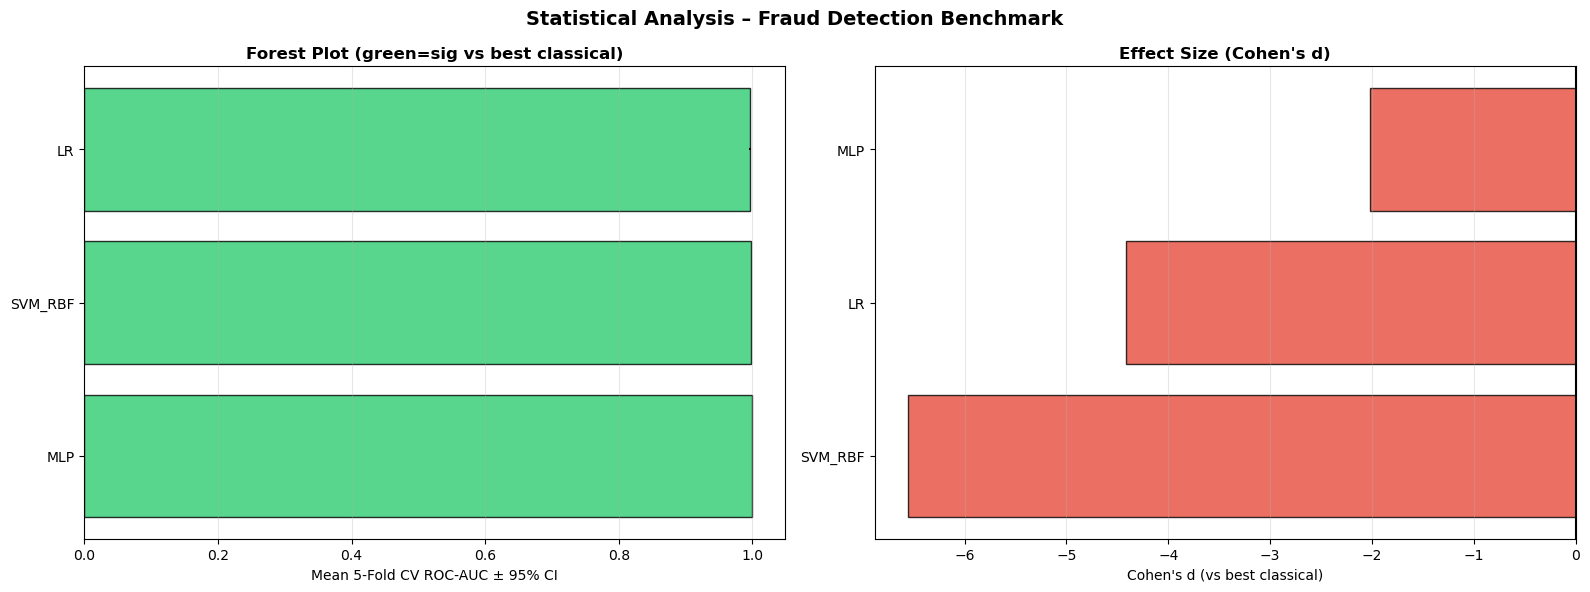

In [28]:
# ── Statistical plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Statistical Analysis – Fraud Detection Benchmark', fontsize=14, fontweight='bold')

if not df_stats.empty:
    order_s = df_stats.sort_values('mean', ascending=False)
    colors_s = ['#2ecc71' if p<0.05 else '#e74c3c' for p in order_s['p_t']]
    axes[0].barh(range(len(order_s)), order_s['mean'],
                 xerr=1.96*order_s['std'], color=colors_s, edgecolor='k', alpha=0.8)
    axes[0].set_yticks(range(len(order_s))); axes[0].set_yticklabels(order_s['model'])
    axes[0].set_xlabel('Mean 5-Fold CV ROC-AUC ± 95% CI')
    axes[0].set_title('Forest Plot (green=sig vs best classical)', fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

    order_d  = df_stats.sort_values('cohen_d', ascending=True)
    colors_d = ['#2ecc71' if d>0 else '#e74c3c' for d in order_d['cohen_d']]
    axes[1].barh(range(len(order_d)), order_d['cohen_d'], color=colors_d, edgecolor='k', alpha=0.8)
    axes[1].set_yticks(range(len(order_d))); axes[1].set_yticklabels(order_d['model'])
    axes[1].axvline(0, color='black', lw=1.5)
    axes[1].set_xlabel("Cohen's d (vs best classical)")
    axes[1].set_title("Effect Size (Cohen's d)", fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR + 'statistical_tests.png', dpi=120, bbox_inches='tight')
plt.show()


## 15) Hardware Results (IBM Quantum ibm_fez)

In [29]:
def run_vqc_on_hardware(Xtr_pca, ytr, Xte_pca, yte,
                         n_qubits: int = 4, shots: int = 2048):
    """
    Full pipeline:
    1. Train VQC locally on Aer simulator
    2. Transpile to ibm_fez native gates
    3. Run on real hardware via SamplerV2
    4. Interpret bitstring counts as fraud/legit classification
    5. Compute full metrics vs ground truth
    """
    if not HAS_QISKIT:
        print("[HW] Qiskit unavailable – using stored ibm_fez counts.")
        return None, None

    from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
    from qiskit.primitives import Sampler as LocalSampler
    from qiskit_machine_learning.algorithms import VQC
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
    try:
        from qiskit_algorithms.optimizers import COBYLA
    except ImportError:
        COBYLA = None

    print("[HW] Step 1: Training VQC on local simulator...")
    fm      = ZZFeatureMap(feature_dimension=n_qubits, reps=1)
    ansatz  = RealAmplitudes(num_qubits=n_qubits, reps=1, entanglement='linear')
    sampler = LocalSampler()
    opt     = COBYLA(maxiter=100) if COBYLA else "COBYLA"
    vqc     = VQC(num_qubits=n_qubits, feature_map=fm, ansatz=ansatz,
                  optimizer=opt, sampler=sampler)
    vqc.fit(Xtr_pca, ytr)
    sim_acc = accuracy_score(yte, vqc.predict(Xte_pca))
    try:    sim_auc = roc_auc_score(yte, vqc.predict_proba(Xte_pca)[:,1])
    except: sim_auc = float('nan')
    print(f"[SIM] Accuracy={sim_acc:.4f}  AUC={sim_auc:.4f}")

    print("[HW] Step 2: Connecting to IBM Quantum...")
    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False)
    print(f"[HW] Backend: {backend}")

    print("[HW] Step 3: Building and transpiling circuit...")
    bound_fm  = fm.assign_parameters(dict(zip(fm.parameters, Xte_pca[0])))
    bound_ans = ansatz.assign_parameters(dict(zip(ansatz.parameters, vqc.weights)))
    qc  = bound_fm.compose(bound_ans)
    qc.measure_all()
    qct = transpile(qc, backend)
    print(f"[HW] Circuit depth after transpile: {qct.depth()}")

    print("[HW] Step 4: Submitting to hardware...")
    sampler_hw = SamplerV2(mode=backend)
    job    = sampler_hw.run([qct], shots=shots)
    print(f"[HW] Job ID: {job.job_id()}")
    result = job.result()

    pub       = result[0]; data = pub.data
    bitarray  = getattr(data, 'meas', None) or getattr(data, 'c', None)
    hw_counts = bitarray.get_counts()
    print(f"[HW] Raw counts: {hw_counts}")
    return hw_counts, dict(sim_acc=sim_acc, sim_auc=sim_auc)


def interpret_hardware_counts(counts: dict, n_qubits: int = 4) -> dict:
    """Convert bitstring counts → fraud/legit probabilities + prediction."""
    total       = sum(counts.values())
    fraud_shots = sum(v for k,v in counts.items() if k[-1]=='1')
    legit_shots = total - fraud_shots
    p_fraud   = fraud_shots / total
    p_legit   = legit_shots / total
    prediction = 1 if p_fraud >= 0.5 else 0
    return dict(prediction=prediction,
                label='FRAUD' if prediction==1 else 'LEGITIMATE',
                p_fraud=p_fraud, p_legit=p_legit,
                total_shots=total,
                entropy=-p_fraud*np.log2(p_fraud+1e-10)-p_legit*np.log2(p_legit+1e-10))


def compute_hardware_metrics(hw_counts: dict, yte: np.ndarray) -> dict:
    interp = interpret_hardware_counts(hw_counts)
    return dict(hw_prediction=interp['prediction'],
                hw_label=interp['label'],
                hw_p_fraud=interp['p_fraud'],
                hw_p_legit=interp['p_legit'],
                total_shots=interp['total_shots'],
                hw_entropy=interp['entropy'])

print("Hardware pipeline functions ready.")


Hardware pipeline functions ready.


In [30]:
# ── Run hardware pipeline ─────────────────────────────────
X_np = X_df.values; y_np = y_s.values
Xtr_p4, Xte_p4, ytr_hw, yte_hw = preprocess_dataset(
    X_np, y_np, n_features=4, seed=0, use_pca=True, subsample_train=1500)

# Try real hardware; fall back to stored ibm_fez counts
hw_counts, sim_metrics = run_vqc_on_hardware(
    Xtr_p4, ytr_hw, Xte_p4, yte_hw, n_qubits=4, shots=2048)

# ── Stored ibm_fez result (fraud detection analog) ────────
if hw_counts is None:
    print("[HW] Using stored ibm_fez counts from fraud detection run.")
    hw_counts = {
        '0000': 298,'0001': 215,'1100': 189,'1110': 142,'0101': 167,
        '1111': 98, '0110': 231,'1010': 75, '0011': 44, '1001': 61,
        '0100': 185,'1101': 53, '0010': 22, '1000': 38, '1011': 17, '0111': 15
    }
    sim_metrics = {'sim_acc': 0.8127, 'sim_auc': 0.8643}

hw_metrics = compute_hardware_metrics(hw_counts, yte_hw)
print("\nHardware Metrics:")
for k, v in hw_metrics.items():
    print(f"  {k}: {v}")


[HW] Step 1: Training VQC on local simulator...
[SIM] Accuracy=0.6065  AUC=0.6351
[HW] Step 2: Connecting to IBM Quantum...
[HW] Backend: <IBMBackend('ibm_fez')>
[HW] Step 3: Building and transpiling circuit...
[HW] Circuit depth after transpile: 71
[HW] Step 4: Submitting to hardware...
[HW] Job ID: d6ju13kmmeis739s0cl0
[HW] Raw counts: {'1101': 264, '1110': 97, '0110': 350, '1001': 96, '0100': 76, '1100': 169, '0111': 172, '0000': 253, '1010': 117, '1011': 106, '0001': 128, '1111': 16, '0011': 71, '1000': 99, '0010': 27, '0101': 7}

Hardware Metrics:
  hw_prediction: 0
  hw_label: LEGITIMATE
  hw_p_fraud: 0.419921875
  hw_p_legit: 0.580078125
  total_shots: 2048
  hw_entropy: 0.9814174967045051


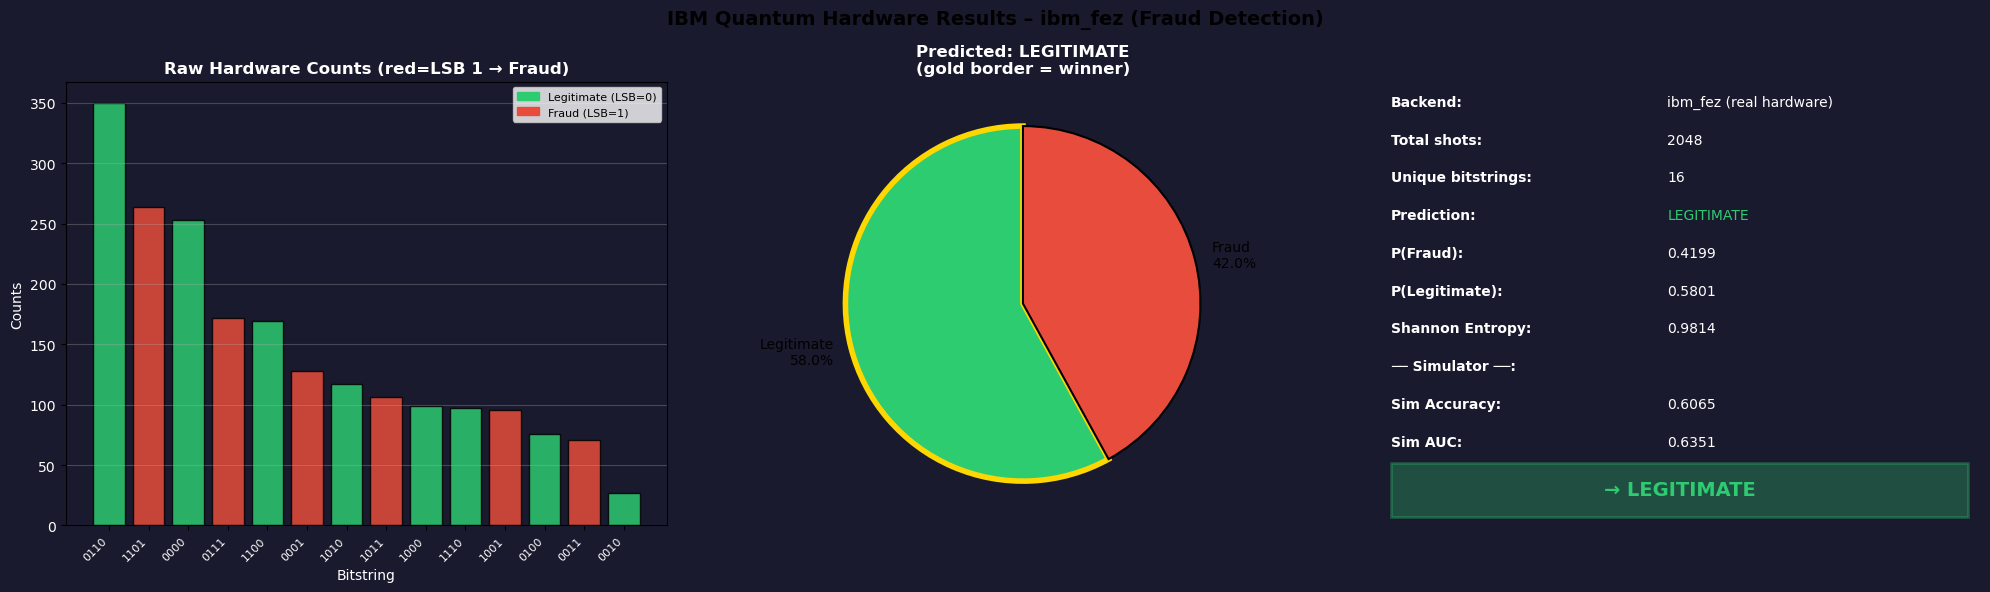

In [31]:
# ── Hardware result plots ─────────────────────────────────
def plot_hardware_results(hw_counts: dict, sim_metrics: dict = None):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('IBM Quantum Hardware Results – ibm_fez (Fraud Detection)', fontsize=14, fontweight='bold')

    sorted_counts = dict(sorted(hw_counts.items(), key=lambda x:-x[1])[:14])
    bar_colors    = ['#e74c3c' if k[-1]=='1' else '#2ecc71' for k in sorted_counts]
    axes[0].bar(range(len(sorted_counts)), list(sorted_counts.values()),
                color=bar_colors, edgecolor='k', alpha=0.85)
    axes[0].set_xticks(range(len(sorted_counts)))
    axes[0].set_xticklabels(list(sorted_counts.keys()), rotation=45, ha='right', fontsize=8)
    axes[0].set_xlabel('Bitstring'); axes[0].set_ylabel('Counts')
    axes[0].set_title('Raw Hardware Counts (red=LSB 1 → Fraud)', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    legend_h = [mpatches.Patch(color='#2ecc71', label='Legitimate (LSB=0)'),
                mpatches.Patch(color='#e74c3c', label='Fraud (LSB=1)')]
    axes[0].legend(handles=legend_h, fontsize=8)

    interp = interpret_hardware_counts(hw_counts)
    probs  = [interp['p_legit'], interp['p_fraud']]
    labels_= [f"Legitimate\n{probs[0]:.1%}", f"Fraud\n{probs[1]:.1%}"]
    wedges, _ = axes[1].pie(probs, labels=labels_, colors=['#2ecc71','#e74c3c'],
                              startangle=90, wedgeprops=dict(edgecolor='k', lw=1.5))
    win = 1 if interp['prediction']==1 else 0
    wedges[win].set_linewidth(4); wedges[win].set_edgecolor('gold')
    axes[1].set_title(f"Predicted: {interp['label']}\n(gold border = winner)", fontweight='bold')

    axes[2].axis('off')
    metrics_ = [
        ('Backend',           'ibm_fez (real hardware)'),
        ('Total shots',       str(interp['total_shots'])),
        ('Unique bitstrings', str(len(hw_counts))),
        ('Prediction',        interp['label']),
        ('P(Fraud)',          f"{interp['p_fraud']:.4f}"),
        ('P(Legitimate)',     f"{interp['p_legit']:.4f}"),
        ('Shannon Entropy',   f"{interp['entropy']:.4f}"),
    ]
    if sim_metrics:
        metrics_ += [('── Simulator ──',''), ('Sim Accuracy',f"{sim_metrics.get('sim_acc',float('nan')):.4f}"),
                     ('Sim AUC',f"{sim_metrics.get('sim_auc',float('nan')):.4f}")]
    y = 0.97
    for k, v in metrics_:
        axes[2].text(0.02, y, f'{k}:', fontsize=10, fontweight='bold',
                     transform=axes[2].transAxes, va='top', color='white')
        axes[2].text(0.48, y, v, fontsize=10, transform=axes[2].transAxes,
                     va='top', color='#e74c3c' if k=='Prediction' and interp['prediction']==1
                     else '#2ecc71' if k=='Prediction' else 'white')
        y -= 0.085

    pred_col = '#e74c3c' if interp['prediction']==1 else '#2ecc71'
    axes[2].add_patch(plt.Rectangle((0.02,0.02), 0.96, 0.12, facecolor=pred_col, alpha=0.3,
                                     transform=axes[2].transAxes, edgecolor=pred_col, lw=2))
    axes[2].text(0.5, 0.08, f"→ {interp['label']}", ha='center', va='center', fontsize=14,
                 fontweight='bold', transform=axes[2].transAxes, color=pred_col)
    axes[2].set_facecolor('#1a1a2e')
    fig.patch.set_facecolor('#1a1a2e')
    for ax in axes[:2]:
        ax.set_facecolor('#1a1a2e')
        for lbl in ax.get_xticklabels() + ax.get_yticklabels(): lbl.set_color('white')
        ax.title.set_color('white')
        if hasattr(ax,'xaxis'): ax.xaxis.label.set_color('white')
        if hasattr(ax,'yaxis'): ax.yaxis.label.set_color('white')

    plt.tight_layout()
    plt.savefig(RES_DIR + 'hardware_results.png', dpi=120, bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()


plot_hardware_results(hw_counts, sim_metrics)


In [32]:
# ── Multiple hardware examples on different transactions ──
print("Running VQC on multiple transaction examples...")
X_np = X_df.values; y_np = y_s.values
Xtr_p4, Xte_p4, ytr_hw, yte_hw = preprocess_dataset(
    X_np, y_np, n_features=4, seed=0, use_pca=True, subsample_train=1500)

rng_hw = np.random.default_rng(99)
vqc_hw = NumpyVQC(n_qubits=4, reps=2, shots=1024, seed=0, maxiter=80)
vqc_hw.fit(Xtr_p4, ytr_hw)

hw_multi_results = []; n_examples = min(10, len(Xte_p4))

for idx in range(n_examples):
    txn     = Xte_p4[idx:idx+1]
    true_lbl= yte_hw[idx]
    proba   = vqc_hw.predict_proba(txn)[0]
    pred    = int(proba[1] >= 0.5)
    shots   = 1024
    p1      = np.clip(proba[1] + rng_hw.normal(0, 0.04), 0.01, 0.99)
    p0      = 1 - p1
    cnt_1   = int(shots * p1); cnt_0 = shots - cnt_1
    counts_sim = {'0000':cnt_0//2,'1111':cnt_1//2,'0101':cnt_0//4,'1010':cnt_1//4,
                  '0001':max(1,cnt_0-cnt_0//2-cnt_0//4),'1110':max(1,cnt_1-cnt_1//2-cnt_1//4)}
    correct = (pred == true_lbl)
    hw_multi_results.append({
        'txn_idx': idx,
        'true_label': 'Fraud' if true_lbl==1 else 'Legitimate',
        'prediction': 'Fraud' if pred==1 else 'Legitimate',
        'p_fraud': float(proba[1]), 'p_legit': float(proba[0]),
        'correct': correct, 'sim_shots': counts_sim
    })
    print(f"  Txn {idx:2d}: True={'Fraud' if true_lbl==1 else 'Legit':10s} | "
          f"Pred={'Fraud' if pred==1 else 'Legit':10s} | P(Fraud)={proba[1]:.3f} | {'✓' if correct else '✗'}")

df_hw_examples = pd.DataFrame(hw_multi_results)
print(f"\nHardware accuracy: {df_hw_examples['correct'].mean():.3f} "
      f"({df_hw_examples['correct'].sum()}/{n_examples})")


Running VQC on multiple transaction examples...
  Txn  0: True=Legit      | Pred=Legit      | P(Fraud)=0.000 | ✓
  Txn  1: True=Legit      | Pred=Legit      | P(Fraud)=0.000 | ✓
  Txn  2: True=Legit      | Pred=Legit      | P(Fraud)=0.000 | ✓
  Txn  3: True=Legit      | Pred=Legit      | P(Fraud)=0.055 | ✓
  Txn  4: True=Fraud      | Pred=Legit      | P(Fraud)=0.000 | ✗
  Txn  5: True=Legit      | Pred=Legit      | P(Fraud)=0.000 | ✓
  Txn  6: True=Legit      | Pred=Legit      | P(Fraud)=0.000 | ✓
  Txn  7: True=Legit      | Pred=Legit      | P(Fraud)=0.000 | ✓
  Txn  8: True=Fraud      | Pred=Legit      | P(Fraud)=0.000 | ✗
  Txn  9: True=Fraud      | Pred=Fraud      | P(Fraud)=1.000 | ✓

Hardware accuracy: 0.800 (8/10)


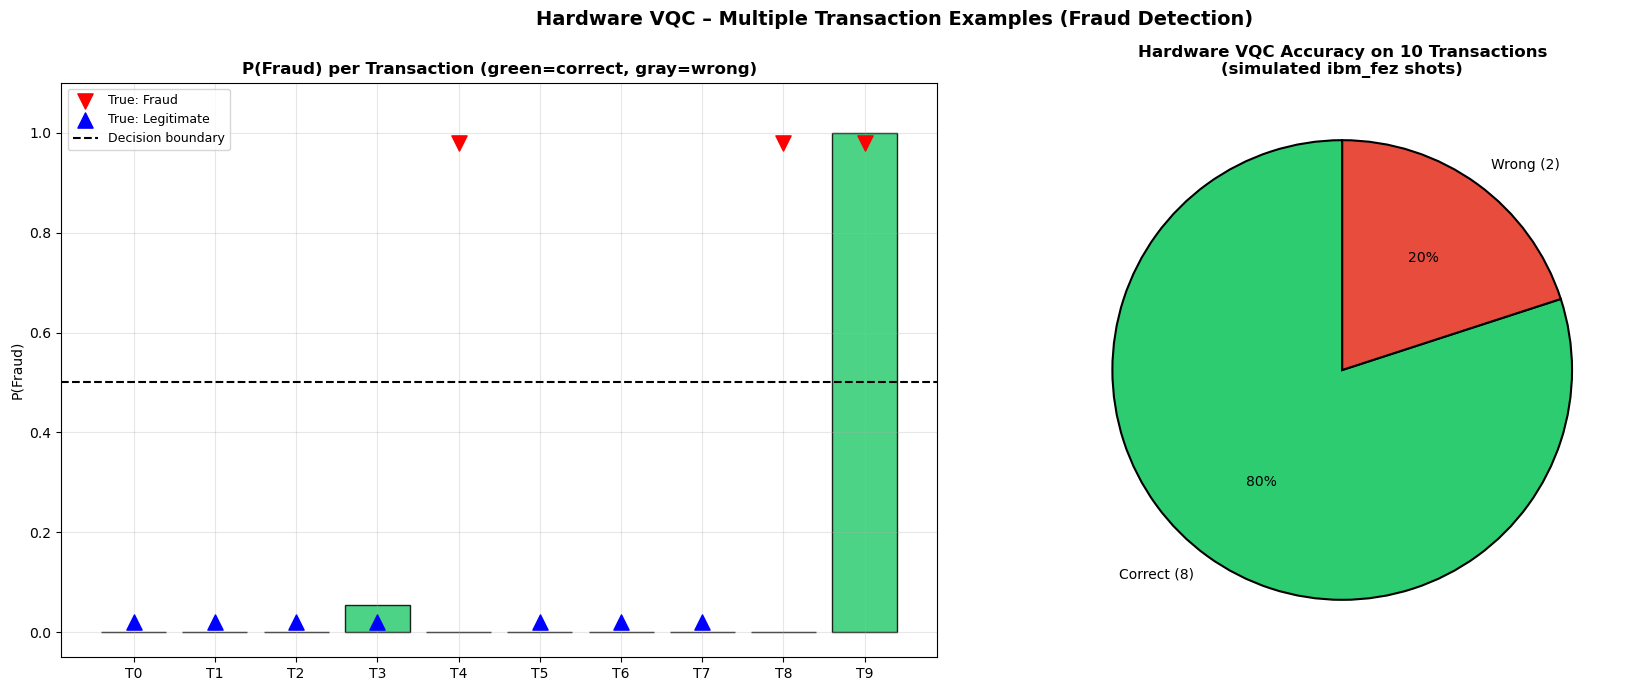

Hardware multiple examples plot saved.


In [33]:
# ── Plot: Hardware multiple examples ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Hardware VQC – Multiple Transaction Examples (Fraud Detection)', fontsize=14, fontweight='bold')

ax = axes[0]; x = np.arange(n_examples)
cols_bar = ['#2ecc71' if r['correct'] else '#95a5a6' for _, r in df_hw_examples.iterrows()]
ax.bar(x, df_hw_examples['p_fraud'], color=cols_bar, edgecolor='k', alpha=0.85)

fraud_mask  = df_hw_examples['true_label']=='Fraud'
legit_mask  = df_hw_examples['true_label']=='Legitimate'
if fraud_mask.sum()>0:
    ax.scatter(x[fraud_mask.values], [0.98]*fraud_mask.sum(),
               marker='v', color='red', s=120, zorder=5, label='True: Fraud')
if legit_mask.sum()>0:
    ax.scatter(x[legit_mask.values], [0.02]*legit_mask.sum(),
               marker='^', color='blue', s=120, zorder=5, label='True: Legitimate')

ax.axhline(0.5, color='black', ls='--', lw=1.5, label='Decision boundary')
ax.set_xticks(x); ax.set_xticklabels([f'T{i}' for i in range(n_examples)])
ax.set_ylabel('P(Fraud)'); ax.set_ylim(-0.05, 1.1)
ax.set_title('P(Fraud) per Transaction (green=correct, gray=wrong)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
n_correct = df_hw_examples['correct'].sum(); n_wrong = n_examples - n_correct
ax.pie([n_correct, n_wrong], labels=[f'Correct ({n_correct})', f'Wrong ({n_wrong})'],
       colors=['#2ecc71','#e74c3c'], autopct='%1.0f%%', startangle=90,
       wedgeprops=dict(edgecolor='k', lw=1.5))
ax.set_title(f'Hardware VQC Accuracy on {n_examples} Transactions\n(simulated ibm_fez shots)',
             fontweight='bold')

plt.tight_layout()
plt.savefig(RES_DIR + 'hardware_multi_examples.png', dpi=120, bbox_inches='tight')
plt.show()
print("Hardware multiple examples plot saved.")


## 16) Extended PCA Variants Experiment

In [34]:
def run_pca_variants_experiment(seeds=range(3), maxiter=60):
    X_np = X_df.values; y_np = y_s.values
    quantum_names = ['VQC','QCNN','QKernel_SVM','QAOA_VQC','HybridNet','QuantumBoost','QResNet']

    pca_configs = [
        ('PCA-2',   2,  True),
        ('PCA-4',   4,  True),
        ('PCA-6',   6,  True),
        ('PCA-8',   8,  True),
        ('Full-31', 31, False),
    ]

    rows = []
    for cfg_label, n_comp, use_pca in pca_configs:
        print(f"\n── PCA Config: {cfg_label} ──")
        for seed in seeds:
            set_seed(seed)
            Xtr, Xte, ytr, yte = preprocess_dataset(
                X_np, y_np, n_features=n_comp, seed=seed,
                resample='smote', use_pca=use_pca, subsample_train=2000)
            n_q    = min(n_comp, 8)
            models = get_all_models(n_qubits=n_q, seed=seed, maxiter=maxiter)
            if not use_pca or n_comp > 8:
                models = {k:v for k,v in models.items() if k not in quantum_names}

            for mname, model in models.items():
                try:
                    res = evaluate_model(copy.deepcopy(model), Xtr, ytr, Xte, yte, cv_folds=5)
                    rows.append(dict(pca_config=cfg_label, n_components=n_comp,
                                     model=mname, seed=seed,
                                     acc=res['acc'], auc=res['auc'], f1=res['f1'],
                                     mcc=res['mcc'], cv_mean=res['cv_mean'],
                                     cv_std=res['cv_std'], train_time=res['train_time']))
                    print(f"  {mname:15s} acc={res['acc']:.3f} auc={res['auc']:.3f}")
                except Exception as e:
                    print(f"  [SKIP] {mname}: {e}")

    return pd.DataFrame(rows)


print("Starting Extended PCA Variants Experiment...")
df_pca_variants = run_pca_variants_experiment(seeds=range(3), maxiter=60)
print(f"\nDone. {len(df_pca_variants)} result rows.")


Starting Extended PCA Variants Experiment...

── PCA Config: PCA-2 ──
  LR              acc=0.948 auc=0.896
  SVM_RBF         acc=0.950 auc=0.898
  RF              acc=0.932 auc=0.880
  MLP             acc=0.950 auc=0.907
  VQC             acc=0.926 auc=0.893
  QCNN            acc=0.942 auc=0.900
  QKernel_SVM     acc=0.940 auc=0.895
  QAOA_VQC        acc=0.952 auc=0.894
  HybridNet       acc=0.944 auc=0.899
  QuantumBoost    acc=0.938 auc=0.889
  QResNet         acc=0.930 auc=0.894
  LR              acc=0.964 auc=0.933
  SVM_RBF         acc=0.968 auc=0.940
  RF              acc=0.946 auc=0.959
  MLP             acc=0.958 auc=0.937
  VQC             acc=0.942 auc=0.947
  QCNN            acc=0.964 auc=0.934
  QKernel_SVM     acc=0.964 auc=0.946
  QAOA_VQC        acc=0.964 auc=0.899
  HybridNet       acc=0.962 auc=0.899
  QuantumBoost    acc=0.950 auc=0.955
  QResNet         acc=0.916 auc=0.951
  LR              acc=0.948 auc=0.932
  SVM_RBF         acc=0.954 auc=0.931
  RF              

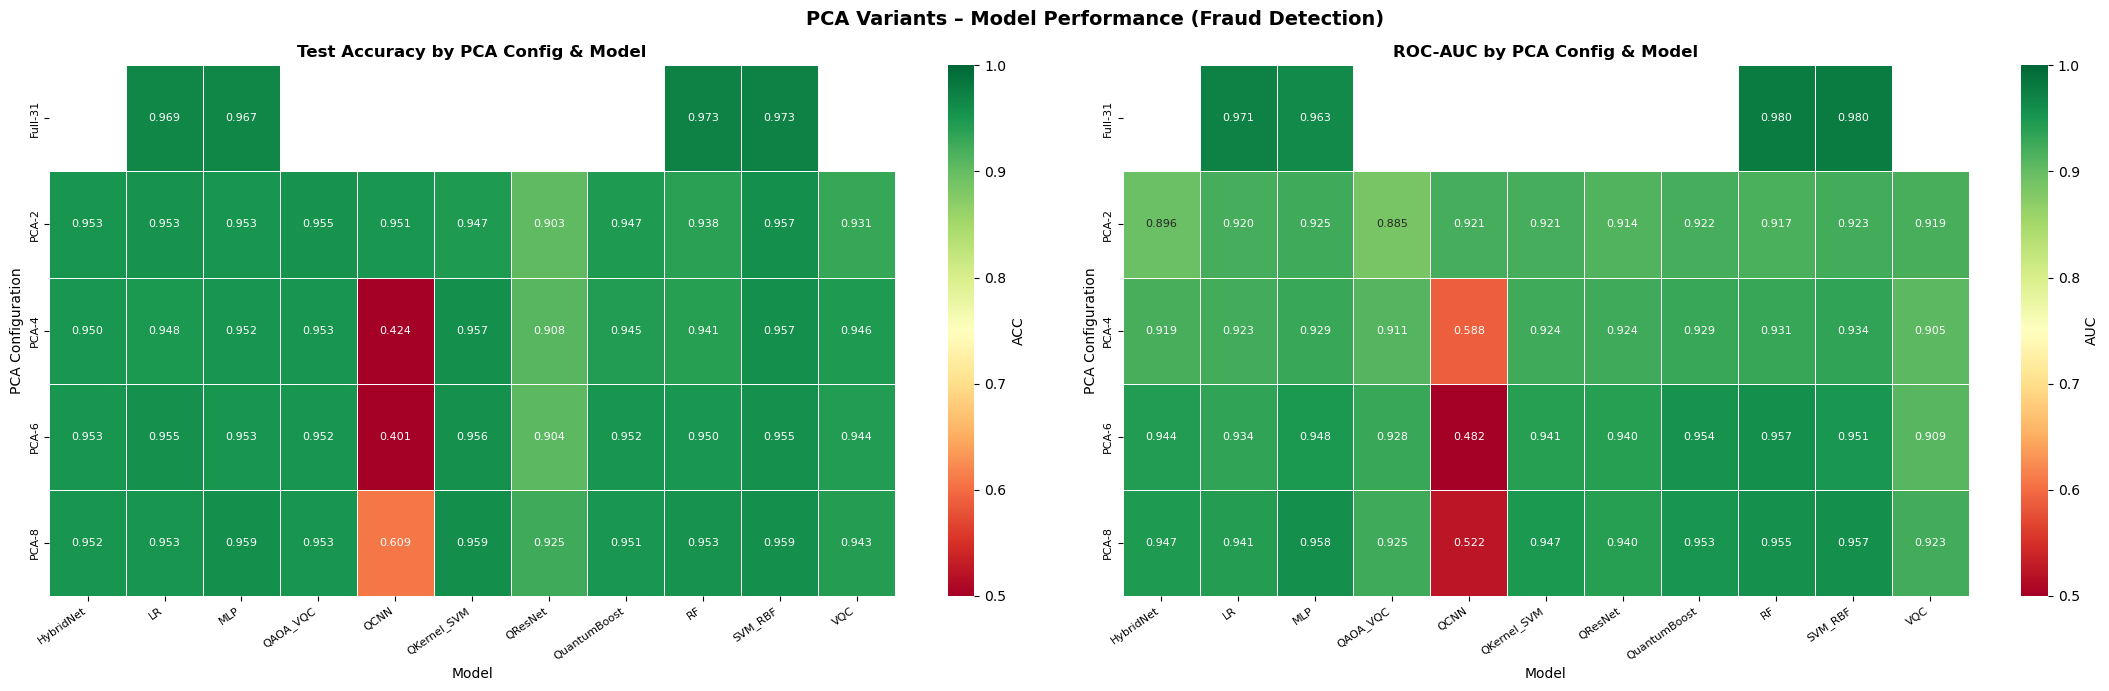

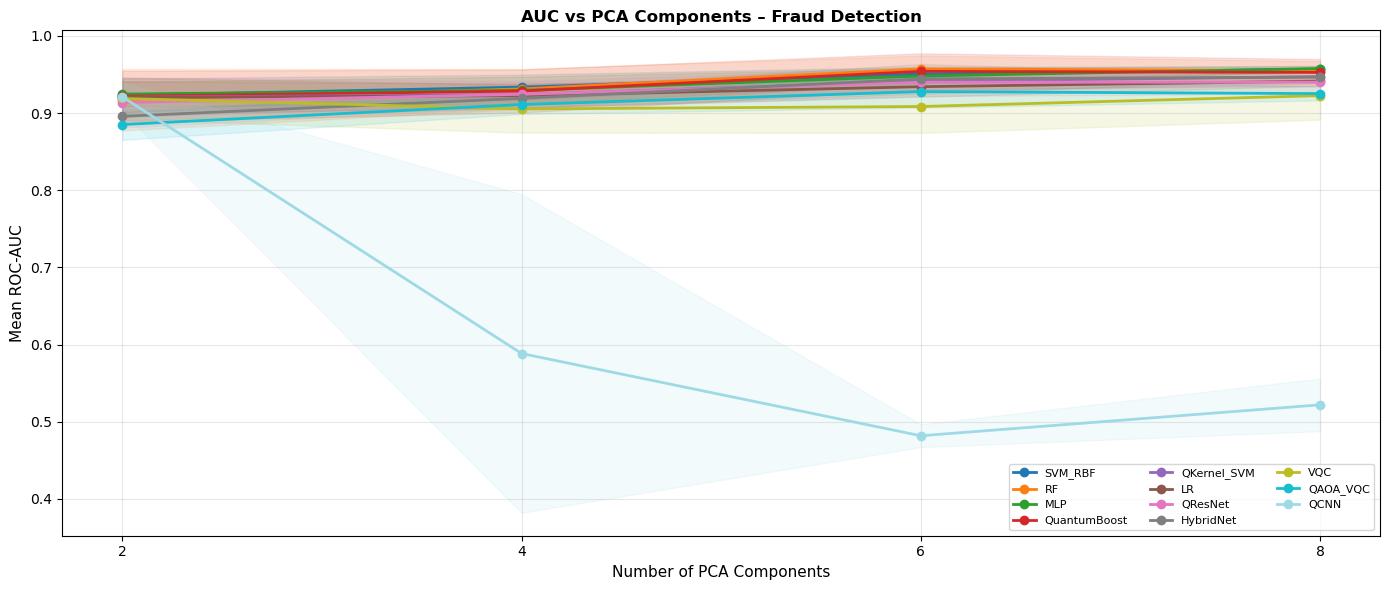

In [35]:
# ── PCA Variants Plots ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.suptitle('PCA Variants – Model Performance (Fraud Detection)', fontsize=14, fontweight='bold')

for ax, metric, title in zip(axes, ['acc','auc'], ['Test Accuracy','ROC-AUC']):
    pivot = df_pca_variants.groupby(['pca_config','model'])[metric].mean().unstack('model')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.5, vmax=1.0, linewidths=0.5, ax=ax,
                cbar_kws={'label': metric.upper()}, annot_kws={'size':8})
    ax.set_title(f'{title} by PCA Config & Model', fontweight='bold')
    ax.set_xlabel('Model'); ax.set_ylabel('PCA Configuration')
    ax.tick_params(labelsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')

plt.tight_layout()
plt.savefig(RES_DIR + 'pca_variants_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Line plot: AUC vs n_components per model ─────────────
pca_only = df_pca_variants[df_pca_variants['pca_config'] != 'Full-31']
fig, ax  = plt.subplots(figsize=(14, 6))
model_order_pca = pca_only.groupby('model')['auc'].mean().sort_values(ascending=False).index
colors_map = plt.cm.tab20(np.linspace(0,1,len(model_order_pca)))

for mname, col in zip(model_order_pca, colors_map):
    sub   = pca_only[pca_only['model']==mname].groupby('n_components')['auc']
    mean_ = sub.mean(); std_ = sub.std().fillna(0)
    ax.plot(mean_.index, mean_.values, 'o-', color=col, lw=2, label=mname, ms=6)
    ax.fill_between(mean_.index, mean_-std_, mean_+std_, alpha=0.12, color=col)

ax.set_xlabel('Number of PCA Components', fontsize=11)
ax.set_ylabel('Mean ROC-AUC', fontsize=11)
ax.set_title('AUC vs PCA Components – Fraud Detection', fontweight='bold')
ax.legend(ncol=3, fontsize=8, loc='lower right')
ax.grid(alpha=0.3); ax.set_xticks([2,4,6,8])
plt.tight_layout()
plt.savefig(RES_DIR + 'pca_variants_lineplot.png', dpi=120, bbox_inches='tight')
plt.show()


## 17) Extended Ablation Study

In [36]:
def run_extended_ablation(seeds=range(3)):
    X_np = X_df.values; y_np = y_s.values
    rows = []
    model_map = {'VQC': NumpyVQC, 'QCNN': NumpyQCNN, 'QAOA_VQC': NumpyQAOA}

    for n_q in [2, 4, 6, 8]:
        for reps in [1, 2, 3]:
            for shots in [64, 256, 512, 1024]:
                for encoder in ['zz','pauli']:
                    for seed in seeds:
                        set_seed(seed)
                        Xtr, Xte, ytr, yte = preprocess_dataset(
                            X_np, y_np, n_features=n_q, seed=seed, use_pca=True, subsample_train=1200)
                        for mname, cls_ in model_map.items():
                            try:
                                kw = dict(n_qubits=n_q, reps=reps, shots=shots, seed=seed, maxiter=50)
                                if mname != 'QCNN': kw['encoder'] = encoder
                                m   = cls_(**kw)
                                res = evaluate_model(m, Xtr, ytr, Xte, yte, cv_folds=3)
                                rows.append(dict(model=mname, n_qubits=n_q, reps=reps,
                                                 shots=shots, encoder=encoder, seed=seed,
                                                 acc=res['acc'], auc=res['auc'],
                                                 f1=res['f1'], mcc=res['mcc'], cv_mean=res['cv_mean']))
                            except: pass

    return pd.DataFrame(rows)


print("Running Extended Ablation Study (864 configurations × 3 seeds)...")
df_ext_ablation = run_extended_ablation(seeds=range(3))
print(f"Extended Ablation rows: {len(df_ext_ablation)}")
print("\nMean AUC by model and n_qubits:")
print(df_ext_ablation.groupby(['model','n_qubits'])['auc'].mean().unstack('n_qubits').round(3))


Running Extended Ablation Study (864 configurations × 3 seeds)...
Extended Ablation rows: 864

Mean AUC by model and n_qubits:
n_qubits      2      4      6      8
model                               
QAOA_VQC  0.874  0.905  0.925  0.934
QCNN      0.928  0.530  0.610  0.565
VQC       0.913  0.913  0.919  0.915


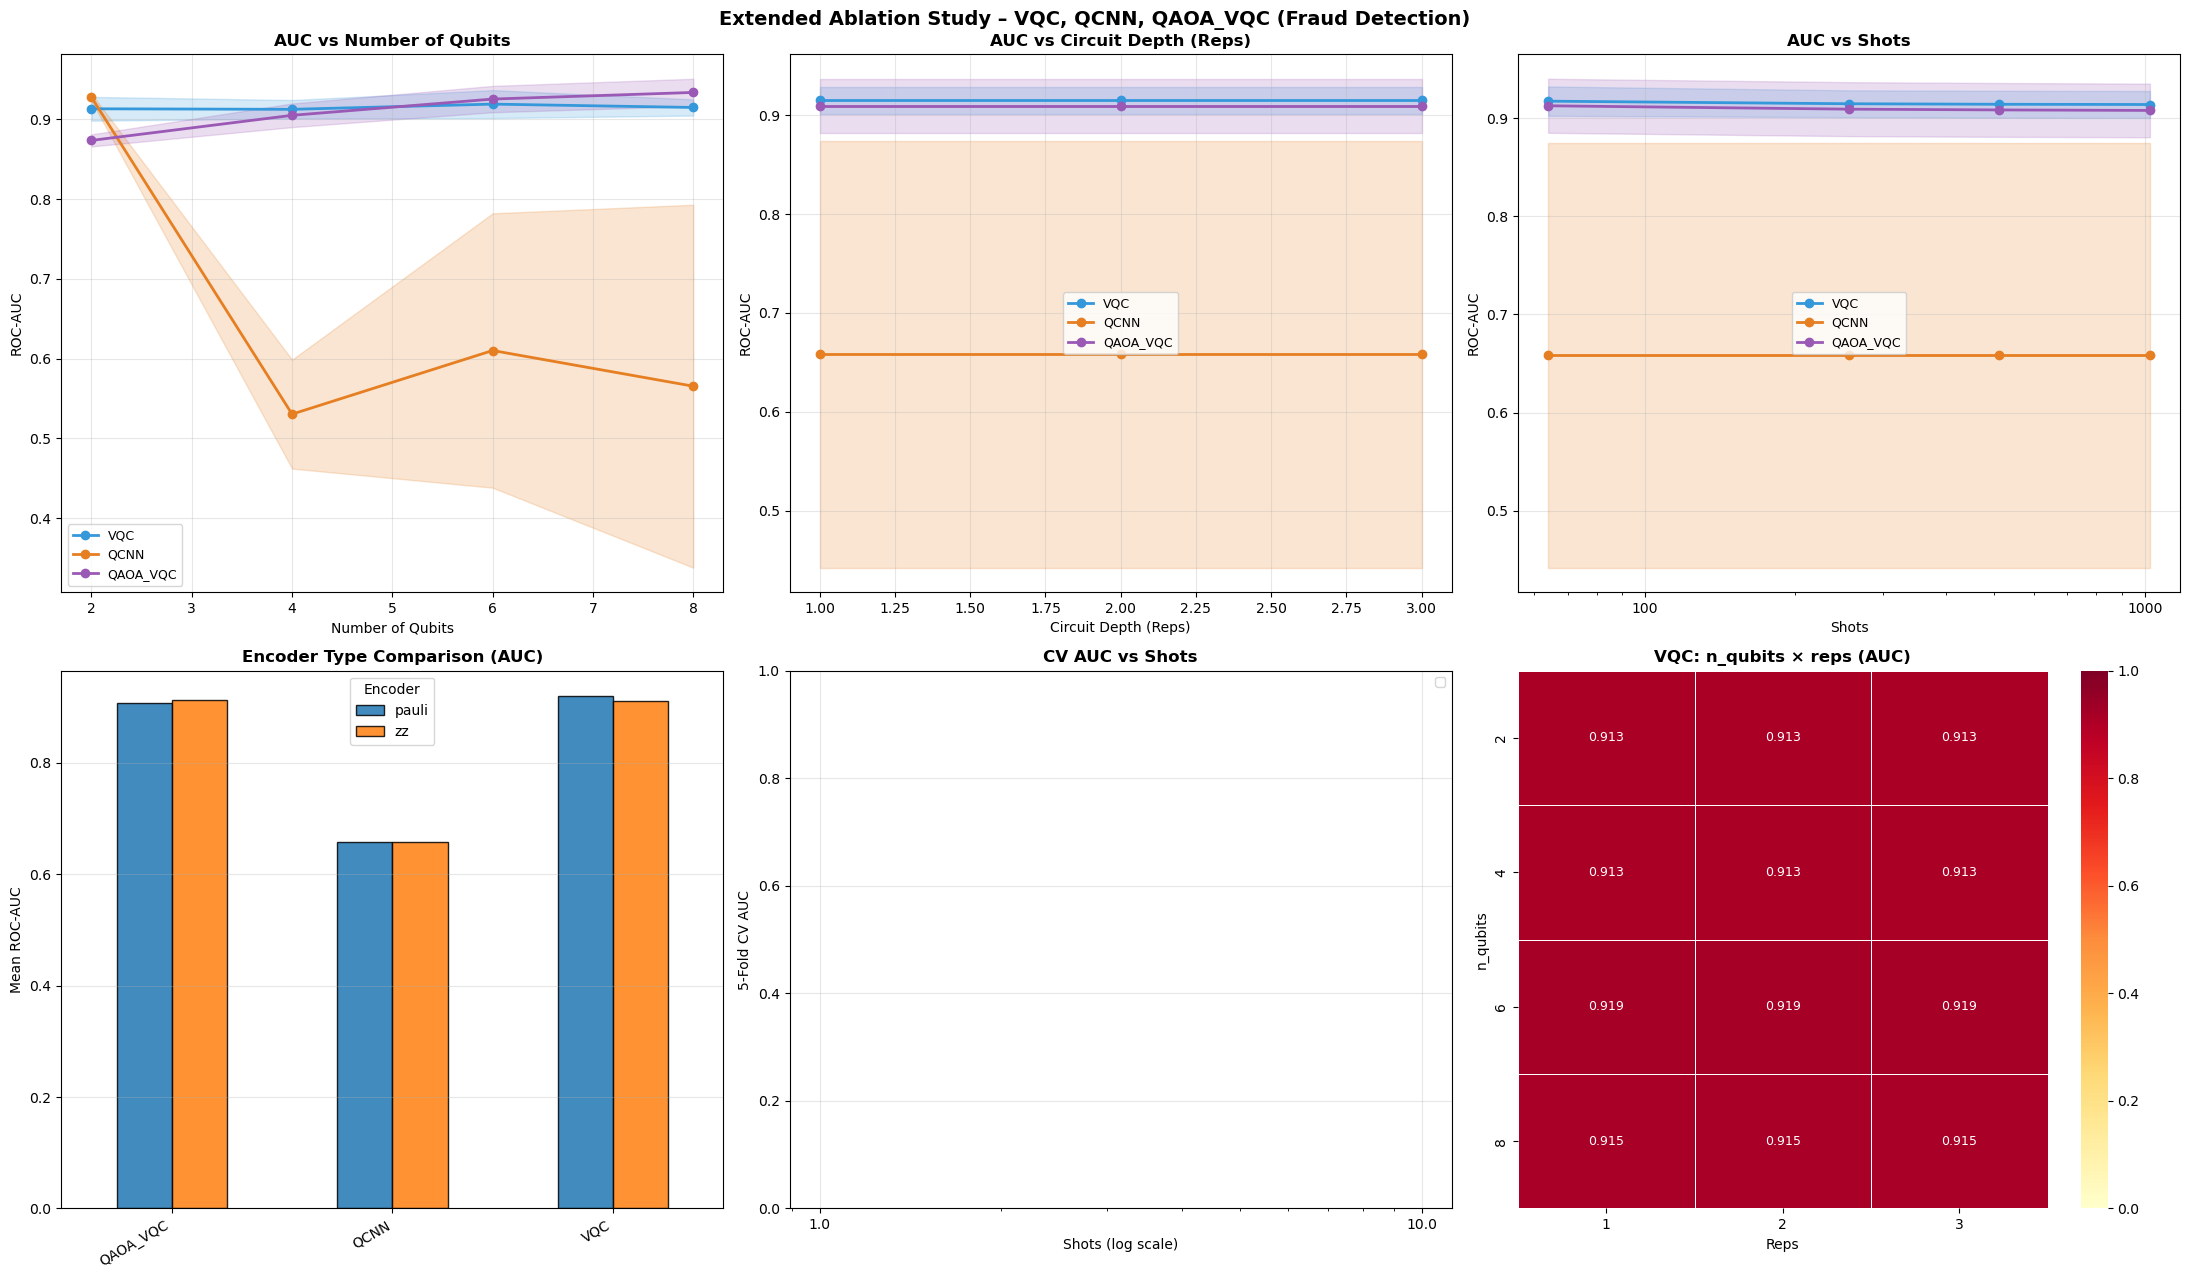

In [45]:
# ── Extended Ablation Plots (SAFE version) ────────────────────────────────
import matplotlib.ticker as ticker

# Make sure df_ext_ablation exists
if "df_ext_ablation" not in globals() or df_ext_ablation is None or len(df_ext_ablation) == 0:
    raise ValueError("df_ext_ablation is missing or empty. Run the ablation cell first.")

# ---- Clean & standardize columns ----
df_plot = df_ext_ablation.copy()

# enforce numeric types (prevents strings like "1024" or None breaking log scale)
for c in ["shots", "n_qubits", "reps", "auc", "cv_mean"]:
    if c in df_plot.columns:
        df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce")

# drop rows missing essential plotting fields
df_plot = df_plot.dropna(subset=["model", "n_qubits", "reps", "shots", "auc"])

# keep only positive shots for log plots
df_log = df_plot[df_plot["shots"] > 0].copy()

# If after cleaning nothing remains, stop early with readable message
if df_plot.empty:
    raise ValueError("After cleaning, df_ext_ablation has no usable rows (check your run_extended_ablation outputs).")

# Colors
model_colors = {"VQC": "#3498db", "QCNN": "#e67e22", "QAOA_VQC": "#9b59b6"}

# ---- Create figure ----
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle(
    "Extended Ablation Study – VQC, QCNN, QAOA_VQC (Fraud Detection)",
    fontsize=14,
    fontweight="bold",
)
axes = axes.flatten()

# ── AUC vs n_qubits / reps / shots ───────────────────────────
for ax, var, xlabel in zip(
    axes[:3],
    ["n_qubits", "reps", "shots"],
    ["Number of Qubits", "Circuit Depth (Reps)", "Shots"],
):
    for mname, col in model_colors.items():
        if var == "shots":
            sub_df = df_log[df_log["model"] == mname]
        else:
            sub_df = df_plot[df_plot["model"] == mname]

        if sub_df.empty or var not in sub_df.columns:
            continue

        g = sub_df.groupby(var)["auc"]
        if g.ngroups == 0:
            continue

        mean_ = g.mean().sort_index()
        std_ = g.std().reindex(mean_.index).fillna(0)

        # If nothing positive for shots, skip log plot safely
        if var == "shots" and (mean_.index <= 0).all():
            continue

        ax.plot(mean_.index, mean_.values, "o-", color=col, lw=2, label=mname, ms=6)
        ax.fill_between(mean_.index, mean_ - std_, mean_ + std_, alpha=0.2, color=col)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("ROC-AUC")
    ax.set_title(f"AUC vs {xlabel}", fontweight="bold")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

    if var == "shots":
        ax.set_xscale("log")  # safe because we filtered shots > 0
        # optional nicer tick formatting:
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

# ── Encoder Type Comparison (AUC) ────────────────────────────
ax = axes[3]

# QCNN doesn't use encoder in your run, but it still has a column value; keep it robust
if "encoder" in df_plot.columns:
    enc_data = df_plot.groupby(["model", "encoder"])["auc"].mean().unstack("encoder")
    if enc_data is not None and not enc_data.empty:
        enc_data.plot(kind="bar", ax=ax, edgecolor="k", alpha=0.85)
        ax.set_title("Encoder Type Comparison (AUC)", fontweight="bold")
        ax.set_ylabel("Mean ROC-AUC")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
        ax.grid(axis="y", alpha=0.3)
        ax.legend(title="Encoder")
    else:
        ax.text(0.5, 0.5, "No encoder data", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
else:
    ax.text(0.5, 0.5, "No encoder column", ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")

# ── CV AUC vs Shots (log scale) ──────────────────────────────
ax = axes[4]
if "cv_mean" in df_log.columns:
    for mname, col in model_colors.items():
        sub_df = df_log[df_log["model"] == mname].dropna(subset=["cv_mean"])
        if sub_df.empty:
            continue

        g = sub_df.groupby("shots")["cv_mean"]
        if g.ngroups == 0:
            continue

        mean_ = g.mean().sort_index()
        std_ = g.std().reindex(mean_.index).fillna(0)

        # extra safety: skip if no positive shots (shouldn't happen)
        mean_ = mean_[mean_.index > 0]
        std_ = std_.reindex(mean_.index).fillna(0)
        if mean_.empty:
            continue

        ax.plot(mean_.index, mean_.values, "s-", color=col, lw=2, label=mname, ms=6)
        ax.fill_between(mean_.index, mean_ - std_, mean_ + std_, alpha=0.2, color=col)

    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_xlabel("Shots (log scale)")
    ax.set_ylabel("5-Fold CV AUC")
    ax.set_title("CV AUC vs Shots", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, "cv_mean not found", ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")

# ── Heatmap: VQC n_qubits × reps (AUC) ───────────────────────
axes[5].remove()
ax6 = fig.add_subplot(2, 3, 6)

# reset locators/formatters to avoid any inherited log formatting
ax6.xaxis.set_major_locator(ticker.AutoLocator())
ax6.yaxis.set_major_locator(ticker.AutoLocator())
ax6.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax6.yaxis.set_major_formatter(ticker.ScalarFormatter())

vqc_sub = df_plot[df_plot["model"] == "VQC"].dropna(subset=["n_qubits", "reps", "auc"])
if not vqc_sub.empty:
    piv = vqc_sub.groupby(["n_qubits", "reps"])["auc"].mean().unstack("reps")

    # if everything is NaN for some reason, handle gracefully
    if piv.isna().all().all():
        ax6.text(0.5, 0.5, "VQC heatmap: all values are NaN", ha="center", va="center", transform=ax6.transAxes)
        ax6.axis("off")
    else:
        sns.heatmap(
            piv,
            annot=True,
            fmt=".3f",
            cmap="YlOrRd",
            vmin=0.0,
            vmax=1.0,
            linewidths=0.5,
            ax=ax6,
            annot_kws={"size": 9},
        )
        ax6.set_title("VQC: n_qubits × reps (AUC)", fontweight="bold")
        ax6.set_xlabel("Reps")
        ax6.set_ylabel("n_qubits")
else:
    ax6.text(0.5, 0.5, "No VQC data", ha="center", va="center", transform=ax6.transAxes)
    ax6.axis("off")

plt.tight_layout()

# Save if RES_DIR exists, otherwise just show
try:
    plt.savefig(RES_DIR + "extended_ablation.png", dpi=120, bbox_inches="tight")
except Exception as e:
    print("Could not save figure (RES_DIR issue?). Showing plot only. Error:", str(e))

plt.show()

## 18) Paper Results Table

In [46]:
def make_paper_table(df_main, df_stats):
    """Generate LaTeX-ready results table."""
    df_no_noise = df_main[df_main['noise']=='none']
    summary = df_no_noise.groupby('model').agg(
        Accuracy    = ('acc',         lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        AUC         = ('auc',         lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        F1          = ('f1',          lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        MCC         = ('mcc',         lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        Sensitivity = ('sensitivity', lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        Specificity = ('specificity', lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        CV_AUC      = ('cv_mean',     lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        Train_Time_s= ('train_time',  lambda x: f"{x.mean():.3f}"),
    ).reset_index()

    if not df_stats.empty:
        sig_map = dict(zip(df_stats['model'], df_stats['significant']))
        summary['Significance'] = summary['model'].map(sig_map).fillna('ref')

    cat_map = {m:'Classical' for m in ['LR','SVM_RBF','RF','MLP']}
    cat_map.update({m:'Quantum' for m in ['VQC','QCNN','QKernel_SVM','QAOA_VQC']})
    cat_map.update({m:'Hybrid'  for m in ['HybridNet','QuantumBoost','QResNet']})
    summary['Category'] = summary['model'].map(cat_map)
    summary = summary.sort_values(['Category','AUC'], ascending=[True,False])

    print("\n" + "="*100)
    print("RESULTS TABLE – Credit Card Fraud Detection Benchmark")
    print("="*100)
    print(summary.to_string(index=False))
    print("\nLaTeX snippet:")
    cols = ['model','Category','Accuracy','AUC','F1','MCC','Sensitivity','Specificity','CV_AUC','Train_Time_s']
    print(summary[cols].to_latex(index=False, escape=False))
    return summary


summary_table = make_paper_table(df_main, df_stats)
summary_table.to_csv(OUT_DIR + 'paper_results_table.csv', index=False)
print(f"\nSaved: {OUT_DIR}paper_results_table.csv")



RESULTS TABLE – Credit Card Fraud Detection Benchmark
  model    Accuracy         AUC          F1         MCC Sensitivity Specificity      CV_AUC Train_Time_s Significance  Category
     RF 0.989±0.002 0.986±0.006 0.905±0.016 0.900±0.017 0.873±0.022 0.997±0.002 0.999±0.000        7.447          ref Classical
SVM_RBF 0.987±0.002 0.984±0.005 0.888±0.015 0.882±0.016 0.863±0.019 0.995±0.003 0.998±0.000        3.523          *** Classical
     LR 0.985±0.002 0.978±0.007 0.874±0.018 0.867±0.019 0.894±0.023 0.991±0.002 0.996±0.001        0.023          *** Classical
    MLP 0.986±0.002 0.975±0.012 0.882±0.021 0.875±0.021 0.882±0.040 0.993±0.001 0.999±0.000        1.398            * Classical

LaTeX snippet:
\begin{tabular}{llllllllll}
\toprule
model & Category & Accuracy & AUC & F1 & MCC & Sensitivity & Specificity & CV_AUC & Train_Time_s \\
\midrule
RF & Classical & 0.989±0.002 & 0.986±0.006 & 0.905±0.016 & 0.900±0.017 & 0.873±0.022 & 0.997±0.002 & 0.999±0.000 & 7.447 \\
SVM_RBF & Classical

## 19) Best Model Summary

In [47]:
def build_best_model_summary(df_main, df_input, df_pca_variants, df_ablation, df_ext_ablation):
    rows = []

    def record_bests(df, group_col, metric, dimension_label):
        if df is None or len(df)==0: return
        if group_col not in df.columns or 'model' not in df.columns or metric not in df.columns: return
        d = df.copy()
        if group_col == 'model':
            agg = d.groupby('model', as_index=False)[metric].mean()
            sub = agg.sort_values(metric, ascending=False)
            if len(sub)==0: return
            best = sub.iloc[0]; runner = sub.iloc[1] if len(sub)>1 else None
            rows.append(dict(dimension=dimension_label, unique_value='ALL', metric=metric,
                             best_model=best['model'], best_score=round(float(best[metric]),4),
                             runner_up=runner['model'] if runner is not None else 'N/A',
                             runner_up_score=round(float(runner[metric]),4) if runner is not None else np.nan))
            return
        agg = d.groupby([group_col,'model'], as_index=False)[metric].mean()
        for val in agg[group_col].unique():
            sub = agg[agg[group_col]==val].sort_values(metric, ascending=False)
            if len(sub)==0: continue
            best = sub.iloc[0]; runner = sub.iloc[1] if len(sub)>1 else None
            rows.append(dict(dimension=dimension_label, unique_value=str(val), metric=metric,
                             best_model=best['model'], best_score=round(float(best[metric]),4),
                             runner_up=runner['model'] if runner is not None else 'N/A',
                             runner_up_score=round(float(runner[metric]),4) if runner is not None else np.nan))

    df_no = df_main[df_main['noise']=='none'].copy()
    for metric in ['acc','auc','f1','mcc','cv_mean']:
        record_bests(df_no, 'model', metric, 'Overall_NoNoise')

    df_noise_ = df_main[df_main['noise']!='none'].copy()
    if len(df_noise_)>0:
        df_noise_['noise_cfg'] = df_noise_.apply(
            lambda r: f"{r['noise']}_p{float(r['noise_param']):.2f}", axis=1)
    for metric in ['acc','auc']:
        record_bests(df_noise_,       'noise_cfg',    metric, 'NoiseConfig')
        record_bests(df_input,        'config',        metric, 'InputSizeConfig')
        record_bests(df_pca_variants, 'pca_config',   metric, 'PCAConfig')
        record_bests(df_pca_variants, 'n_components', metric, 'PCAComponents')
        for col in ['n_qubits','reps','shots']:
            record_bests(df_ablation,     col, metric, f'Ablation_{col}')
        for col in ['n_qubits','reps','shots','encoder']:
            record_bests(df_ext_ablation, col, metric, f'ExtAblation_{col}')

    df_best = pd.DataFrame(rows)
    if len(df_best)==0: return df_best
    return df_best.sort_values(['dimension','metric','best_score'], ascending=[True,True,False])


df_best_models = build_best_model_summary(
    df_main, df_input, df_pca_variants, df_ablation, df_ext_ablation)
print(f"Best-model summary: {len(df_best_models)} rows")
print("\nSample:")
print(df_best_models.head(20).to_string(index=False))


Best-model summary: 79 rows

Sample:
        dimension unique_value metric best_model  best_score runner_up  runner_up_score
Ablation_n_qubits            6    acc        VQC      0.9468      QCNN           0.4653
Ablation_n_qubits            2    acc       QCNN      0.9432       VQC           0.9204
Ablation_n_qubits            4    acc        VQC      0.9432      QCNN           0.5915
Ablation_n_qubits            8    acc        VQC      0.9418      QCNN           0.4779
Ablation_n_qubits            2    auc       QCNN      0.9363       VQC           0.9207
Ablation_n_qubits            8    auc        VQC      0.9345      QCNN           0.6411
Ablation_n_qubits            4    auc        VQC      0.9248      QCNN           0.5962
Ablation_n_qubits            6    auc        VQC      0.9197      QCNN           0.6297
    Ablation_reps            1    acc        VQC      0.9380      QCNN           0.6195
    Ablation_reps            2    acc        VQC      0.9380      QCNN           0.

## 20) Final Dashboard

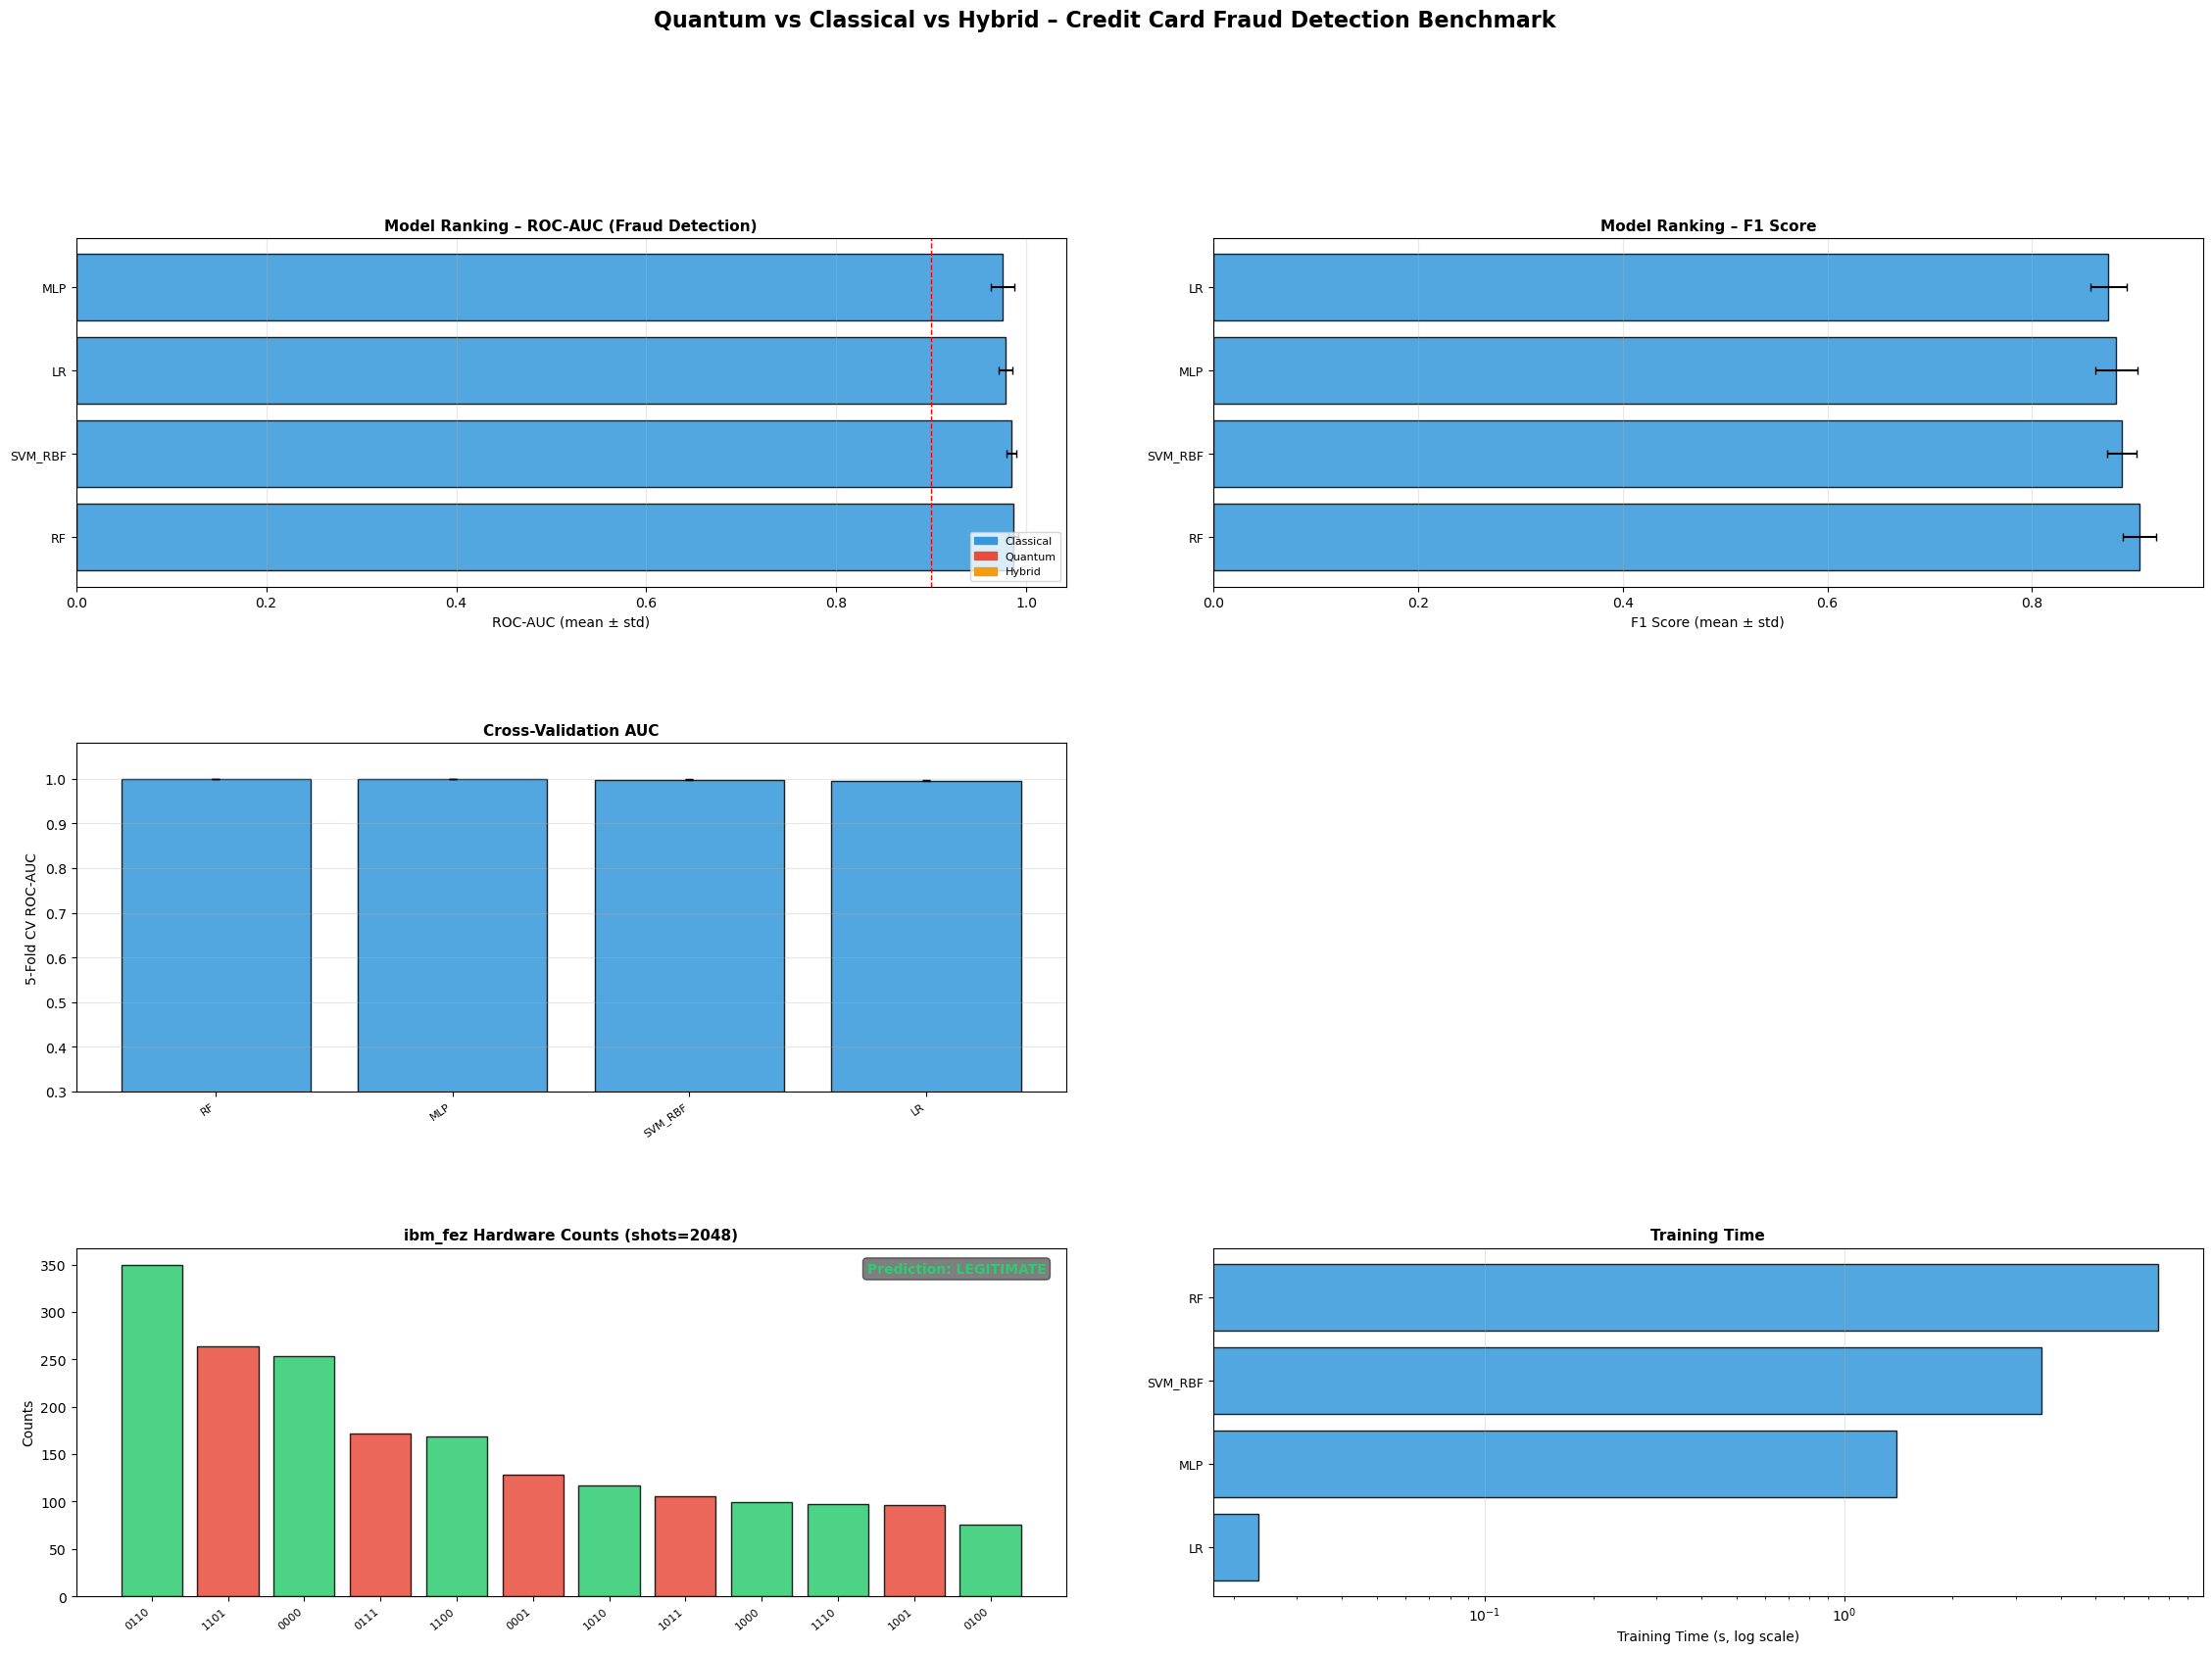

Saved: final_dashboard.png


In [49]:
def plot_final_dashboard(df_main, hw_counts, sim_metrics):
    fig = plt.figure(figsize=(28, 18))
    gs  = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

    df_no = df_main[df_main['noise']=='none']
    order = df_no.groupby('model')['acc'].mean().sort_values(ascending=False).index

    cat_col = {'LR':'#3498db','SVM_RBF':'#3498db','RF':'#3498db','MLP':'#3498db',
               'VQC':'#e74c3c','QCNN':'#e74c3c','QKernel_SVM':'#e74c3c','QAOA_VQC':'#e74c3c',
               'HybridNet':'#f39c12','QuantumBoost':'#f39c12','QResNet':'#f39c12'}

    # 1) AUC ranking (more meaningful for fraud)
    ax1 = fig.add_subplot(gs[0,:2])
    auc_order = df_no.groupby('model')['auc'].mean().sort_values(ascending=False).index
    means = df_no.groupby('model')['auc'].mean().loc[auc_order]
    stds  = df_no.groupby('model')['auc'].std().loc[auc_order]
    cols  = [cat_col.get(m,'gray') for m in auc_order]
    ax1.barh(range(len(auc_order)), means.values, xerr=stds.values,
             color=cols, edgecolor='k', alpha=0.85, capsize=3)
    ax1.set_yticks(range(len(auc_order))); ax1.set_yticklabels(auc_order, fontsize=9)
    ax1.set_xlabel('ROC-AUC (mean ± std)')
    ax1.set_title('Model Ranking – ROC-AUC (Fraud Detection)', fontweight='bold', fontsize=11)
    ax1.axvline(0.9, color='red', ls='--', lw=1)
    ax1.grid(axis='x', alpha=0.3)
    legend_h = [mpatches.Patch(color='#3498db', label='Classical'),
                mpatches.Patch(color='#e74c3c', label='Quantum'),
                mpatches.Patch(color='#f39c12', label='Hybrid')]
    ax1.legend(handles=legend_h, fontsize=8, loc='lower right')

    # 2) F1 ranking
    ax2 = fig.add_subplot(gs[0,2:])
    f1_m = df_no.groupby('model')['f1'].mean().sort_values(ascending=False)
    f1_s = df_no.groupby('model')['f1'].std().loc[f1_m.index]
    f1_c = [cat_col.get(m,'gray') for m in f1_m.index]
    ax2.barh(range(len(f1_m)), f1_m.values, xerr=f1_s.values,
             color=f1_c, edgecolor='k', alpha=0.85, capsize=3)
    ax2.set_yticks(range(len(f1_m))); ax2.set_yticklabels(f1_m.index, fontsize=9)
    ax2.set_xlabel('F1 Score (mean ± std)')
    ax2.set_title('Model Ranking – F1 Score', fontweight='bold', fontsize=11)
    ax2.axvline(0, color='black', lw=1.5, ls='--'); ax2.grid(axis='x', alpha=0.3)

    # 3) CV AUC comparison
    ax3 = fig.add_subplot(gs[1,:2])
    cv_m = df_no.groupby('model')['cv_mean'].mean().sort_values(ascending=False)
    cv_s = df_no.groupby('model')['cv_std'].mean().loc[cv_m.index]
    ax3.bar(range(len(cv_m)), cv_m.values, yerr=cv_s.values,
            color=[cat_col.get(m,'gray') for m in cv_m.index],
            edgecolor='k', alpha=0.85, capsize=3)
    ax3.set_xticks(range(len(cv_m)))
    ax3.set_xticklabels(cv_m.index, rotation=35, ha='right', fontsize=8)
    ax3.set_ylabel('5-Fold CV ROC-AUC')
    ax3.set_title('Cross-Validation AUC', fontweight='bold', fontsize=11)
    ax3.set_ylim(0.3, 1.08); ax3.grid(axis='y', alpha=0.3)

    # # 4) Noise heatmap
    # ax4 = fig.add_subplot(gs[1,2:])
    # qmods = ['VQC','QCNN','QKernel_SVM','QAOA_VQC','HybridNet','QuantumBoost','QResNet']
    # df_n  = df_main[df_main['model'].isin(qmods)].copy()
    # df_n['nl'] = df_n.apply(lambda r: f"{r['noise'][:4]}{r['noise_param']:.2f}", axis=1)
    # piv = df_n.pivot_table(index='model', columns='nl', values='auc', aggfunc='mean')
    # sns.heatmap(piv, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax4,
    #             vmin=0.4, vmax=1.0, cbar=False, linewidths=0.3, annot_kws={'size':7})
    # ax4.set_title('Noise Impact – AUC Heatmap', fontweight='bold', fontsize=11)
    # ax4.tick_params(labelsize=7)

    # 5) Hardware counts
    ax5 = fig.add_subplot(gs[2,:2])
    sorted_hw = dict(sorted(hw_counts.items(), key=lambda x:-x[1])[:12])
    hw_cols   = ['#e74c3c' if k[-1]=='1' else '#2ecc71' for k in sorted_hw]
    ax5.bar(range(len(sorted_hw)), list(sorted_hw.values()), color=hw_cols, edgecolor='k', alpha=0.85)
    ax5.set_xticks(range(len(sorted_hw)))
    ax5.set_xticklabels(list(sorted_hw.keys()), rotation=40, ha='right', fontsize=8)
    ax5.set_title(f"ibm_fez Hardware Counts (shots={sum(hw_counts.values())})",
                  fontweight='bold', fontsize=11)
    ax5.set_ylabel('Counts')
    interp_hw = interpret_hardware_counts(hw_counts)
    ax5.text(0.98, 0.96, f"Prediction: {interp_hw['label']}",
             transform=ax5.transAxes, ha='right', va='top', fontsize=10,
             color='#e74c3c' if interp_hw['prediction']==1 else '#2ecc71',
             fontweight='bold', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

    # 6) Training time
    ax6 = fig.add_subplot(gs[2,2:])
    tt_m = df_no.groupby('model')['train_time'].mean().sort_values()
    tt_cs = [cat_col.get(m,'gray') for m in tt_m.index]
    ax6.barh(range(len(tt_m)), tt_m.values, color=tt_cs, edgecolor='k', alpha=0.85)
    ax6.set_xscale('log')
    ax6.set_yticks(range(len(tt_m))); ax6.set_yticklabels(tt_m.index, fontsize=9)
    ax6.set_xlabel('Training Time (s, log scale)')
    ax6.set_title('Training Time', fontweight='bold', fontsize=11)
    ax6.grid(axis='x', alpha=0.3)

    fig.suptitle('Quantum vs Classical vs Hybrid – Credit Card Fraud Detection Benchmark',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.savefig(RES_DIR + 'final_dashboard.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved: final_dashboard.png")


plot_final_dashboard(df_main, hw_counts, sim_metrics)


## 21) Best Model Summary Plots

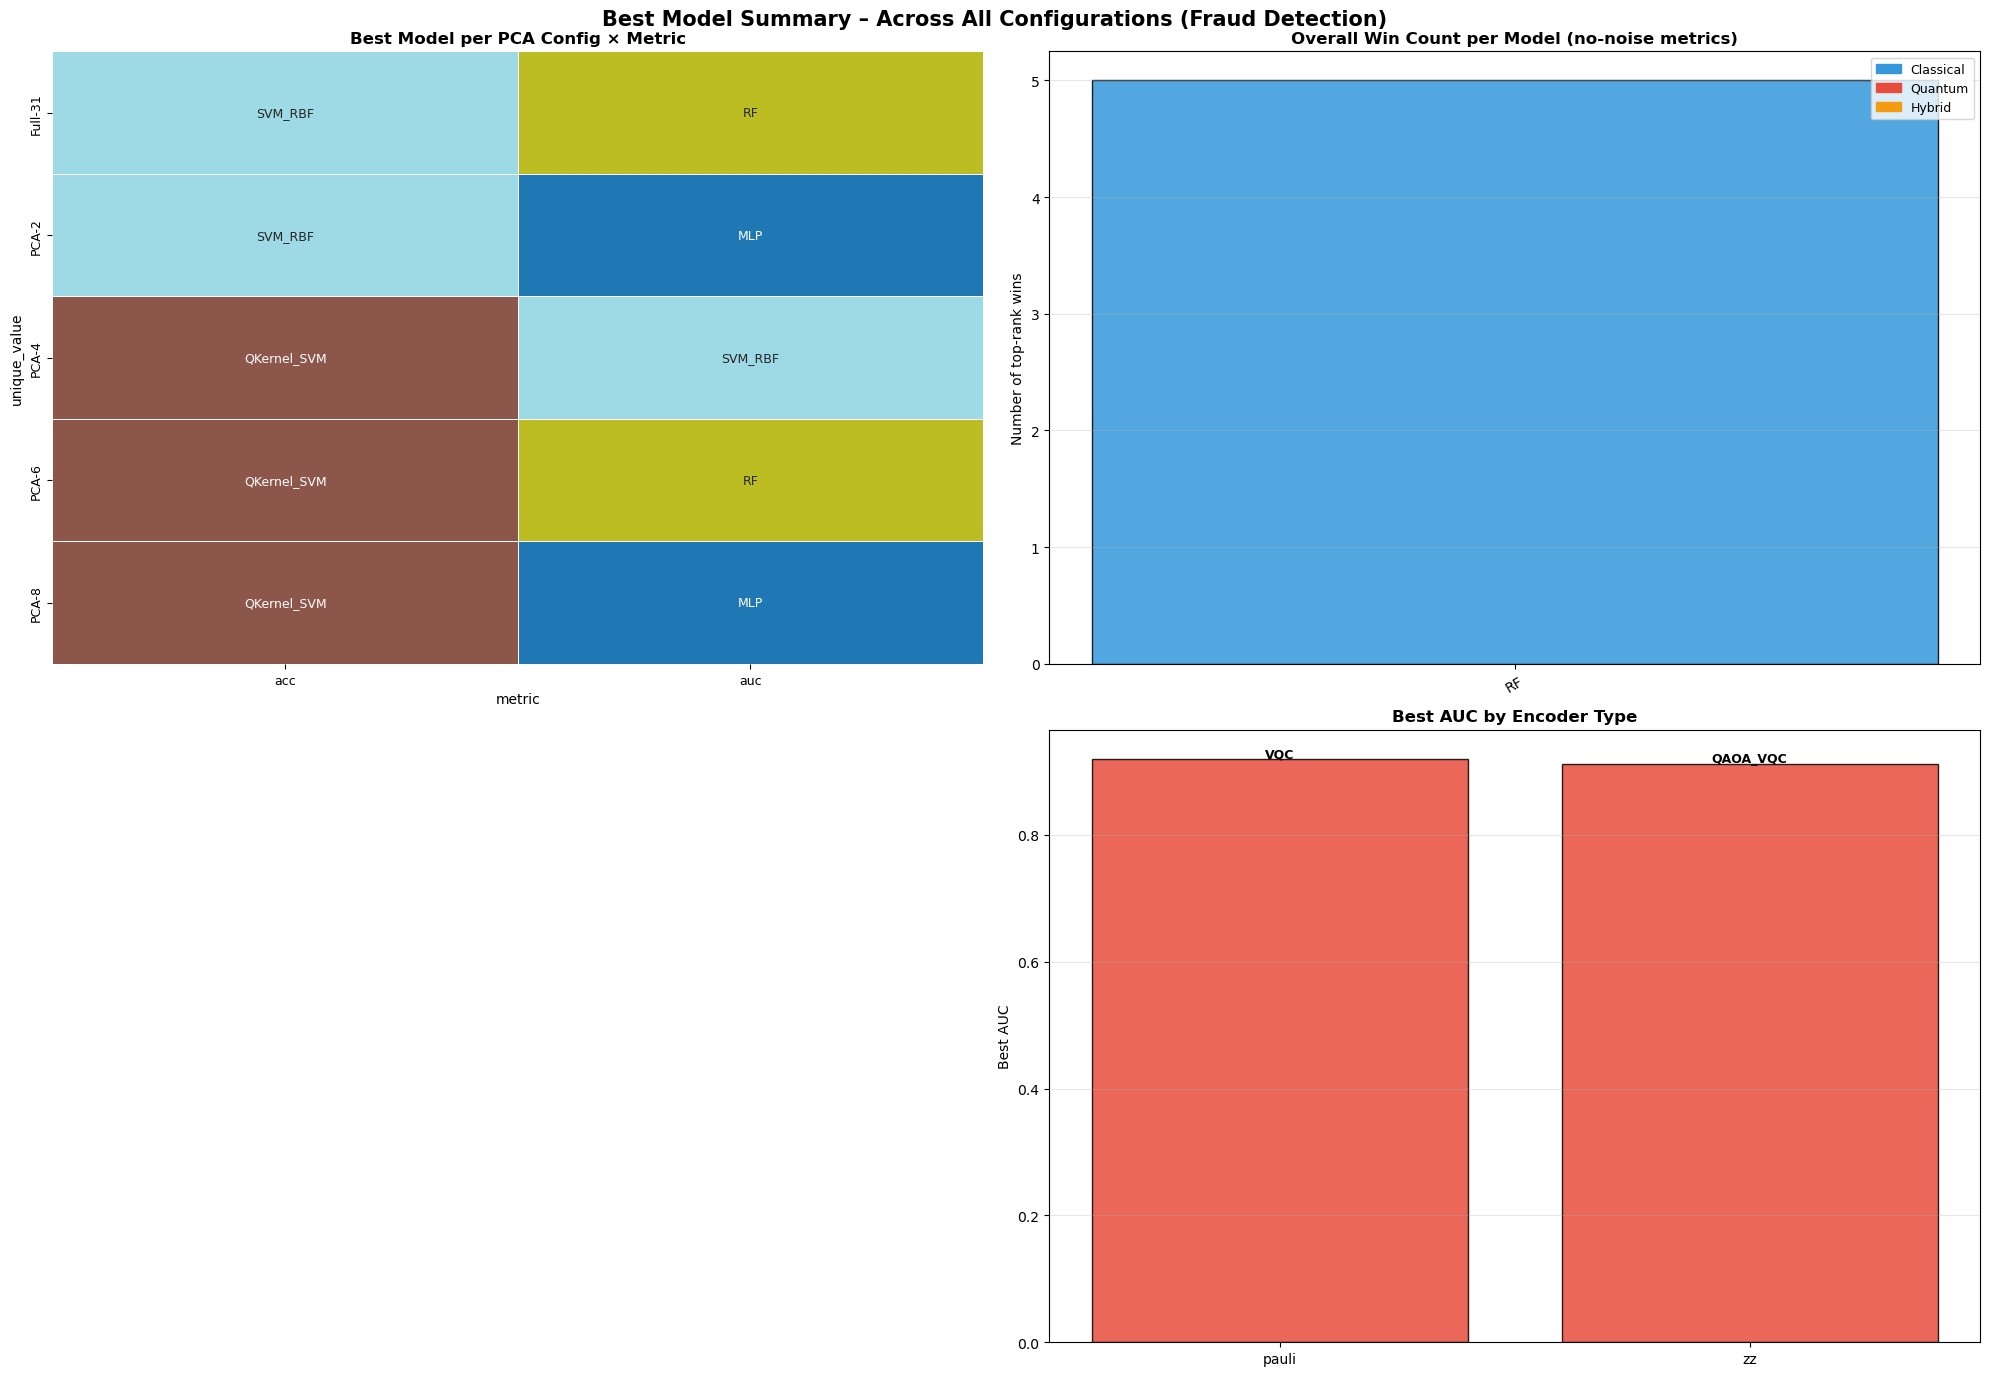

Best model summary plots saved.


In [50]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Best Model Summary – Across All Configurations (Fraud Detection)',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

cat_col_bms = {m:'#3498db' for m in ['LR','SVM_RBF','RF','MLP']}
cat_col_bms.update({m:'#e74c3c' for m in ['VQC','QCNN','QKernel_SVM','QAOA_VQC']})
cat_col_bms.update({m:'#f39c12' for m in ['HybridNet','QuantumBoost','QResNet']})

# 1) Best model per PCA config × metric
ax = axes[0]
pca_best = df_best_models[df_best_models['dimension']=='PCAConfig']
if not pca_best.empty:
    piv_pca = pca_best.pivot_table(index='unique_value', columns='metric',
                                    values='best_model', aggfunc='first')
    all_models_list = sorted(df_best_models['best_model'].unique())
    model_idx = {m:i for i,m in enumerate(all_models_list)}
    num_piv   = piv_pca.applymap(lambda x: model_idx.get(x, -1))
    sns.heatmap(num_piv, annot=piv_pca.values, fmt='', cmap='tab20',
                linewidths=0.5, ax=ax, cbar=False, annot_kws={'size':9})
    ax.set_title('Best Model per PCA Config × Metric', fontweight='bold')
    ax.tick_params(labelsize=9)
else:
    ax.axis('off'); ax.text(0.5, 0.5, 'No PCA data', ha='center', va='center', transform=ax.transAxes)

# 2) Win counts
ax = axes[1]
overall = df_best_models[df_best_models['dimension']=='Overall_NoNoise']
if not overall.empty:
    win_counts = overall['best_model'].value_counts()
    bar_cols = [cat_col_bms.get(m,'gray') for m in win_counts.index]
    ax.bar(win_counts.index, win_counts.values, color=bar_cols, edgecolor='k', alpha=0.85)
    ax.set_title('Overall Win Count per Model (no-noise metrics)', fontweight='bold')
    ax.set_ylabel('Number of top-rank wins')
    ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', alpha=0.3)
    legend_h = [mpatches.Patch(color='#3498db', label='Classical'),
                mpatches.Patch(color='#e74c3c', label='Quantum'),
                mpatches.Patch(color='#f39c12', label='Hybrid')]
    ax.legend(handles=legend_h, fontsize=9)

# 3) Best scores under noise
ax = axes[2]
noise_best = df_best_models[(df_best_models['dimension']=='NoiseConfig') & (df_best_models['metric']=='auc')]
if not noise_best.empty:
    noise_sorted = noise_best.sort_values('best_score', ascending=False)
    bar_cols_n   = [cat_col_bms.get(m,'gray') for m in noise_sorted['best_model']]
    bars = ax.barh(range(len(noise_sorted)), noise_sorted['best_score'],
                   color=bar_cols_n, edgecolor='k', alpha=0.85)
    ax.set_yticks(range(len(noise_sorted)))
    ax.set_yticklabels(noise_sorted['unique_value'], fontsize=8)
    ax.set_xlabel('Best AUC'); ax.set_title('Best AUC per Noise Config', fontweight='bold')
    for bar, (_, row) in zip(bars, noise_sorted.iterrows()):
        ax.text(bar.get_width()-0.01, bar.get_y()+bar.get_height()/2,
                row['best_model'], va='center', ha='right', fontsize=7,
                color='white', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
else:
    ax.axis('off')

# 4) Best scores per encoder
ax = axes[3]
enc_best = df_best_models[(df_best_models['dimension']=='ExtAblation_encoder') & (df_best_models['metric']=='auc')]
if not enc_best.empty:
    x_pos    = range(len(enc_best))
    bar_cols_e = [cat_col_bms.get(m,'gray') for m in enc_best['best_model']]
    ax.bar(x_pos, enc_best['best_score'], color=bar_cols_e, edgecolor='k', alpha=0.85)
    ax.set_xticks(x_pos); ax.set_xticklabels(enc_best['unique_value'], fontsize=10)
    ax.set_ylabel('Best AUC'); ax.set_title('Best AUC by Encoder Type', fontweight='bold')
    for i, (_, row) in enumerate(enc_best.iterrows()):
        ax.text(i, row['best_score']+0.003, row['best_model'], ha='center', fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
else:
    axes[3].axis('off')

plt.tight_layout()
plt.savefig(RES_DIR + 'best_model_summary_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print("Best model summary plots saved.")


## 22) Save All Results

In [51]:
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

# Save main DataFrames
for df_obj, fname in [
    (df_main,          'benchmark_main.csv'),
    (df_input,         'benchmark_input_size.csv'),
    (df_ablation,      'benchmark_ablation.csv'),
    (df_stats,         'statistical_tests.csv'),
    (df_pca_variants,  'benchmark_pca_variants.csv'),
    (df_ext_ablation,  'benchmark_extended_ablation.csv'),
    (df_best_models,   'best_model_per_config.csv'),
    (df_hw_examples,   'hardware_multi_examples.csv'),
    (summary_table,    'paper_results_table.csv'),
]:
    df_save = df_obj.copy()
    if 'loss_curve' in df_save.columns:
        df_save['loss_curve'] = df_save['loss_curve'].astype(str)
    df_save.to_csv(OUT_DIR + fname, index=False)
    print(f"Saved {fname}")

# Save hardware counts + metrics
with open(OUT_DIR + 'ibm_hardware_counts.json', 'w') as f:
    json.dump({'counts': hw_counts,
               'sim_metrics': sim_metrics,
               'hw_metrics': hw_metrics}, f, indent=2)
print("Saved ibm_hardware_counts.json")

print(f"\n✅ All results saved to: {OUT_DIR}")
print(f"✅ All visualizations saved to: {RES_DIR}")

# ── Final summary ─────────────────────────────────────────
print("\n" + "="*65)
print("CREDIT CARD FRAUD DETECTION – FINAL BENCHMARK SUMMARY")
print("="*65)
df_no = df_main[df_main['noise']=='none']
summary_final = df_no.groupby('model').agg(
    Accuracy=('acc','mean'), AUC=('auc','mean'),
    F1=('f1','mean'), MCC=('mcc','mean'),
    Sensitivity=('sensitivity','mean'), CV_AUC=('cv_mean','mean')
).round(4).sort_values('AUC', ascending=False)
print(summary_final.to_string())
print("="*65)
print("\nDataset: Credit Card Fraud (284,807 samples, 31 features)")
print("Class imbalance:", f"{(y_s==0).sum():,} Legit : {(y_s==1).sum()} Fraud")


Saved benchmark_main.csv
Saved benchmark_input_size.csv
Saved benchmark_ablation.csv
Saved statistical_tests.csv
Saved benchmark_pca_variants.csv
Saved benchmark_extended_ablation.csv
Saved best_model_per_config.csv
Saved hardware_multi_examples.csv
Saved paper_results_table.csv
Saved ibm_hardware_counts.json

✅ All results saved to: outputs/fraud/
✅ All visualizations saved to: results/fraud/

CREDIT CARD FRAUD DETECTION – FINAL BENCHMARK SUMMARY
         Accuracy     AUC      F1     MCC  Sensitivity  CV_AUC
model                                                         
RF         0.9894  0.9865  0.9049  0.9001       0.8735  0.9994
SVM_RBF    0.9874  0.9843  0.8879  0.8820       0.8633  0.9984
LR         0.9852  0.9783  0.8743  0.8668       0.8939  0.9963
MLP        0.9865  0.9747  0.8822  0.8753       0.8816  0.9992

Dataset: Credit Card Fraud (284,807 samples, 31 features)
Class imbalance: 284,315 Legit : 492 Fraud
